# Analyze and plot results for networks performance

This script takes in the results from data-overview.ipynb and fit-observables.ipynb, and performs analyses on the data.

In [ ]:
# !conda install conda-forge:mscorefonts --yes

In [2]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.patches as mpatches
import seaborn as sns

import matplotlib as mpl
import matplotlib.ticker as ticker
import matplotlib.cm as cm
import matplotlib.colors as mcolors

import numpy as np
import pandas as pd
import os
import plotly.graph_objects as go
import plotly.express as px
import pickle

# import clustering packages
from sklearn.linear_model import LinearRegression
from sklearn.cluster import SpectralClustering, KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import seaborn as sns

from kneed import KneeLocator

plt.style.use('custom.mplstyle')
%config InlineBackend.figure_format = 'retina'

from tqdm import tqdm
from joblib import Parallel, delayed

from stoch_sim_model import *

## 0. Load data and build datasets

In [3]:
# Load data from 2nd infections
reg_model = ''
runs = '-1-'
model = "limit-E" #"compete_d_E" #"vary_b_I" #"simple_d_E"
comment = "acute_all"+'-'+model

d_mean = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/processed_data'+runs+'runs'+'-'+comment+'.pkl'

# Import datasets
with open('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/list_processed_data'+runs+'runs'+'-'+comment+'.pkl', 'rb') as f:
    infection_scenarios = pickle.load(f)

full_sim_data = pd.read_pickle(d_mean)
# with pd.option_context('display.max_columns', None):
#     display(use_sim_data)

## 1. Performance-based evaluation of immune networks

In [4]:
# Create additional variables
module_reg = {'$N \longrightarrow N^*$': [r for r in Na_reg if np.std(infection_scenarios[0][r].values) > 0], 
              '$N^* \longrightarrow E$': [r for r in NE_reg if np.std(infection_scenarios[0][r].values) > 0],  
              '$E \longrightarrow \emptyset$': [r for r in EE_reg if np.std(infection_scenarios[0][r].values) > 0]}
module_reg_labels = {'$N \longrightarrow N^*$': [r for i, r in enumerate(param_names[-16:-12]) if  Na_reg[i] in module_reg['$N \longrightarrow N^*$']], 
                     '$N^* \longrightarrow E$': [r for i, r in enumerate(param_names[-12:-8]) if  NE_reg[i] in module_reg['$N^* \longrightarrow E$']],
                     '$E \longrightarrow \emptyset$': [r for i, r in enumerate(param_names[-4:]) if  EE_reg[i] in module_reg['$E \longrightarrow \emptyset$']]}

signal_classes = [r for i, r in enumerate(["Ag. sens.", "Inflam. sens.", "Anti-inflam. sens.", "Baseline"]) if np.std(infection_scenarios[0][[Na_reg[i]] + [NE_reg[i]] + [EM_reg[i]] + [EE_reg[i]]].values) > 0]
stim_vars = ['stim_pI', 'stim_pHI', 'stim_pHE']

# if "full" in comment or "sparse" in comment:
reg = [r for r in Na_reg + NE_reg + EE_reg if np.std(infection_scenarios[0][r].values) > 0]
reg_label = param_names[-16:-12] + param_names[-12:-8] + param_names[-4:]
module_labels = ['$N \longrightarrow N^*$', '$N^* \longrightarrow E$', '$E \longrightarrow \emptyset$']
full_vars = ['b_I', 'K_I', 'd_I', 'K_H', 'N_0', 'I_0','S_0', 'd_IE', 'd_H', 'max_Na', 'max_expand']
opt_vars = ['psi_I', 'psi_HI', 'psi_HE', 'g0_Na', 'g0_NE', 'g0_Edie'] #, reg_bl[2]]
opt_vars_labels = [r"$\psi_\text{Ag}$",
                   r"$\psi_\text{inf}$",
                   r"$\psi_\text{res}$",
                   r"$g_{0,N \to N^*}=g_{0,E \to 2E}$",
                   r"$g_{0,N^* \to E}$",
                   r"$g_{0,E \to \emptyset}$"]

num_categories = len(perf_labels)
reg_markers = ['o', 's', 'v', '^', 'X','*', 'D','>', '<']
num_modules = len(module_labels)
num_psis = len(Na_reg)

intercept_vars = ['intercept_Na', 'intercept_NE', 'intercept_EE']

plots = [vir_vars[1], 'R_0']
plot_labels = [r"immunogenicity, $\kappa$", "reproduction\n number, $R_0$"]
short_plot_labels = [r"$\kappa$", r"$R_0$"]

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

# helper variables
n_virs = len(infection_scenarios)
del infection_scenarios

In [5]:
# Set colours
ito_colors = [
    '#E69F00',  # Orange
    '#56B4E9',  # Sky Blue
    '#009E73',  # Bluish Green
    '#F0E442',  # Yellow
    '#0072B2',  # Blue
    '#D55E00',  # Vermillion
    '#CC79A7',  # Reddish Purple
    '#999999'   # Grey
]

tol_bright_hex = ['#EE6677', '#228833', '#4477AA', '#CCBB44', '#66CCEE', '#AA3377', '#BBBBBB']
tol_muted_hex = ['#CC6677', # Light pink purple
                 '#332288', # Dark blue purple
                 '#DDCC77', # Orange-yellow
                 '#117733', # Dark green
                 '#88CCEE', # Light blue
                 '#882255', # Maroon (dark-reddish purple)
                 '#44AA99', # Light green
                 '#999933', # Olive
                 '#AA4499'] # Pink purple

cmap_colors = [tol_bright_hex[1], # Green
               tol_bright_hex[4], # Light blue
               tol_bright_hex[0], # Pink
               ito_colors[3], # Yellow
               ito_colors[4], # Dark blue
               ito_colors[5], # Vermillion
              ]

perf_var_colors = ['#DC267F', '#FFB000', tol_muted_hex[1], '#D55E00', '#F5C710', 'grey', cmap_colors[-3]]

cluster_colors = [ito_colors[2], '#56B4E9', '#F5C710', ito_colors[5], 'grey', cmap_colors[-3]] # 

### (a) Performance of the immune response in different contexts

In [6]:
keep_vars = opt_vars + perf_vars + vir_vars + reg_bl + ['frac_cM', 'max_pE','T_pE_start', 'T_pE_max', 'T_pE_end','stim_pI', 'stim_pHI', 'stim_pHE','E_end', 'R_0', 'feedback']
use_sim_data = full_sim_data.copy()
use_sim_data.loc[:, 'max_expand'] = max_expand
use_sim_data.loc[:, 'R_0'] = S_max*use_sim_data['b_I']/use_sim_data['d_I']
use_sim_data.loc[:, opt_vars[0:3]] = use_sim_data[['psi_NE_I', 'psi_NE_HI', 'psi_NE_HE']].values
use_sim_data.loc[:, opt_vars[3:]] = 1/(1 + np.exp(-use_sim_data[reg_bl].values))
use_sim_data.loc[:, 'feedback'] = np.round(np.amax(np.abs(use_sim_data[opt_vars[0:3]]), axis = 1), 2)
use_sim_data.loc[:, 'idx'] = use_sim_data.groupby(plots).ngroup()

del full_sim_data

In [7]:
# Visualize optimal regulation
size = 2500/np.cbrt(n_virs)

import heapq
infections_params = use_sim_data.groupby(vir_vars, as_index = False).mean()

highK_I_highR_0 = (infections_params[plots[0]].values == heapq.nlargest(4,np.unique(infections_params[plots[0]].values))[2])*(infections_params[plots[1]].values == heapq.nlargest(3,np.unique(infections_params[plots[1]].values))[0])
midK_I_highR_0 = (infections_params[plots[0]].values == heapq.nsmallest(9,np.unique(infections_params[plots[0]].values))[6])*(infections_params[plots[1]].values == heapq.nlargest(3,np.unique(infections_params[plots[1]].values))[0])
lowK_I_highR_0 = (infections_params[plots[0]].values == heapq.nsmallest(5,np.unique(infections_params[plots[0]].values))[2])*(infections_params[plots[1]].values == heapq.nlargest(3,np.unique(infections_params[plots[1]].values))[0])

highK_I_midR_0 = (infections_params[plots[0]].values == heapq.nlargest(4,np.unique(infections_params[plots[0]].values))[2])*(infections_params[plots[1]].values == heapq.nlargest(6,np.unique(infections_params[plots[1]].values))[5])
midK_I_midR_0 = (infections_params[plots[0]].values == heapq.nsmallest(9,np.unique(infections_params[plots[0]].values))[6])*(infections_params[plots[1]].values == heapq.nlargest(6,np.unique(infections_params[plots[1]].values))[5])
lowK_I_midR_0 = (infections_params[plots[0]].values == heapq.nsmallest(5,np.unique(infections_params[plots[0]].values))[2])*(infections_params[plots[1]].values == heapq.nlargest(6,np.unique(infections_params[plots[1]].values))[5])

highK_I_lowR_0 = (infections_params[plots[0]].values == heapq.nlargest(5,np.unique(infections_params[plots[0]].values))[2])*(infections_params[plots[1]].values == heapq.nsmallest(3,np.unique(infections_params[plots[1]].values))[0])
midK_I_lowR_0 = (infections_params[plots[0]].values == heapq.nsmallest(9,np.unique(infections_params[plots[0]].values))[6])*(infections_params[plots[1]].values == heapq.nsmallest(3,np.unique(infections_params[plots[1]].values))[0])
lowK_I_lowR_0 = (infections_params[plots[0]].values == heapq.nsmallest(5,np.unique(infections_params[plots[0]].values))[2])*(infections_params[plots[1]].values == heapq.nsmallest(3,np.unique(infections_params[plots[1]].values))[0])

quadrants = pd.concat([infections_params.loc[highK_I_highR_0],
                       infections_params.loc[midK_I_highR_0],
                       infections_params.loc[lowK_I_highR_0],
                       infections_params.loc[highK_I_midR_0],
                       infections_params.loc[midK_I_midR_0],
                       infections_params.loc[lowK_I_midR_0],
                       infections_params.loc[highK_I_lowR_0],
                       infections_params.loc[midK_I_lowR_0],
                       infections_params.loc[lowK_I_lowR_0]
                      ])

quadrants_small = pd.concat([infections_params.loc[highK_I_highR_0],
                       infections_params.loc[lowK_I_highR_0],
                       infections_params.loc[highK_I_midR_0],
                       infections_params.loc[lowK_I_midR_0]
                      ])


quadrants_labels = x = ['Low ' + short_plot_labels[0]+', fast '+short_plot_labels[1],
                        'Medium ' + short_plot_labels[0]+', fast '+short_plot_labels[1],
                        'High ' + short_plot_labels[0]+', fast '+short_plot_labels[1],
                        'Low ' + short_plot_labels[0]+', medium '+short_plot_labels[1],
                        'Medium ' + short_plot_labels[0]+', medium '+short_plot_labels[1],
                        'High ' + short_plot_labels[0]+', medium '+short_plot_labels[1],
                        'Low ' + short_plot_labels[0]+', slow '+short_plot_labels[1],
                        'Medium ' + short_plot_labels[0]+', slow '+short_plot_labels[1],
                        'High ' + short_plot_labels[0]+', slow '+short_plot_labels[1],]

In [8]:
# Print quadrant values
S_max/quadrants_small[plots[0]]

62      5.623413
26    177.827941
57      5.623413
21    177.827941
Name: K_I, dtype: float64

In [9]:
# Define utility and constraint functions

num_cpu = 150

linestyles = ['-','--','-','-.',':','--', '-.']

def sample_3d_simplex(weights = [1,1,1], pnts = 100):
    """Samples points uniformly from the 3D simplex."""
    x = np.random.dirichlet(weights, pnts)
    
    return x


def weighted_std(values, weights):
    """
    Calculates the weighted std of a set of values.
    """
    if len(values) != len(weights):
        raise ValueError("Values and weights must have the same length.")

    weighted_mean = np.average(values, weights=weights)
    numerator = np.sum(weights * (values - weighted_mean)**2)
    denominator = np.sum(weights)

    if denominator <= 0:
        return np.nan # Handle cases with insufficient weights for sample variance

    return np.sqrt(numerator / denominator)

def grid_search(input, type = "global", vars = perf_vars[0:3], top = 0.01):

    df_list = []
    input.loc[:,opt_vars[0]] = input['psi_NE_I']
    input.loc[:,opt_vars[1]] = input['psi_NE_HI']
    input.loc[:,opt_vars[2]] = input['psi_NE_HE']
    data = input #.groupby(opt_vars, as_index = False).mean()
    
    if type == "global":
        for i, perf in enumerate(vars):
            data_sorted = data.sort_values(by=perf, ascending= True)
            #sample_std = weighted_std(data_sorted[perf].values, -np.log(data_sorted[perf_vars[0]].values))
            #max_row = data_sorted.loc[data_sorted[perf] <= (1 + top)*np.amin(data_sorted[perf])].copy() #.mean() #.head(top).mean()
            max_row = data_sorted.loc[data_sorted[perf] <= (top + np.amin(data_sorted[perf]))].copy()
            #max_row = data_sorted.copy().head(top)
            max_row.loc[:,'perf_index'] = i
            df_list.append(max_row.values)
        
        out = pd.DataFrame(np.vstack(df_list), columns = data.columns.tolist() + ['perf_index'])

    elif type == "ablate":
        for i, perf in enumerate(vars):
            for j, p in enumerate(opt_vars):
                for (_, g) in data.groupby(p, as_index = False):
                    g_sorted = g.sort_values(by=perf, ascending= True)
                    #sample_std = weighted_std(g_sorted[perf].values, -np.log(g_sorted[perf_vars[0]].values))
                    # max_row = g_sorted.loc[g_sorted[perf] <= (1 + top)*np.amin(g_sorted[perf])].copy() #.mean() #g_sorted.head(top).mean()
                    max_row = g_sorted.loc[g_sorted[perf] <= (top + np.amin(g_sorted[perf]))].copy()
                    #max_row = g_sorted.copy().head(top)
                    max_row.loc[:,'perf_index'] = i
                    max_row.loc[:,'ablate_index'] = j
                    df_list.append(max_row.values)
        
        out = pd.DataFrame(np.vstack(df_list), columns = data.columns.tolist() + ['perf_index', 'ablate_index'])
        
    return out

#### Explore design space for representative infections

/tmp/ipykernel_91663/3393618265.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:,'compromise'] = (1-l)*data['peff_infection'].values + l*data['peff_toxicity'].values
/tmp/ipykernel_91663/3393618265.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:,'compromise'] = (1-l)*data['peff_infection'].values + l*data['peff_toxicity'].values
/tmp/ipykernel_91663/3393618265.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_

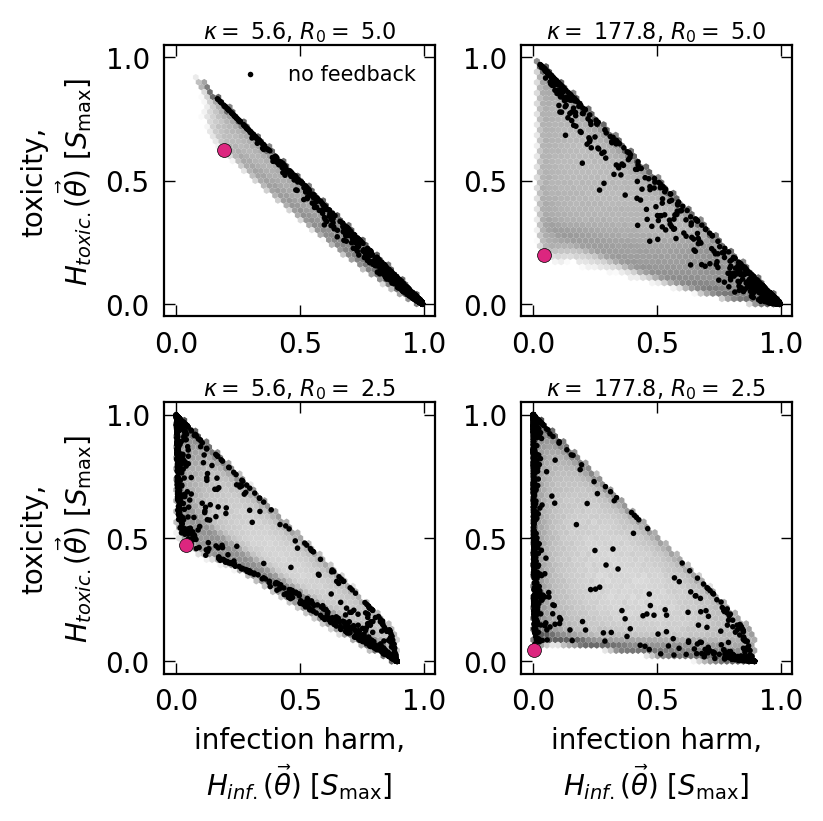

In [10]:
# Visualize pareto regulation
perf_x, perf_y = 1, 2
kwargs = {'linewidth': 4.0, 'markeredgewidth': 0.25, 'markeredgecolor': 'k', 'markersize': 6, 'alpha': 0.75}

fig, axs = plt.subplots(2, 2, 
                          figsize=(4, 4), sharex=True, sharey=True, layout='constrained')

lambdas = np.linspace(0,1,21)

for k, a in enumerate(quadrants_small[plots].values):
    data = use_sim_data.loc[(use_sim_data[plots[0]] == a[0])*(use_sim_data[plots[1]] == a[1])]
    
    z_label = r"Scaled Harm"

    y, x = k % 2, k // 2
    
    axs[x,y].hexbin(data.peff_infection, data.peff_toxicity,
                       gridsize = 40, C = None,
                         cmap='Grays', edgecolors = 'None',
                   norm = mpl.colors.LogNorm())
    # axs[x,y].scatter(data.peff_infection, data.peff_toxicity,
    #               s = 2, color = "gray",
    #               label = 'with feedback',
    #               edgecolors = 'None')

    no_fbk = np.sum(np.abs(data[opt_vars[0:3]]), axis = 1) == 0
    axs[x,y].scatter(data.loc[no_fbk].peff_infection, data.loc[no_fbk].peff_toxicity,
                      s = 4, color = "black",
                      label = 'no feedback',
                      edgecolors = 'None')

    pareto_designs = []
    
    for l in lambdas:
        data.loc[:,'compromise'] = (1-l)*data['peff_infection'].values + l*data['peff_toxicity'].values
        data_sorted = data.sort_values(by='compromise', ascending= True).copy()
        max_row = data_sorted.head(10).mean()
        pareto_designs.append(max_row.values) # plot_data.loc[pareto_index]
    
    pareto_design_df = pd.DataFrame(np.vstack(pareto_designs), columns = data_sorted.columns.tolist())

    # axs[x,y].plot(pareto_design_df['peff_infection'].values, 
    #               pareto_design_df['peff_toxicity'].values,
    #               color='red', linewidth = 2.0, alpha = 0.75,
    #               label = 'Pareto front')

    axs[x,y].scatter(pareto_design_df['peff_infection'].values[int(len(lambdas)/2)], 
                     pareto_design_df['peff_toxicity'].values[int(len(lambdas)/2)],
                     s = 25, marker = 'o',
                     #label = r'$\vec\theta^* = {\rm argmax}~H(\vec\theta)$',
                     color=perf_var_colors[0], zorder = 2, edgecolor = "black", linewidth = 0.25)

    
    axs[x,y].set_title(r"$\kappa=$ "+str(np.round(S_max/a[0],1))+r", $R_0=$ "+str(np.round(a[1],1)), fontsize = 8.0, pad = 2.5)
        
    axs[x,y].minorticks_off()
    axs[x,y].set_box_aspect(1)
    axs[x,y].tick_params(axis='both', which='major', labelsize=10)
    axs[x,y].locator_params(axis='y', nbins=4)
    axs[x,y].locator_params(axis='x', nbins=4)
    
axs[0,0].legend(fontsize=7.5)

for j, ax in enumerate(axs.flat):
    if j // 2 == 1:
        ax.set_xlabel("infection harm,\n"+r'$H_{inf.}(\vec{\theta})$ [$S_\text{max}$]', fontsize = 10)
    if j % 2 == 0:
        ax.set_ylabel("toxicity,\n"+r'$H_{toxic.}(\vec{\theta})$ [$S_\text{max}$]', fontsize = 10)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

plt.savefig('_figs/fig3_'+comment+'-singles_clear_tox'+'.pdf', format="pdf", transparent=True, dpi=300) #, bbox_inches="tight")

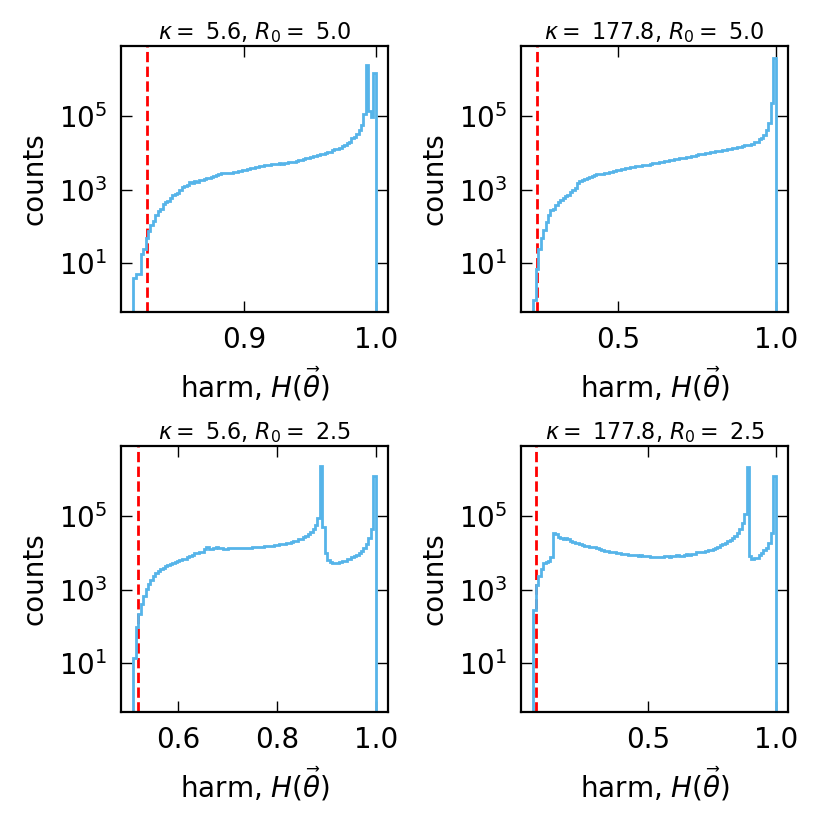

In [11]:
fig, axs = plt.subplots(2, 2, figsize=(4, 4), sharex=False, sharey=True, layout='constrained')
cluster_tol = 0.01

for k, a in enumerate(quadrants_small[plots].values):
    data = use_sim_data.loc[(use_sim_data[plots[0]] == a[0])*(use_sim_data[plots[1]] == a[1])]
    
    y, x = k % 2, k // 2
    sample_std = weighted_std(data[perf_vars[0]], -np.log(data[perf_vars[0]]))

    axs[x,y].hist(data[perf_vars[0]], bins = 100, histtype = 'step', log = True);

    axs[x,y].axvline(x = np.amin(data[perf_vars[0]]) + cluster_tol,
           color = 'red', linewidth = 1.0, alpha = 1.0, linestyle = '--', zorder = 0,
           label = r"near-optimal cutoff")
    
    axs[x,y].set_title(r"$\kappa=$ "+str(np.round(S_max/a[0],1))+r", $R_0=$ "+str(np.round(a[1],1)), #+", STD = "+str(np.round(sample_std,2)), 
                       fontsize = 8.0, pad = 2.5)
        
    axs[x,y].minorticks_off()
    axs[x,y].set_box_aspect(1)
    axs[x,y].tick_params(axis='both', which='major', labelsize=10)
    #axs[x,y].legend()

for j, ax in enumerate(axs.flat):
    ax.set_xlabel(r'harm, $H(\vec{\theta})$', fontsize = 10)
    ax.set_ylabel("counts", fontsize = 10)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)
    #ax.semilogx()

plt.savefig('_figs/figSI_'+comment+'-singles-harm_dist'+'.pdf', format="pdf", transparent=True, dpi=300) #, bbox_inches="tight")

#### Minimize Harm for each infection

In [12]:
# Find optimal designs for each infection by grid searching
grid_opt = pd.concat(Parallel(n_jobs = num_cpu,
                          batch_size = 1)(delayed(grid_search)(g, top = 0.01)
                                                   for (_, g) in use_sim_data.groupby(vir_vars)
                                                  ))

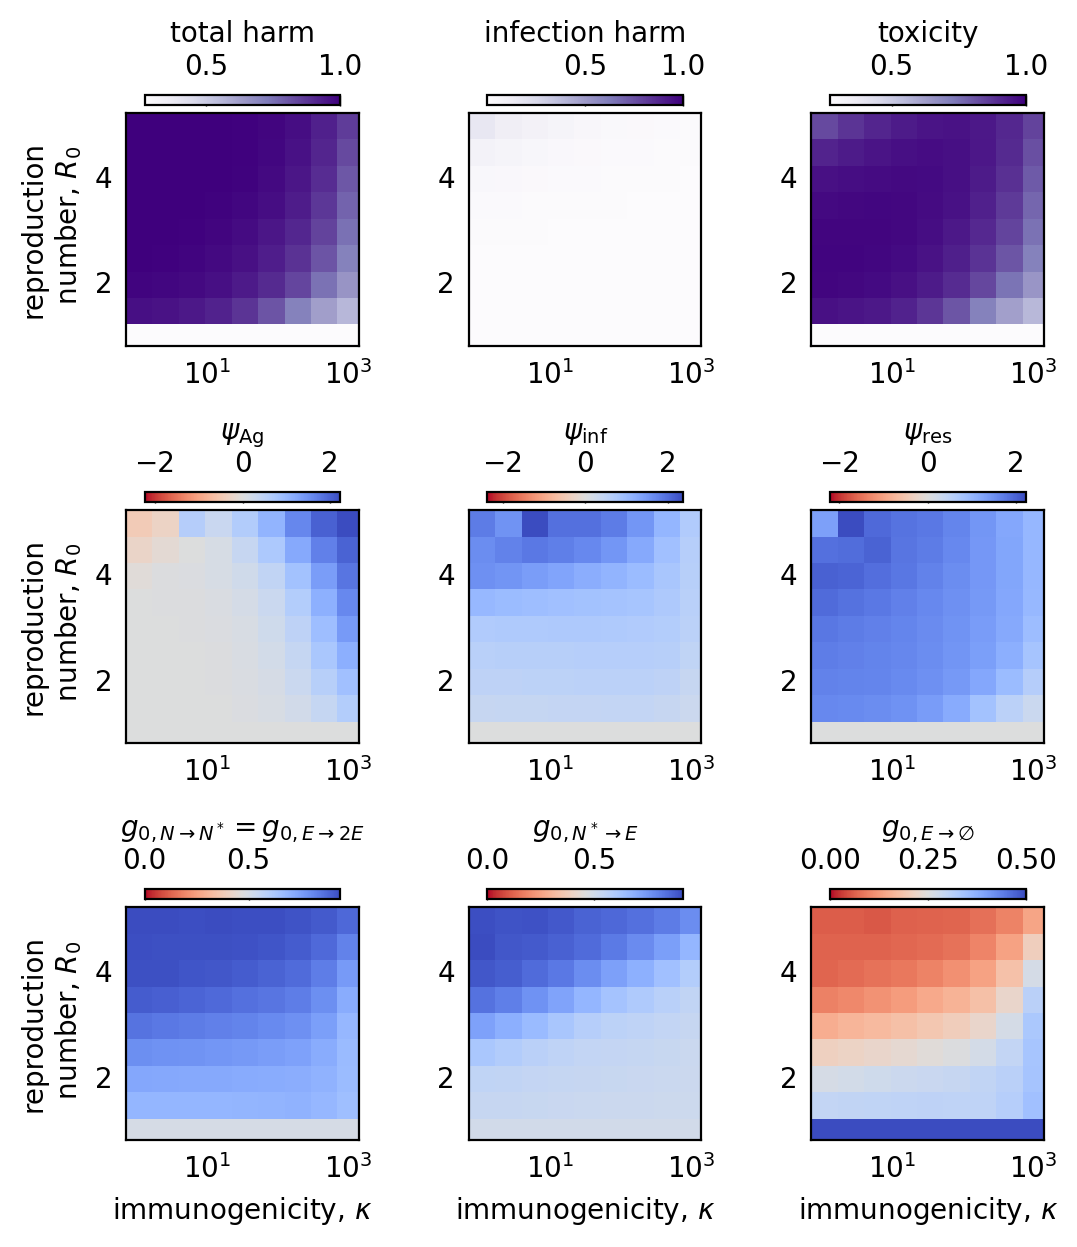

In [13]:
# Visualize optimal Harm and regulation
fig, axs = plt.subplots(3, 3, 
                          figsize=(6, 7), sharex=True, sharey=True)

size = 550/np.cbrt(n_virs)

variables = perf_vars[0:3] + opt_vars[0:3] + opt_vars[3:] # 'harm_pI_noprotection'
data = grid_opt.loc[(grid_opt.perf_index == 1)].groupby(plots, as_index = False).mean()

for k, (var, ax) in enumerate(zip(variables, axs.flat)):

    z = data[var].values
    range = np.amax(np.abs(z))

    im = ax.scatter(S_max/data[plots[0]], data[plots[1]],
                 marker ='s', s = size, c = z, 
                 cmap='Purples' if k <=2 else 'coolwarm_r', edgecolors = 'None',# alpha = 0.8, 
                 norm = mpl.colors.Normalize(vmax = 1.0) if k <=2 else mpl.colors.Normalize(vmin = -range if k < 6 else 0.0, vmax = range))

    ax.set_box_aspect(1)
    ax.semilogx()
    ax.minorticks_off()
    ax.locator_params(axis='y', nbins=4)
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

    if k // 3 == 2:
        ax.set_xlabel(plot_labels[0], fontsize = 10)
    if k % 3 == 0:
        ax.set_ylabel(plot_labels[1], fontsize = 10)
    
    z_label = (perf_labels[0:3] + opt_vars_labels[0:3] + opt_vars_labels[3:])[k]
    cb = fig.colorbar(im, ax=ax, location='top', shrink = 0.8, pad = 0.03)
    cb.set_label(z_label, fontsize = 10)
    cb.ax.tick_params(labelsize=10)

fig.subplots_adjust(wspace=0.4, hspace=0.4)

#plt.savefig('_figs/figSI_'+comment+'-reg-singles_clearance_hmap'+'.pdf', format="pdf", transparent=True, dpi=300, bbox_inches="tight")

#### Cluster designs to find infection archetypes

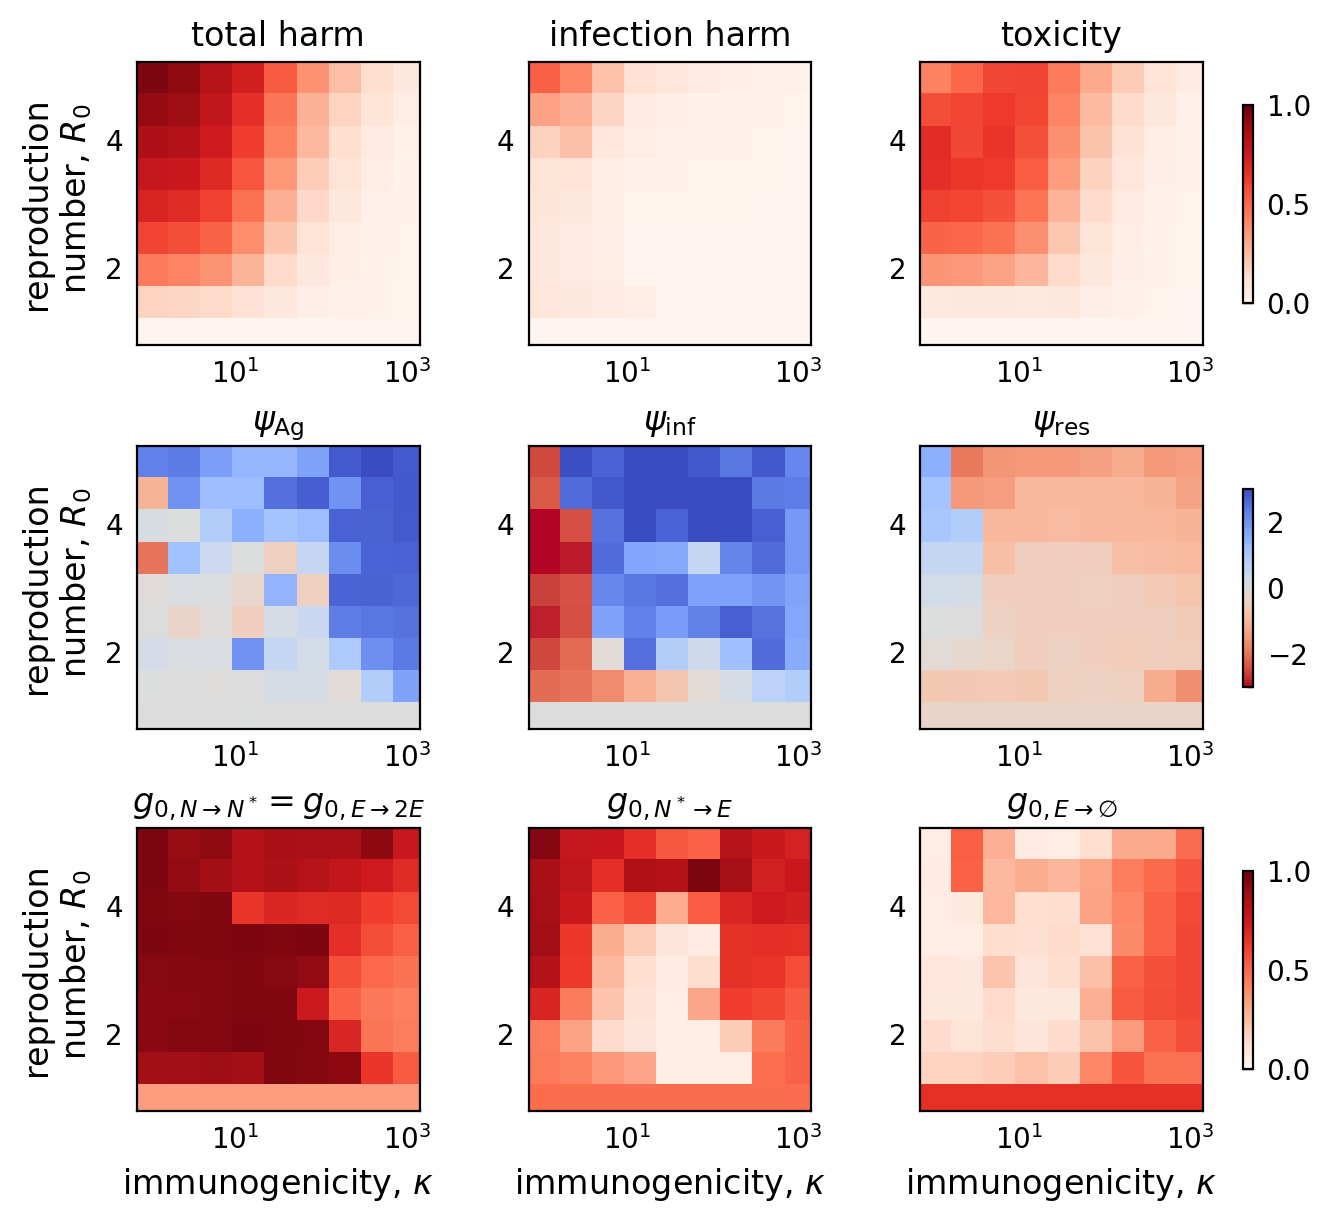

In [14]:
# Visualize optimal Harm and regulation
fig, axs = plt.subplots(3, 3, 
                          figsize=(6.5, 6), sharex=True, sharey=True, constrained_layout=True)

size = 750/np.cbrt(n_virs)

variables = perf_vars[0:3] + opt_vars[0:3] + opt_vars[3:] # 'harm_pI_noprotection'
data = grid_opt.loc[(grid_opt.perf_index == 0)].groupby(plots, as_index = False).mean()

for k, (var, ax) in enumerate(zip(variables, axs.flat)):

    z = data[var].values
    # range = np.amax(np.abs(z))

    im = ax.scatter(S_max/data[plots[0]], data[plots[1]],
                 marker ='s', s = size, c = z, 
                 cmap=['Reds','coolwarm_r', 'Reds'][k // 3], edgecolors = 'None',# alpha = 0.8, 
                 norm = mpl.colors.Normalize(vmin = 0.0, vmax = 1.0) if k <=2 else mpl.colors.Normalize(vmin = -psi_max if k < 6 else 0.0, vmax = psi_max if k < 6 else 1.0))

    z_label = ([perf_labels[0], perf_labels[1], perf_labels[2]] + opt_vars_labels[0:3] + opt_vars_labels[3:])[k]
    ax.set_title(z_label, fontsize = 12.0)
    ax.set_box_aspect(1)
    ax.semilogx()
    ax.minorticks_off()
    ax.locator_params(axis='y', nbins=4)
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

    if k // 3 == 2:
        ax.set_xlabel(plot_labels[0], fontsize = 12)
    if k % 3 == 0:
        ax.set_ylabel(plot_labels[1], fontsize = 12)
    
    if k % 3 == 2:
        cb = fig.colorbar(im, ax=axs[k // 3,:], location='right', shrink = 0.7, pad = 0.025)
        # cb.set_label(z_label, fontsize = 10)
        cb.ax.tick_params(labelsize=10)

#fig.subplots_adjust(wspace=0.25, hspace=0.3)

plt.savefig('_figs/figSI_'+comment+'-singles-opt_design-hmap'+'.pdf', format="pdf", transparent=True, dpi=300) #, bbox_inches="tight")

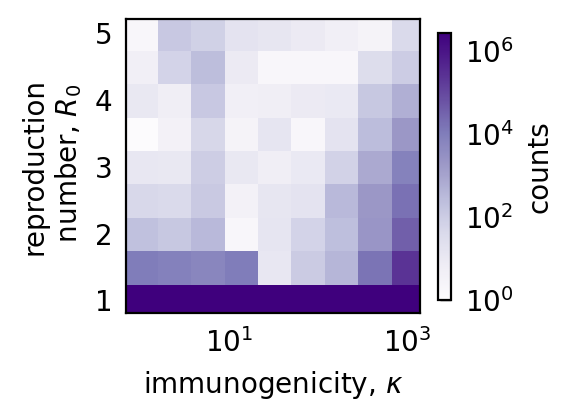

In [15]:
fig, axs = plt.subplots(1,1, figsize=(2.75, 2.75), sharex='row', sharey=False,layout='constrained')

counts = grid_opt.loc[(grid_opt.perf_index == 0)].groupby(plots, as_index = False).size()

im = axs.scatter(S_max/counts[plots[0]], counts[plots[1]],
                 marker ='s', s = size, 
                c = counts['size'], 
            norm = mpl.colors.LogNorm(),
            cmap = 'Purples', edgecolors = 'None')

cb = fig.colorbar(im, ax=axs, location='right', shrink = 0.5, pad = 0.025)
cb.set_label('counts', fontsize = 10)
cb.ax.tick_params(labelsize=10)

axs.semilogx()
axs.minorticks_off()
axs.set_xlabel(plot_labels[0], fontsize = 10)
axs.set_ylabel(plot_labels[1], fontsize = 10)
axs.set_box_aspect(1)
axs.tick_params(axis='both', which='major', labelsize=10)
plt.savefig('_figs/figSI_'+comment+'-ensemble-sample-counts'+'.pdf', format="pdf", transparent=True, dpi=300)

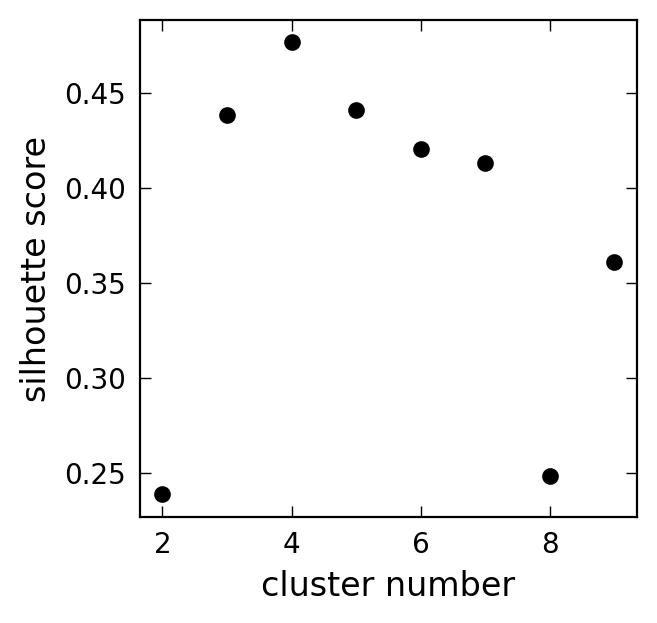

In [16]:
# Set number of clusters
fig, axs = plt.subplots(1,1, figsize=(4, 3.0), sharex='row', sharey=False,layout='constrained')

# Scale and center data for clustering
cluster_input = grid_opt.loc[(grid_opt.perf_index == 0)].groupby(plots, as_index = False).mean()
scaler = StandardScaler()
scaler.fit(cluster_input[opt_vars[0:3] + reg_bl].values)
for_clustering = scaler.transform(cluster_input[opt_vars[0:3] + reg_bl].values)

# compute scores
for k in np.arange(2,10):
    clustering_object = SpectralClustering(n_clusters=k, n_init = 10, random_state=0)
    score = silhouette_score(for_clustering, clustering_object.fit_predict(for_clustering))
    axs.scatter(k,score, color = 'black')

axs.set_xlabel('cluster number', fontsize = 12)
axs.set_ylabel('silhouette score', fontsize = 12)
axs.set_box_aspect(1)
axs.minorticks_off()
axs.tick_params(axis='both', which='major', labelsize=10)

plt.savefig('_figs/figSI_'+comment+'-cluster_silhouette_scores'+'.pdf', format="pdf", transparent=True, dpi=300)

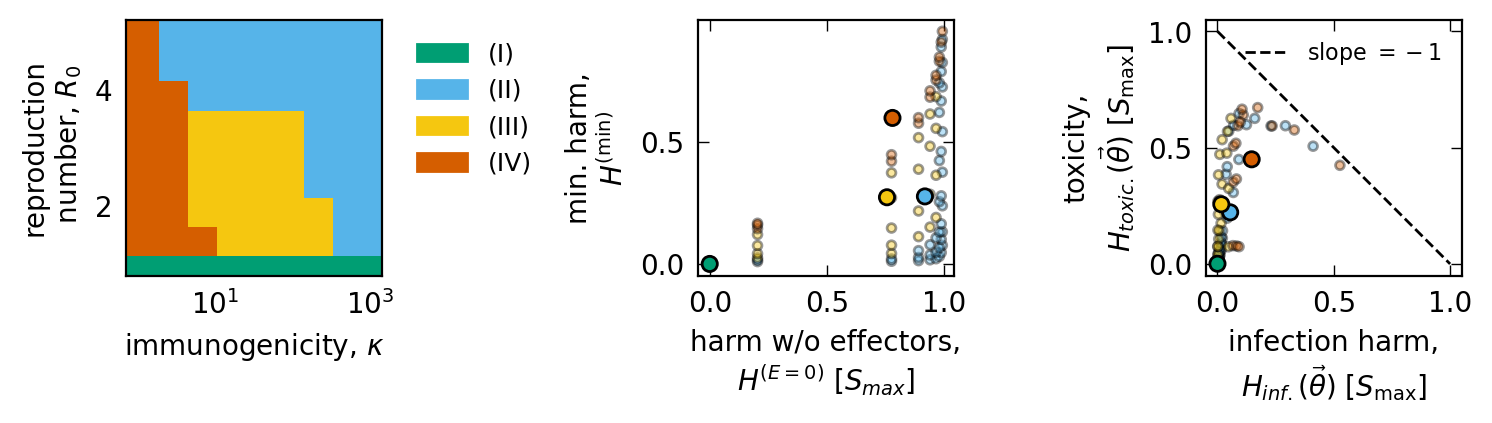

In [17]:
fig, axs = plt.subplots(1, 3, 
                          figsize=(7.75, 2), sharex=False, sharey=False, constrained_layout=True)

size = 1000/np.cbrt(n_virs)

cluster_input = grid_opt.loc[(grid_opt.perf_index == 0)].groupby(plots, as_index = False).mean()
scaler = StandardScaler()
scaler.fit(cluster_input[opt_vars[0:3] + reg_bl].values) # ['K_I', plots[1]] + ['peff_infection', 'peff_toxicity']
for_clustering = scaler.transform(cluster_input[opt_vars[0:3] + reg_bl].values) # ['K_I', plots[1]]  + ['peff_infection', 'peff_toxicity']
clustering_object = SpectralClustering(n_clusters=4, n_init = 10,
        random_state=0)
clustering = clustering_object.fit(for_clustering)

cluster_input.loc[:,'raw_cluster'] = clustering.labels_
assign_phase = cluster_input.groupby(['raw_cluster'], 
                                     as_index = False).min().sort_values(by=plots, 
                                                                          ascending= True).reset_index()[plots + ['raw_cluster']]
cluster_input.loc[:,'phase_cluster'] = np.array([assign_phase.loc[assign_phase.raw_cluster == p].index.tolist()[0] for p in cluster_input.raw_cluster.values]) #clustering.labels_

## Make plots
# (a) Plot infection clusters
axs[0].scatter(S_max/cluster_input[plots[0]], cluster_input[plots[1]],
                 marker ='s', s = size, 
                c = [cluster_colors[i] for i in cluster_input['phase_cluster'].values], 
                 edgecolors = 'None')

axs[0].set_xlabel(plot_labels[0], fontsize = 10)
axs[0].set_ylabel(plot_labels[1], fontsize = 10)
axs[0].semilogx()

legend_handles = []
phase_clusters = np.unique(cluster_input['phase_cluster'].values)
phase_cluster_labels = [r"(I)", r"(II)", r"(III)", r"(IV)"] #, r"(V)"] #, '(VI)']
n_clusters = len(phase_clusters)
for key, color in enumerate([cluster_colors[i] for  i in phase_clusters]):
    patch = mpatches.Patch(color=color, label=str(phase_cluster_labels[key]))
    legend_handles.append(patch)

axs[0].legend(handles=legend_handles, bbox_to_anchor=(1.05, 1.0), fontsize=9, framealpha=0, ncol = 1)

# (b) Plot optimized and unoptimized harm
plot_data = cluster_input.groupby('phase_cluster', as_index = False).mean()

axs[1].scatter(plot_data.harm_pI_noprotection, 
               plot_data.peff_total_harm,
               c = [cluster_colors[i] for i in plot_data.phase_cluster.values],
               s = 30, edgecolors = 'black', zorder = 2)

axs[1].scatter(cluster_input.harm_pI_noprotection, 
               cluster_input.peff_total_harm,
               c = [cluster_colors[i] for i in cluster_input['phase_cluster'].values],
               s = 10, edgecolors = 'black', zorder = 1, alpha = 0.4)

# axs[1].plot(np.linspace(0,1), np.linspace(0,1), color = 'black', linestyle = '--', zorder = 0, label=r'slope $= 1$')
axs[1].locator_params(axis='x', nbins=4)
axs[1].locator_params(axis='y', nbins=4)
#axs[1].legend(fontsize = 8)
axs[1].set_xlabel("harm w/o effectors,\n"+r'$H^{(E = 0)}$ [$S_{max}$]', fontsize = 10)
axs[1].set_ylabel("min. harm,\n"+r'$H^{(\text{min})}$', fontsize = 10)

# (c) Plot optimized infection and toxicity
axs[2].scatter(plot_data.peff_infection, #/plot_data.harm_pI_noprotection, 
               plot_data.peff_toxicity, #/plot_data.harm_pI_noprotection,
               c = [cluster_colors[i] for i in plot_data.phase_cluster.values],
               s = 30, edgecolors = 'black', zorder = 2)

axs[2].scatter(cluster_input.peff_infection, #/cluster_input.harm_pI_noprotection, 
               cluster_input.peff_toxicity, #/cluster_input.harm_pI_noprotection,
               c = [cluster_colors[i] for i in cluster_input['phase_cluster'].values],
               s = 10, edgecolors = 'black', zorder = 1, alpha = 0.4)

axs[2].plot([0,1], [1,0], color = 'black', linestyle = '--', zorder = 0, label=r'slope $= -1$')

axs[2].legend(fontsize = 8)
axs[2].locator_params(axis='x', nbins=4)
axs[2].locator_params(axis='y', nbins=4)

axs[2].set_xlabel("infection harm,\n"+r'$H_{inf.}(\vec\theta)$ [$S_\text{max}$]', fontsize = 10)
axs[2].set_ylabel("toxicity,\n"+r'$H_{toxic.}(\vec\theta)$ [$S_\text{max}$]', fontsize = 10)

for ax in axs.flat:
    ax.set_box_aspect(1)
    ax.minorticks_off()
    ax.tick_params(axis='both', which='major', labelsize=10)

plt.savefig('_figs/fig3_'+comment+'-optimal-reg_hmap'+'.pdf', format="pdf", transparent=True, dpi=300) #, bbox_inches="tight")

The optimal response depends on the Immunogenicity of the pathogens encountered. The optimal design of the response to high Immunogenicity pathogens demonstrates the logic that the system should be tuned to respond to threats that it can easily detect.

In [18]:
# Add cluster information to data
cluster_sim_df = use_sim_data.merge(cluster_input[['idx','phase_cluster']], how = 'left', on = ['idx'])
#cluster_sim_df.loc[:,'phase_cluster'] = cluster_sim_df.apply(lambda row: int(np.mean(cluster_input.phase_cluster.values[np.argmin(np.abs(cluster_input[plots[0]] - row[plots[0]]) + np.abs(cluster_input[plots[1]] - row[plots[1]]))])), axis = 1)

# Compute design performance in each cluster
avg_cluster_data = cluster_sim_df.groupby(opt_vars + ['phase_cluster'], as_index = False).mean()

In [19]:
check_merge = cluster_sim_df.loc[np.isnan(cluster_sim_df.phase_cluster.values)]
len(check_merge)

0

In [20]:
# Compute optimal performance as a function of allowed feedback strength
cluster_grid_opt = pd.concat(Parallel(n_jobs = num_cpu, 
                          batch_size = 6)(delayed(grid_search)(g, type = 'global', top = 0.01)
                                                   for (_, g) in avg_cluster_data.groupby(['phase_cluster'],as_index = False)
                                                  ))

# Compute optimal performance as a function of each individual single design 
# ablate_grid_opt = pd.concat(Parallel(n_jobs = num_cpu, 
#                           batch_size = 1)(delayed(grid_search)(g, type = 'ablate', top = 0.05)
#                                                    for (_, g) in cluster_sim_df.groupby(vir_vars)
#                                                   ))

cluster_ablate_grid_opt = pd.concat(Parallel(n_jobs = num_cpu, 
                          batch_size = 1)(delayed(grid_search)(g, type = 'ablate', top = 0.01)
                                                   for (_, g) in avg_cluster_data.groupby(['phase_cluster'], as_index = False)
                                                  ))

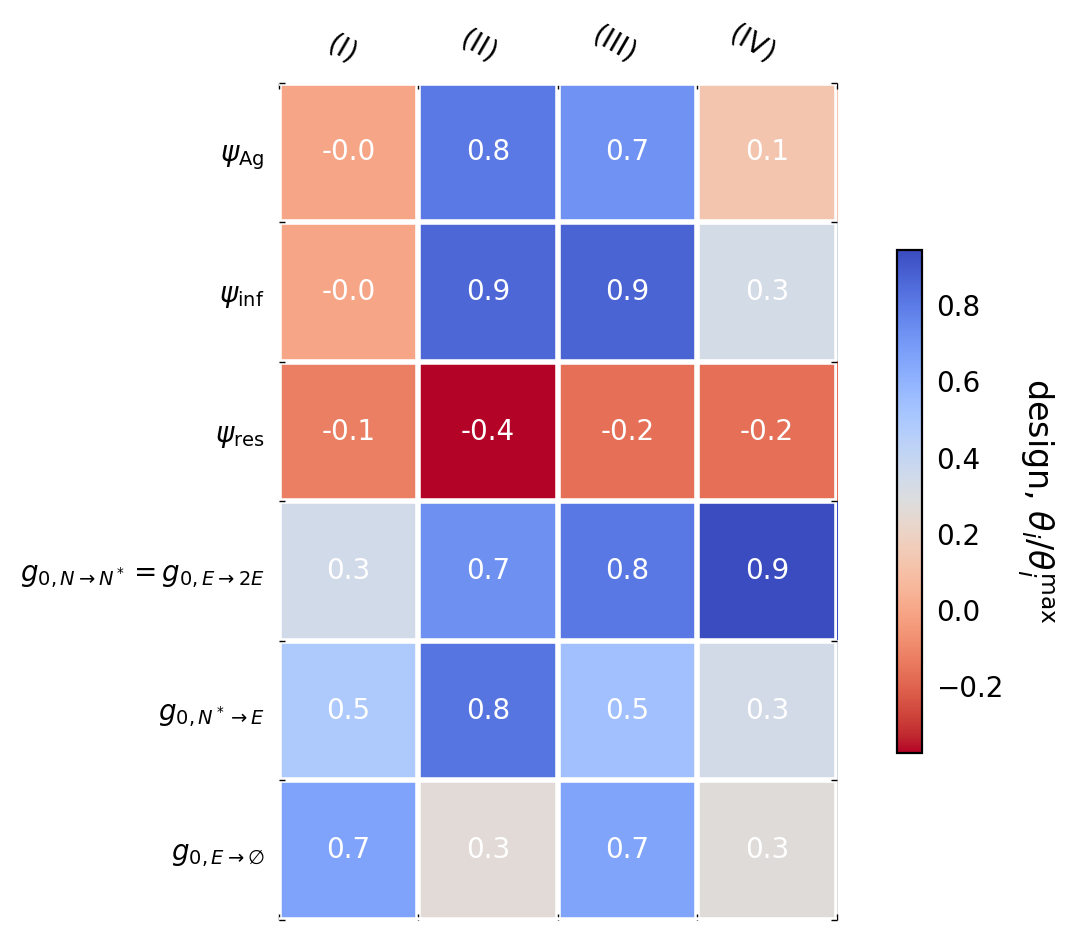

In [21]:
row_labels = opt_vars_labels
col_labels = phase_cluster_labels #[phase_clusters.tolist()
opt_reg_data = (cluster_grid_opt.loc[cluster_grid_opt.perf_index == 0].groupby(['phase_cluster'] + plots, as_index = False).mean()[opt_vars].values/np.array(3*[psi_max] + 3*[1.0])).T

fig, ax = plt.subplots()
im = ax.imshow(opt_reg_data, cmap = 'coolwarm_r')

# Create colorbar
cbar = ax.figure.colorbar(im, ax=ax, shrink = 0.6)
cbar.ax.set_ylabel(r"design, $\theta_i/\theta_i^\text{max}$", rotation=-90, va="bottom")

# Show all ticks and label them with the respective list entries
ax.set_xticks(np.arange(len(col_labels)), labels=col_labels,
              rotation=-30, ha="right", rotation_mode="anchor")
ax.set_yticks(np.arange(len(row_labels)), labels=row_labels)

# Let the horizontal axes labeling appear on top.
ax.tick_params(top=True, bottom=False,
               labeltop=True, labelbottom=False)

# Loop over data dimensions and create text annotations.
for i in np.arange(len(row_labels)):
    for j in np.arange(len(col_labels)):
        text = ax.text(j, i, np.round(opt_reg_data[i, j], 1),
                       ha="center", va="center", color="w")

# Turn spines off and create white grid.
ax.spines[:].set_visible(False)

ax.set_xticks(np.arange(opt_reg_data.shape[1]+1)-.5, minor=True)
ax.set_yticks(np.arange(opt_reg_data.shape[0]+1)-.5, minor=True)
ax.grid(which="minor", color="w", linestyle='-', linewidth=2)
ax.tick_params(which="major", bottom=False, left=False, top = False, right = False)
# #ax.set_title("Optimal feedback designs")
#ax.minorticks_off()

fig.tight_layout()
plt.show()

fig.savefig('_figs/figSI_'+comment+'-cluster_opt-reg_hmap'+'.pdf', format="pdf", transparent=True, dpi=150)

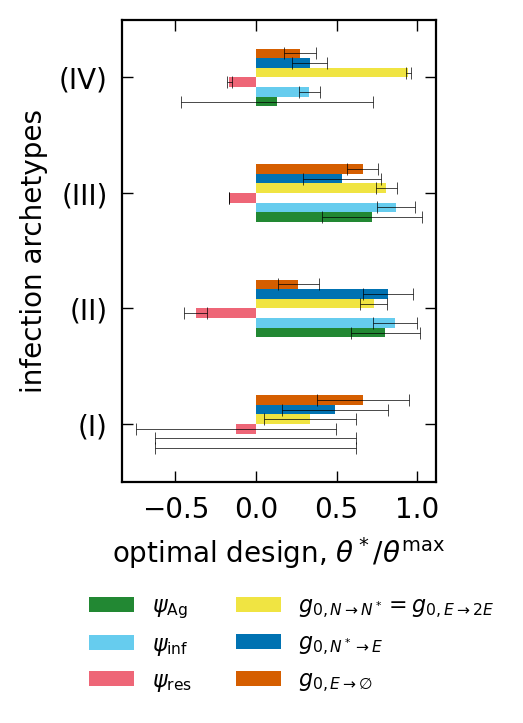

In [22]:
# Prepare data
row_labels = opt_vars_labels
col_labels = phase_cluster_labels #[phase_clusters.tolist()
opt_reg_data = (cluster_grid_opt.loc[cluster_grid_opt.perf_index == 0].groupby(['phase_cluster'] + plots, as_index = False).mean()[opt_vars].values/np.array(3*[psi_max] + 3*[1.0])).tolist()
std_reg_data = (cluster_grid_opt.loc[cluster_grid_opt.perf_index == 0].groupby(['phase_cluster'] + plots, as_index = False).std()[opt_vars].values/np.array(3*[psi_max] + 3*[1.0])).tolist()
# Plot optimal designs
fig, axs = plt.subplots(1,1, figsize=(2.5, 3.5), sharex='row', sharey=False,layout='constrained')

df = pd.DataFrame(opt_reg_data, index=phase_cluster_labels, columns = opt_vars_labels)
std_df = pd.DataFrame(std_reg_data, index=phase_cluster_labels, columns = opt_vars_labels)

df.plot.barh(ax=axs, color = cmap_colors, xerr = std_df, error_kw=dict(lw=0.25, capsize=2, capthick=0.25))
axs.set_xlabel(r"optimal design, $\theta^*/\theta^\text{max}$", fontsize = 10)
axs.legend(bbox_to_anchor=(1.25, -0.20), ncol = 2, fontsize=8)

axs.minorticks_off()
axs.tick_params(axis='both', which='major', labelsize=10)
axs.minorticks_off()
axs.locator_params(axis='y', nbins=6)
axs.locator_params(axis='x', nbins=5)
axs.set_ylabel('infection archetypes', fontsize = 10)
#axs.set_xticklabels(col_labels, rotation='horizontal', size = 8)

fig.savefig('_figs/fig3_'+comment+'-cluster_opt-reg_bars'+'.pdf', format="pdf", transparent=True, dpi=150)

### (b) Pareto optimization of the immune response

In [23]:
# Install package to run Kneedle algorithm: https://pypi.org/project/kneed/
# !pip install --upgrade kneed


#### Compare archetypes pairwise

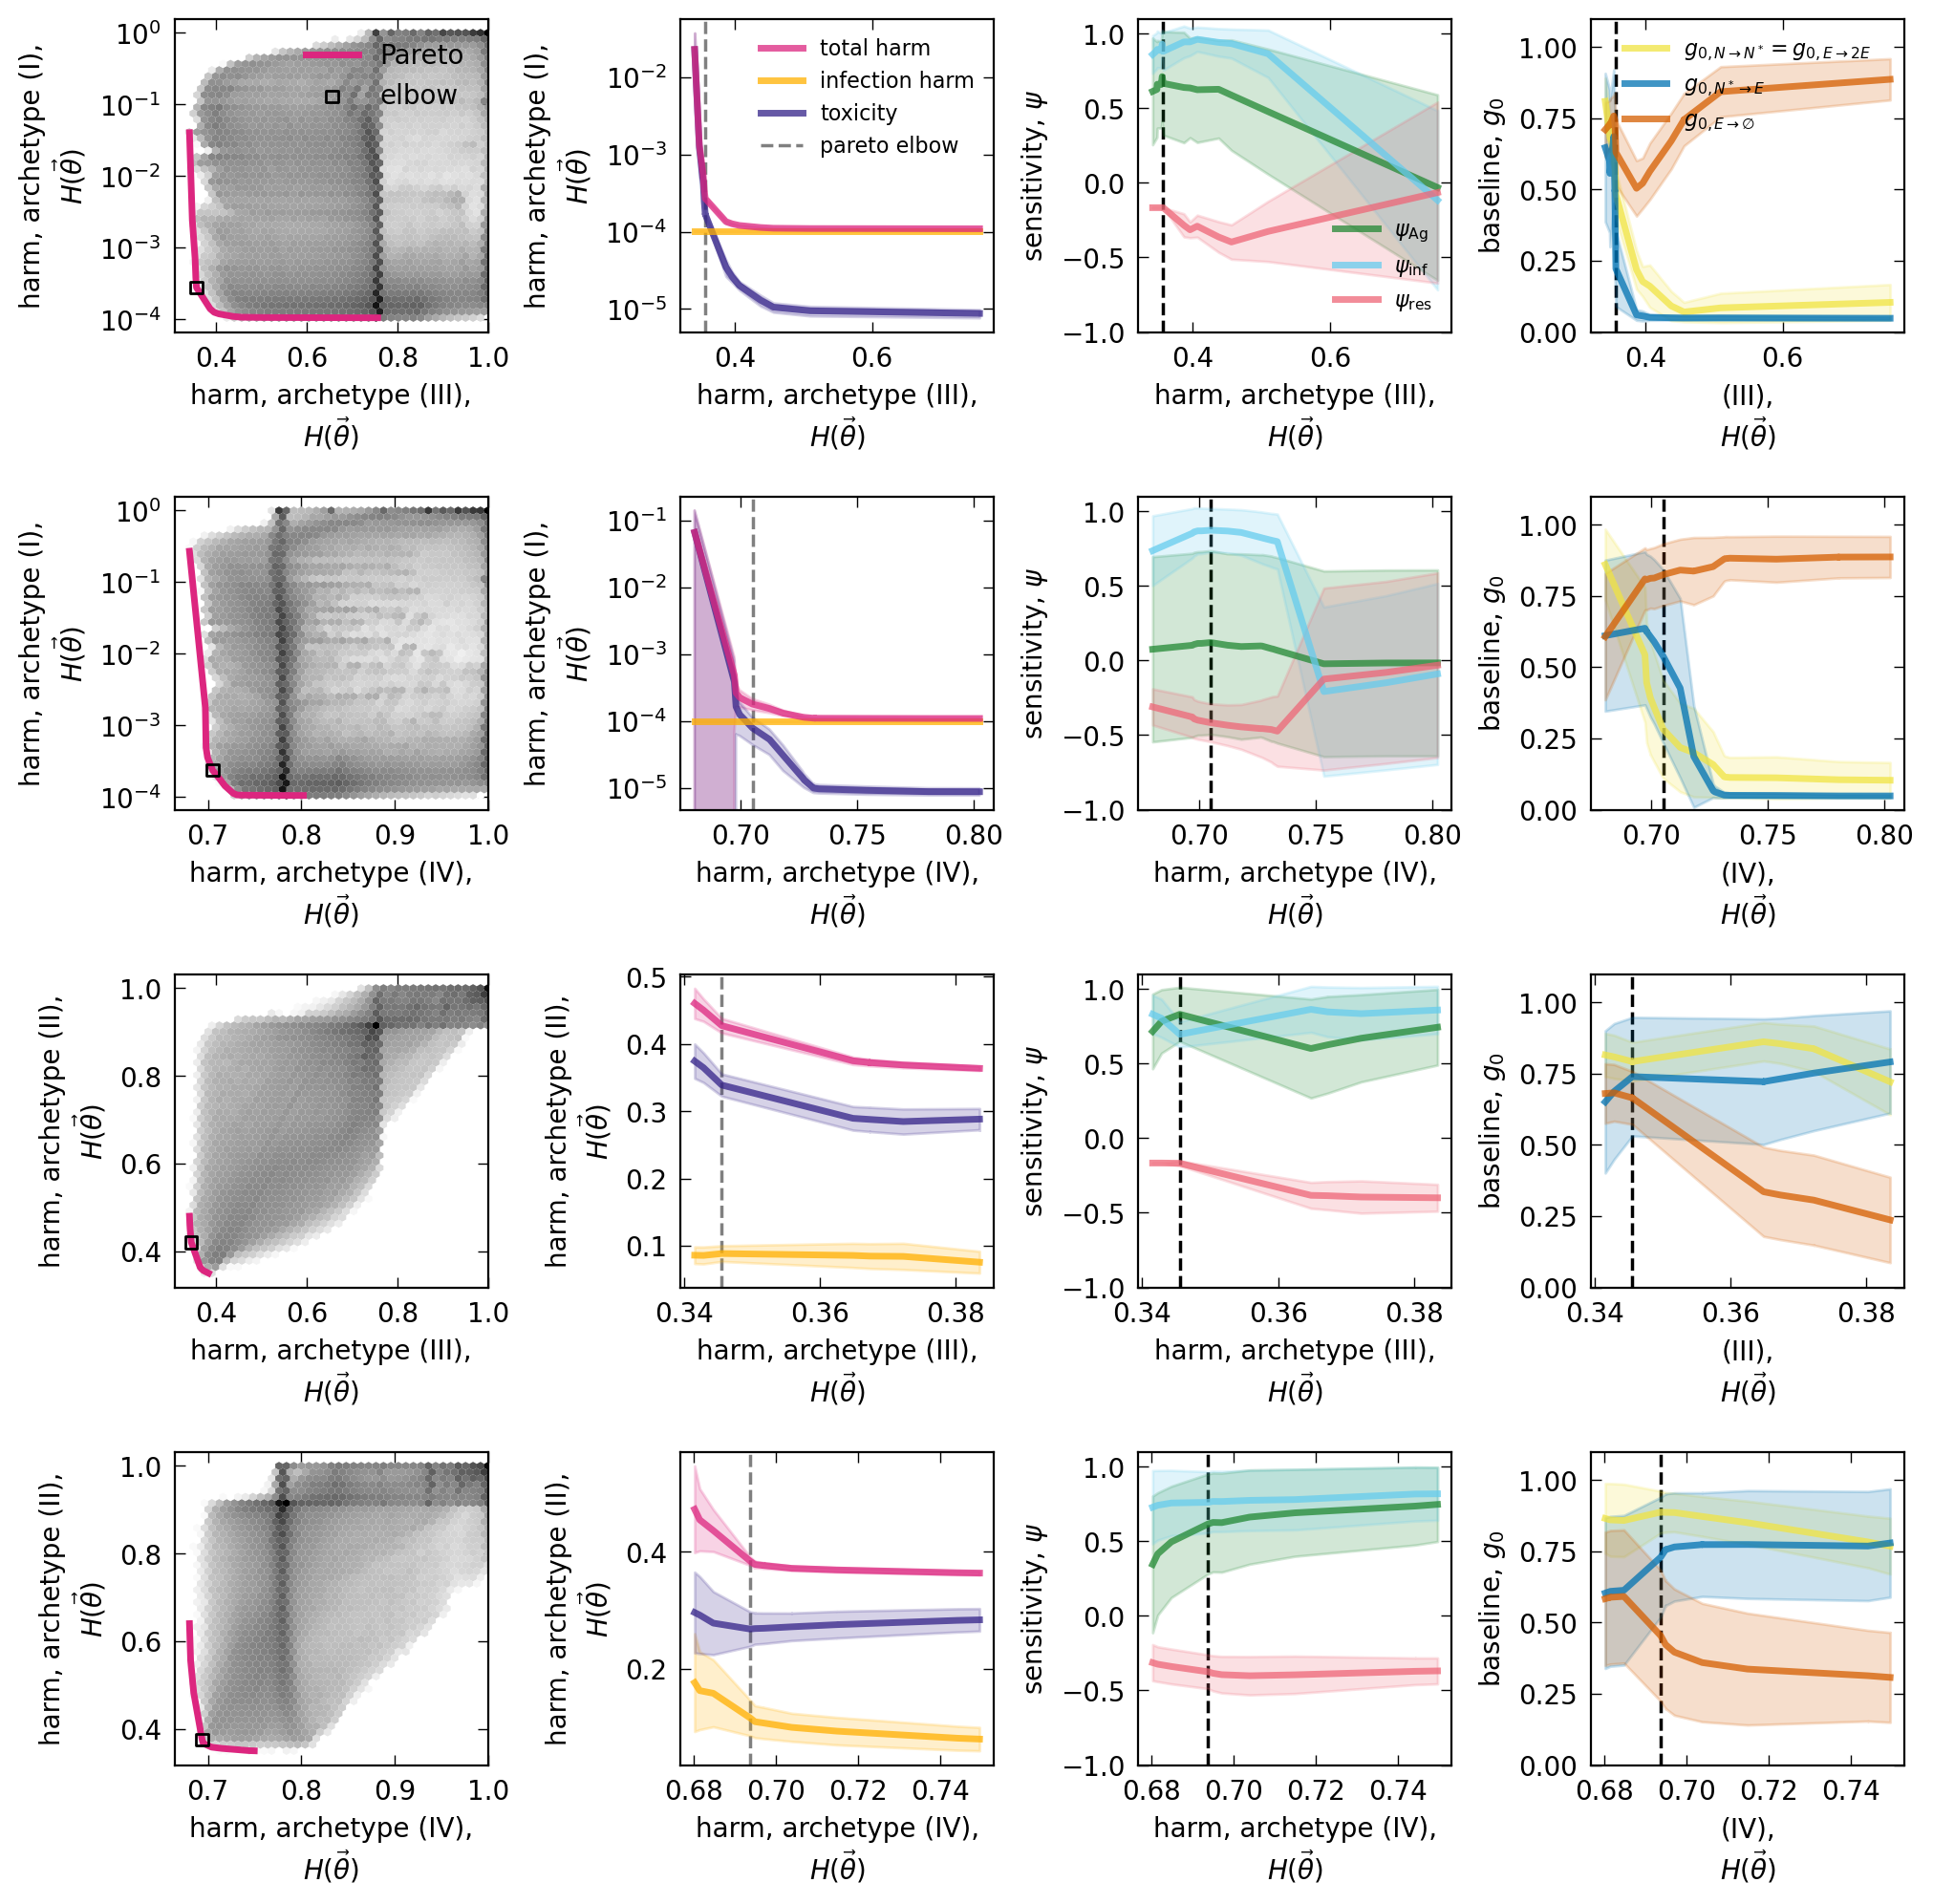

In [24]:
# Visualize pareto regulation
perf_var = 'peff_total_harm'
kwargs = {'linewidth': 2.5, 'markeredgewidth': 0.25, 'markeredgecolor': 'k', 'markersize': 6, 'alpha': 0.75}

subsets = [[2,0], [3,0], [2,1], [3,1]] #, [4,0]]
fig, axs = plt.subplots(len(subsets), 4, figsize=(10, len(subsets)*2.5), sharex=False, sharey=False,layout='constrained')

tol = 0.05 # sets upper bound of harm

for k, [a, b] in enumerate(subsets):
    # (a) Effect of H_E ablation on Harm
    a_group = avg_cluster_data.loc[(avg_cluster_data.phase_cluster == a)]
    b_group = avg_cluster_data.loc[(avg_cluster_data.phase_cluster == b)]
    
    plot_data = a_group.merge(b_group[opt_vars + perf_vars + ['harm_pI_noprotection']], how = 'left', on = opt_vars, suffixes = (None, '_comp'))
    
    im = axs[k,0].hexbin(plot_data[perf_var].values, 
                         plot_data[perf_var+'_comp'].values,
                         gridsize = 40, C = None, yscale='log' if b == 0 else 'linear',
                         cmap='Grays', edgecolors = 'None',
                         norm = mpl.colors.LogNorm())

    if b != 0:
        lambdas = np.linspace(0,1, 51)
    else:
        lambdas = np.logspace(-6,0, 51)
        axs[k,0].semilogy()
        axs[k,1].semilogy()
    axs[k,0].set_xlim(None,1.0)


    pareto_designs = []
    mean_pareto_designs, max_pareto_designs, min_pareto_designs, std_pareto_designs = [], [], [], []

    # In
    for l in lambdas:
        plot_data.loc[:,'compromise'] = l*plot_data[perf_var].values + (1-l)*plot_data[perf_var+'_comp'].values
        plot_data.loc[:,'lambda'] = l
        data_sorted = plot_data.sort_values(by='compromise', ascending= True)
        near_rows= data_sorted.loc[(data_sorted[perf_var] <= (1 + tol)*data_sorted[perf_var].values[0])*(data_sorted[perf_var+'_comp'] <= (1 + tol)*data_sorted[perf_var+'_comp'].values[0])]
        # near_rows = data_sorted.loc[data_sorted.compromise <= 1.05*np.min(data_sorted.compromise)]
        opt_row = near_rows.head(1) # data_sorted.head(1).mean() # 
        mean_row = near_rows.mean()
        max_row = near_rows.max()
        min_row = near_rows.min()
        std_row = near_rows.std()
        pareto_designs.append(opt_row.values)
        mean_pareto_designs.append(mean_row.values)
        max_pareto_designs.append(max_row.values)
        min_pareto_designs.append(min_row.values)
        std_pareto_designs.append(std_row.values)
    
    pareto_design_df = pd.DataFrame(np.vstack(pareto_designs), columns = data_sorted.columns.tolist())
    mean_pareto_design_df = pd.DataFrame(np.vstack(mean_pareto_designs), columns = data_sorted.columns.tolist())
    max_pareto_design_df = pd.DataFrame(np.vstack(max_pareto_designs), columns = data_sorted.columns.tolist())
    min_pareto_design_df = pd.DataFrame(np.vstack(min_pareto_designs), columns = data_sorted.columns.tolist())
    std_pareto_design_df = pd.DataFrame(np.vstack(std_pareto_designs), columns = data_sorted.columns.tolist())
    
    kn = KneeLocator(mean_pareto_design_df.loc[mean_pareto_design_df[perf_var+'_comp'] < (1e-2 if b == 0 else 1.0)][perf_var], 
                     mean_pareto_design_df.loc[mean_pareto_design_df[perf_var+'_comp'] < (1e-2 if b == 0 else 1.0)][perf_var+'_comp'], 
                     curve='convex', direction='decreasing')
    elbow_design = pareto_design_df.loc[np.abs(mean_pareto_design_df[perf_var] - kn.knee).idxmin()]
    
    axs[k,0].plot(pareto_design_df[perf_var].values, 
                  pareto_design_df[perf_var+'_comp'].values,
                  color=perf_var_colors[0], linewidth = 2.5, alpha = 1.0,
               label = "Pareto")
    
    axs[k,0].scatter(elbow_design[perf_var],
                     elbow_design[perf_var+'_comp'],
                   label = r"elbow",
           s = 20,
                     marker = 's',
       color='None', edgecolors = 'black', zorder = 2, linewidth = 1.0)
    
    for l, perf in enumerate([perf_var]+perf_vars[1:3]):
        axs[k,1].fill_between(pareto_design_df[perf_var].values,
                        (std_pareto_design_df[perf+'_comp'].values + mean_pareto_design_df[perf+'_comp'].values)/np.array(3*[psi_max] + 3*[1.0])[i], 
                            (mean_pareto_design_df[perf+'_comp'].values - std_pareto_design_df[perf+'_comp'].values)/np.array(3*[psi_max] + 3*[1.0])[i],
                    alpha=0.2,
                    color = perf_var_colors[l])
        
        axs[k,1].plot(pareto_design_df[perf_var].values,
                      mean_pareto_design_df[perf+'_comp'].values, #/(1.0 if l == 0 else pareto_design_df['harm_pI_noprotection'+'_comp'].values),
                      color = perf_var_colors[l],
                    zorder = 3 - l,
                    label = perf_labels[l], 
                    **kwargs)
    
    for i, var in enumerate(opt_vars):
        if i < 3:
            axs[k,2].fill_between(pareto_design_df[perf_var].values,
                                  (std_pareto_design_df[var].values + mean_pareto_design_df[var].values)/np.array(3*[psi_max] + 3*[1.0])[i], 
                            (mean_pareto_design_df[var].values - std_pareto_design_df[var].values)/np.array(3*[psi_max] + 3*[1.0])[i],
                                # min_pareto_design_df[var].values/np.array(3*[psi_max] + 3*[1.0])[i], 
                                # max_pareto_design_df[var].values/np.array(3*[psi_max] + 3*[1.0])[i],
                                alpha=0.2,
                                color = cmap_colors[i])
            
            axs[k,2].plot(pareto_design_df[perf_var].values,
                          mean_pareto_design_df[var].values/np.array(3*[psi_max] + 3*[1.0])[i],
                        label = opt_vars_labels[i],
                          color = cmap_colors[i], **kwargs)
    
        if i >= 3:
            axs[k,3].fill_between(pareto_design_df[perf_var].values, 
                                  (std_pareto_design_df[var].values + mean_pareto_design_df[var].values)/np.array(3*[psi_max] + 3*[1.0])[i], 
                            (mean_pareto_design_df[var].values - std_pareto_design_df[var].values)/np.array(3*[psi_max] + 3*[1.0])[i],
                                #   min_pareto_design_df[var].values/np.array(3*[psi_max] + 3*[1.0])[i], 
                                # max_pareto_design_df[var].values/np.array(3*[psi_max] + 3*[1.0])[i],
                                alpha=0.2,
                                color = cmap_colors[i])
            
            axs[k,3].plot(pareto_design_df[perf_var].values,
                          mean_pareto_design_df[var].values/np.array(3*[psi_max] + 3*[1.0])[i],
                        label = opt_vars_labels[i],
                          color = cmap_colors[i], **kwargs)

    axs[k,1].axvline(x = elbow_design[perf_var], 
               color = 'grey', linewidth = 1.25, alpha = 1.0, linestyle = '--', zorder = 0,
               label = r"pareto elbow")
    axs[k,2].axvline(x = elbow_design[perf_var], color = 'black', linewidth = 1.25, alpha = 1.0, linestyle = '--', zorder = 0)
    axs[k,3].axvline(x = elbow_design[perf_var], color = 'black', linewidth = 1.25, alpha = 1.0, linestyle = '--', zorder = 0)

    axs[k,0].set_ylabel('harm, archetype '+phase_cluster_labels[b]+",\n"+r"$H(\vec\theta)$", fontsize = 10)
    axs[k,0].set_xlabel('harm, archetype '+phase_cluster_labels[a]+",\n"+r"$H(\vec\theta)$", fontsize = 10)
    
    axs[k,1].set_ylabel('harm, archetype '+phase_cluster_labels[b]+",\n"+r"$H(\vec\theta)$", fontsize = 10)
    axs[k,1].set_xlabel('harm, archetype '+phase_cluster_labels[a]+",\n"+r"$H(\vec\theta)$", fontsize = 10)

    axs[k,2].set_xlabel('harm, archetype '+phase_cluster_labels[a]+",\n"+r"$H(\vec\theta)$", fontsize = 10)
    axs[k,2].set_ylabel("sensitivity, "+ r"$\psi$", fontsize = 10)
    axs[k,2].set_ylim(-1.0, 1.1)
    axs[k,3].set_xlabel(phase_cluster_labels[a]+",\n"+r"$H(\vec\theta)$", fontsize = 10)
    axs[k,3].set_ylabel("baseline, "+ r"$g_0$", fontsize = 10)
    axs[k,3].set_ylim(0.0, 1.1)

axs[0,0].legend(loc='upper right',fontsize=10, framealpha=0, ncol = 1)
axs[0,1].legend(fontsize=8, framealpha=0, ncol = 1)
axs[0,2].legend(fontsize=8) #bbox_to_anchor=(1.0, 1), 
axs[0,3].legend(fontsize=8) # bbox_to_anchor=(1.0, 1), 
#axs[0,0].ticklabel_format(axis='y', style='sci', scilimits=(0,0))

for j, ax in enumerate(axs.flat):
    ax.minorticks_off()
    ax.set_box_aspect(1)
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.locator_params(axis='x', nbins=4)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

#fig.subplots_adjust(wspace=.5, hspace=0.5)

plt.savefig('_figs/figSI_'+comment+'-pareto-harm_compare_clusters'+'.pdf', format="pdf", transparent=True, dpi=150) #, bbox_inches="tight")

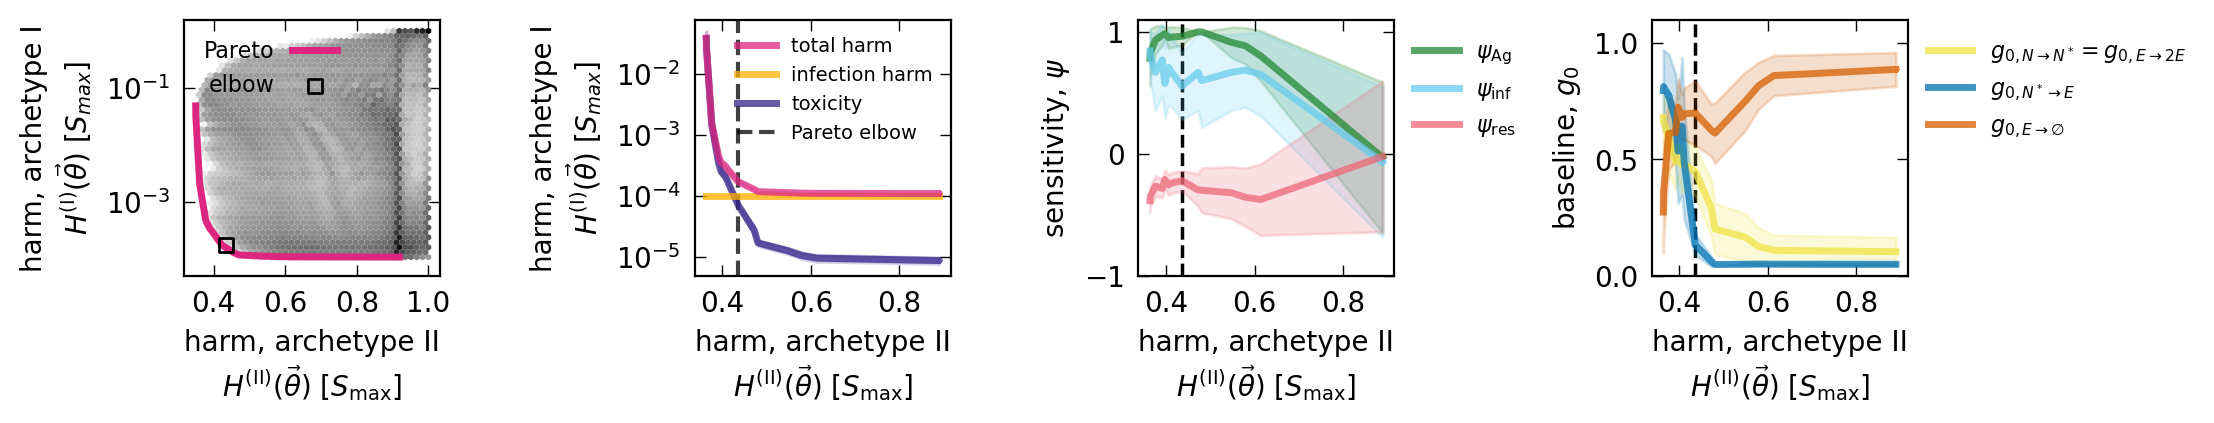

In [25]:
# Visualize pareto regulation
perf_var = 'peff_total_harm'
kwargs = {'linewidth': 2.5, 'markeredgewidth': 0.25, 'markeredgecolor': 'k', 'markersize': 6, 'alpha': 0.75}

fig, axs = plt.subplots(1, 4, figsize=(11, 2), sharex=False, sharey=False, layout='constrained')
tol = 0.05
lambdas = np.logspace(-6,0, 101)
ag_group = avg_cluster_data.loc[(avg_cluster_data.phase_cluster == 1)]
lowR0_group = avg_cluster_data.loc[(avg_cluster_data.phase_cluster == 0)]

plot_data = ag_group.loc[ag_group[perf_var].values > 0].merge(lowR0_group[opt_vars + perf_vars + ['harm_pI_noprotection']], how = 'left', on = opt_vars, suffixes = (None, '_comp'))

im = axs[0].hexbin(plot_data[perf_var].values,
                     plot_data[perf_var+'_comp'].values,
                     gridsize = 40, C = None,  yscale='log',
                     cmap='Grays', edgecolors = 'None',
                     norm = mpl.colors.LogNorm())

pareto_designs = []
ensemble_pareto_designs = []
mean_pareto_designs, max_pareto_designs, min_pareto_designs, std_pareto_designs = [], [], [], []

# In
for l in lambdas:
    plot_data.loc[:,'compromise'] = l*plot_data[perf_var].values + (1-l)*plot_data[perf_var+'_comp'].values
    plot_data.loc[:,'lambda'] = l
    data_sorted = plot_data.sort_values(by='compromise', ascending= True)
    near_rows= data_sorted.loc[(data_sorted[perf_var] <= (1 + tol)*data_sorted[perf_var].values[0])*(data_sorted[perf_var+'_comp'] <= (1 + tol)*data_sorted[perf_var+'_comp'].values[0])]
    # near_rows = data_sorted.loc[data_sorted.compromise <= 1.05*np.min(data_sorted.compromise)]
    opt_row = near_rows.head(1) # data_sorted.head(1).mean() # 
    mean_row = near_rows.mean()
    max_row = near_rows.max()
    min_row = near_rows.min()
    std_row = near_rows.std()
    pareto_designs.append(opt_row.values)
    mean_pareto_designs.append(mean_row.values)
    max_pareto_designs.append(max_row.values)
    min_pareto_designs.append(min_row.values)
    std_pareto_designs.append(std_row.values)
    ensemble_pareto_designs.append(near_rows.values)

pareto_design_df = pd.DataFrame(np.vstack(pareto_designs), columns = data_sorted.columns.tolist())
mean_pareto_design_df = pd.DataFrame(np.vstack(mean_pareto_designs), columns = data_sorted.columns.tolist())
max_pareto_design_df = pd.DataFrame(np.vstack(max_pareto_designs), columns = data_sorted.columns.tolist())
min_pareto_design_df = pd.DataFrame(np.vstack(min_pareto_designs), columns = data_sorted.columns.tolist())
std_pareto_design_df = pd.DataFrame(np.vstack(std_pareto_designs), columns = data_sorted.columns.tolist())
ensemble_pareto_design_df = pd.DataFrame(np.vstack(ensemble_pareto_designs), columns = data_sorted.columns.tolist())

kn = KneeLocator(mean_pareto_design_df.loc[mean_pareto_design_df[perf_var+'_comp'] <= 1e-2][perf_var], # .loc[pareto_design_df[perf_var+'_comp'] <= 1e-3]
                 mean_pareto_design_df.loc[mean_pareto_design_df[perf_var+'_comp'] <= 1e-2][perf_var+"_comp"], # .loc[pareto_design_df[perf_var+'_comp'] <= 1e-3]
                 curve='convex', direction='decreasing')
elbow_design = mean_pareto_design_df.loc[np.abs(mean_pareto_design_df[perf_var] - kn.knee).idxmin()]
#ensemble_elbow_design = ensemble_pareto_design_df.loc[(ensemble_pareto_design_df[perf_var] <= 1.05*pareto_design_df.loc[pareto_design_df['lambda'] == elbow_design['lambda']][perf_var].values[0])*(ensemble_pareto_design_df[perf_var+'_comp'] <= 1.05*pareto_design_df.loc[pareto_design_df['lambda'] == elbow_design['lambda']][perf_var+'_comp'].values[0])]
ensemble_elbow_design = ensemble_pareto_design_df.loc[ensemble_pareto_design_df['lambda'] == elbow_design['lambda']]

#elbow_design = pareto_design_df.loc[pareto_design_df['peff_toxicity_comp'] < pareto_design_df['peff_infection_comp']].iloc[0]

axs[0].plot(pareto_design_df[perf_var].values, 
              pareto_design_df[perf_var+'_comp'].values,
              color=perf_var_colors[0], linewidth = 2.5, alpha = 1.0,
           label = "Pareto")

axs[0].scatter(elbow_design[perf_var], 
               elbow_design[perf_var+'_comp'],
               label = r"elbow",
       s = 25,
       marker = 's',
       color='None', edgecolors = 'black', zorder = 2, linewidth = 1.0)

axs[0].set_xlim(None, None)
axs[0].set_ylim(5e-5, None)

for l, perf in enumerate([perf_var] + perf_vars[1:3]):
    axs[1].fill_between(mean_pareto_design_df[perf_var].values,
                        std_pareto_design_df[perf+'_comp'].values + mean_pareto_design_df[perf+'_comp'].values, #min_pareto_design_df[perf+'_comp'].values, 
                        mean_pareto_design_df[perf+'_comp'].values - std_pareto_design_df[perf+'_comp'].values, #max_pareto_design_df[perf+'_comp'].values, 
                    alpha=0.2,
                    color = perf_var_colors[l])
     
    axs[1].plot(mean_pareto_design_df[perf_var].values,
                mean_pareto_design_df[perf+'_comp'].values, #/(1.0 if l == 0 else pareto_design_df['harm_pI_noprotection'+'_comp'].values),
                  color = perf_var_colors[l],
                zorder = 3 - l,
                label = perf_labels[l], 
                **kwargs)

for i, var in enumerate(opt_vars):
    if i < 3:
        axs[2].fill_between(mean_pareto_design_df[perf_var].values,
                            (std_pareto_design_df[var].values + mean_pareto_design_df[var].values)/np.array(3*[psi_max] + 3*[1.0])[i], 
                            (mean_pareto_design_df[var].values - std_pareto_design_df[var].values)/np.array(3*[psi_max] + 3*[1.0])[i],
                            # np.minimum(min_pareto_design_df[var].values/np.array(3*[psi_max] + 3*[1.0])[i], max_pareto_design_df[var].values/np.array(3*[psi_max] + 3*[1.0])[i]), 
                            # np.maximum(min_pareto_design_df[var].values/np.array(3*[psi_max] + 3*[1.0])[i], max_pareto_design_df[var].values/np.array(3*[psi_max] + 3*[1.0])[i]), 
                            alpha=0.2,
                            color = cmap_colors[i])
        
        axs[2].plot(mean_pareto_design_df[perf_var].values,
                      mean_pareto_design_df[var].values/np.array(3*[psi_max] + 3*[1.0])[i],
                    label = opt_vars_labels[i],
                      color = cmap_colors[i], **kwargs)

    if i >= 3:
        axs[3].fill_between(mean_pareto_design_df[perf_var].values,
                            (std_pareto_design_df[var].values + mean_pareto_design_df[var].values)/np.array(3*[psi_max] + 3*[1.0])[i], 
                            (mean_pareto_design_df[var].values - std_pareto_design_df[var].values)/np.array(3*[psi_max] + 3*[1.0])[i],
                            # np.minimum(min_pareto_design_df[var].values/np.array(3*[psi_max] + 3*[1.0])[i], max_pareto_design_df[var].values/np.array(3*[psi_max] + 3*[1.0])[i]), 
                            # np.maximum(min_pareto_design_df[var].values/np.array(3*[psi_max] + 3*[1.0])[i], max_pareto_design_df[var].values/np.array(3*[psi_max] + 3*[1.0])[i]), 
                            alpha=0.2,
                            color = cmap_colors[i])
        
        axs[3].plot(mean_pareto_design_df[perf_var].values,
                      mean_pareto_design_df[var].values/np.array(3*[psi_max] + 3*[1.0])[i],
                    label = opt_vars_labels[i],
                      color = cmap_colors[i], **kwargs)

axs[1].axvline(x = elbow_design[perf_var], 
               color = 'black', linewidth = 1.5, alpha = 0.75, linestyle = '--', zorder = 0,
               label = r"Pareto elbow")
axs[2].axvline(x = elbow_design[perf_var], color = 'black', linewidth = 1.25, alpha = 1.0, linestyle = '--', zorder = 0)
axs[3].axvline(x = elbow_design[perf_var], color = 'black', linewidth = 1.25, alpha = 1.0, linestyle = '--', zorder = 0)
#axs[1].set_xlim(None, 1.0)
axs[1].semilogy()
# axs[1].set_yscale('symlog')

axs[0].set_ylabel('harm, archetype I\n'+r"$H^{(\text{I})}(\vec\theta)$ [$S_{max}$]", fontsize = 10)
axs[0].set_xlabel('harm, archetype II\n'+r"$H^{(\text{II})}(\vec\theta)$ [$S_\text{max}$]", fontsize = 10)

axs[1].set_ylabel('harm, archetype I\n'+r"$H^{(\text{I})}(\vec\theta)$ [$S_{max}$]", fontsize = 10)
axs[1].set_xlabel('harm, archetype II\n'+r"$H^{(\text{II})}(\vec\theta)$ [$S_\text{max}$]", fontsize = 10)

axs[2].set_xlabel('harm, archetype II\n'+r"$H^{(\text{II})}(\vec\theta)$ [$S_\text{max}$]", fontsize = 10)
axs[2].set_ylabel("sensitivity, "+ r"$\psi$", fontsize = 10)
axs[2].set_ylim(-1.0, 1.1)
# axs[2].set_xlim(None, 1.0)

axs[3].set_xlabel('harm, archetype II\n'+r"$H^{(\text{II})}(\vec\theta)$ [$S_\text{max}$]", fontsize = 10)
axs[3].set_ylabel("baseline, "+ r"$g_0$", fontsize = 10)
axs[3].set_ylim(.0, 1.1)
# axs[3].set_xlim(None, 1.0)

axs[0].legend(fontsize=8, loc='upper left', framealpha=0, markerfirst= False, labelcolor = 'black')
axs[1].legend(fontsize=7, framealpha=0)
axs[2].legend(bbox_to_anchor=(1.0, 1.0), loc='upper left', ncol = 1, fontsize=8, framealpha=0)
axs[3].legend(bbox_to_anchor=(1.0, 1.0), loc='upper left', ncol = 1, fontsize=8, framealpha=0)

for j, ax in enumerate(axs.flat):
    ax.minorticks_off()
    ax.set_box_aspect(1)
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.locator_params(axis='x', nbins=4)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

plt.savefig('_figs/fig4_'+comment+'-pareto_harm'+'.pdf', format="pdf", transparent=True, dpi=300) #, bbox_inches="tight")

#### Store elbow regulatory design

In [26]:
ensemble_pareto_reg = ensemble_elbow_design[opt_vars[0:3] + reg_bl].drop_duplicates().values
avg_pareto_reg = np.mean(ensemble_pareto_reg, axis = 0) # elbow_design[opt_vars[0:3] + reg_bl].values
print(avg_pareto_reg)

[ 2.88888889  1.66666667 -0.66666667 -0.22222222 -1.94444444  0.94444444]


In [27]:
print('lambda: ',elbow_design['lambda'], 
      ', ensemble size: ', len(ensemble_pareto_reg))

lambda:  0.001513561248436207 , ensemble size:  9


In [28]:
ensemble_elbow_design[opt_vars[0:3] + reg_bl + perf_vars].drop_duplicates()

,psi_I,psi_HI,psi_HE,L0_Na,L0_NE,L0_Edie,peff_total_harm,peff_infection,peff_toxicity,max_pE
359768,3.0,2.0,-1.0,-0.5,-3.0,0.0,0.422984,0.214361,0.208622,464246.027778
359769,3.0,1.0,-0.5,-1.0,-2.0,0.0,0.426584,0.229404,0.197180,494275.611111
359770,3.0,1.5,-0.5,0.0,-1.5,1.5,0.432889,0.208331,0.224558,536301.388889
359771,3.0,1.5,-0.5,0.5,-1.5,2.5,0.431268,0.242923,0.188345,522686.027778
359772,3.0,1.0,-0.5,-0.5,-2.0,0.5,0.439424,0.251813,0.187611,475035.361111
359773,2.5,1.0,-0.5,0.0,-2.0,1.0,0.441343,0.277439,0.163905,425304.166667
359774,3.0,3.0,-1.0,-0.5,-1.5,1.0,0.443748,0.159116,0.284632,640271.777778
359775,2.5,3.0,-1.0,0.0,-2.0,1.0,0.442336,0.161440,0.280896,598498.805556
359776,3.0,1.0,-0.5,0.0,-2.0,1.0,0.440795,0.270776,0.170019,433408.333333


#### Explore pareto dynamics with effector expansion

In [29]:
# # Visualize pareto regulation
# perf = 0

# fig, axs = plt.subplots(n_clusters, 2, figsize=(5, n_clusters*2 + 1), sharex='col', sharey=False,layout='constrained')

# lambdas = np.logspace(-6,0, 31)

# for k, b in enumerate(phase_clusters):
#     # (a) Effect of H_E ablation on Harm
#     plot_data = avg_cluster_data.loc[(avg_cluster_data.phase_cluster == b)*(avg_cluster_data.max_pE > 0)]

#     # im = axs[k,0].scatter(plot_data['max_pE'].values,
#     #                       plot_data['peff_scaled_total_harm'].values,
#     #                       s = 2,
#     #                       c = plot_data[opt_vars[2]], cmap='coolwarm_r',
#     #                       edgecolors = 'None')

#     im = axs[k,0].hexbin(plot_data['max_pE'].values,
#                          plot_data['peff_total_harm'].values,
#                          gridsize = 40, C = None,  
#                          xscale='log',
#                          yscale='linear',
#                          cmap='Grays', edgecolors = 'None',
#                          norm = mpl.colors.LogNorm())

#     # axs[2,0].set_yscale('symlog')
#     # axs[k,0].semilogx()
#     # axs[k,0].set_ylim(None,0.5)

#     pareto_designs = []

#     # In
#     for l in lambdas:
#         plot_data.loc[:,'compromise'] = (1 - l)*plot_data['max_pE'].values/np.amax(plot_data['max_pE'].values) + l*plot_data['peff_total_harm'].values/np.amax(np.abs(plot_data['peff_total_harm'].values))
#         data_sorted = plot_data.sort_values(by='compromise', ascending= True)
#         max_row = data_sorted.head(1)
#         #pareto_index = np.argmax((1 - l)*plot_data['peff_scaled_total_harm'].values + l*plot_data['peff_scaled_total_harm_comp'].values)

#         pareto_designs.append(max_row) # plot_data.loc[pareto_index]

#     pareto_design_df = pd.concat(pareto_designs)

#     axs[k,0].plot(pareto_design_df['max_pE'].values, 
#                   pareto_design_df['peff_total_harm'].values,
#               color=perf_var_colors[0], linewidth = 2.0, alpha = 0.75,
#              label = "Pareto" if k == 0 else "")

#     for l, perf in enumerate(perf_vars[0:3]):
#         axs[k,1].plot(pareto_design_df['max_pE'].values,
#                       pareto_design_df[perf].values,
#                       color = perf_var_colors[l],
#                       label = perf_labels[l],
#                       **kwargs)

#     axs[k,0].set_ylabel(phase_cluster_labels[b]+r", $\tilde{H}(\vec\theta)$", fontsize = 10)
#     axs[k,0].set_xlabel(r'max effector, $E_{max}$', fontsize = 10)
    
#     axs[k,1].set_xlabel(r'max effector, $E_{max}$', fontsize = 10)
#     axs[k,1].set_ylabel(phase_cluster_labels[b]+r", $\tilde{H}(\vec\theta)$", fontsize = 10)
#     axs[k,1].semilogx()

# axs[1,1].legend(fontsize=8, framealpha=0, ncol = 1)

# for ax in axs.flat:
#     ax.minorticks_off()
#     ax.set_box_aspect(1)
#     ax.tick_params(axis='both', which='major', labelsize=10)
#     ax.xaxis.set_tick_params(labelbottom=True)
#     ax.yaxis.set_tick_params(labelleft=True)

# # fig.subplots_adjust(wspace=.5, hspace=0.5)

# plt.savefig('_figs/figSI_'+comment+'-pareto-clusters_prot_effector'+'.pdf', format="pdf", transparent=True, dpi=300)

#### Explore performance of (I)-(II) optimized response

In [75]:
from optimize_nets import *

runs = 5
d="/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/raw"
ps = ensemble_pareto_reg

psis = np.array([ps[:,0], ps[:,1], ps[:,2], ps[:,3], # Na
                 ps[:,0], ps[:,1], ps[:,2], ps[:,4], # NE
                 -0*ps[:,0], -0*ps[:,1], -0*ps[:,2], -L0_max**4 -0*ps[:,4], # EM
                 -ps[:,0], -ps[:,1], -ps[:,2], ps[:,5]]).T  # Edie

# sample = np.array(np.meshgrid(np.unique(np.round(cluster_input.b_I, 9)), # vary b_I
#                                    np.unique(np.round(cluster_input.K_I, 3)), # vary K_I
#                                    np.unique(cluster_input.d_I), # vary d_I
#                                    np.unique(cluster_input.K_H), # vary K_H
#                                    np.unique(cluster_input.N_0), # vary N_0
#                                    np.unique(cluster_input.I_0), # vary I_0
#                                    np.array([S_max]), # vary K_S
#                                         np.array([d_IE]), # vary d_IE
#                                         np.array([d_H]), # vary d_H
#                                         np.array([max_Na]), # vary max_Na
#                                         np.array([max_expand]) # vary max_expand
#                                            )).T.reshape(-1,11)
sample = np.array(np.meshgrid(np.unique(grid_opt.b_I), # vary b_I
                                   np.unique(grid_opt.K_I), # vary K_I
                                   np.unique(grid_opt.d_I), # vary d_I
                                   np.unique(grid_opt.K_H), # vary K_H
                                   np.unique(grid_opt.N_0), # vary N_0
                                   np.unique(grid_opt.I_0), # vary I_0
                                   np.array([S_max]), # vary K_S
                                        np.array([d_IE]), # vary d_IE
                                        np.array([d_H]), # vary d_H
                                        np.array([max_Na]), # vary max_Na
                                        np.array([max_expand]) # vary max_expand
                                           )).T.reshape(-1,11)


# run simulations for extreme scenarios
# run(batch = [-1], outdir=d, inf_sample = sample, 
#     comment="pareto_reg_sim"+'-'+model, runs = runs, infection_model = 'acute', 
#     default_reg = psis,
#     num_cpu = num_cpu)

d_file = d + '/sim_batch_-1-5-acute-pareto_reg_sim'+'-'+model+'.pkl'
with open(d_file, 'rb') as f:   
    data_dict = pickle.load(f)

parameters = data_dict["parameters"]
sim_summary = data_dict["summary_stats"]
# cell_series = data_dict["cell_time_series"]

var_names = np.concatenate((param_names_for_df, stat_names_for_df))
crit_reg_data = pd.DataFrame(np.hstack((parameters, sim_summary)),
                              columns = [i for i in var_names]) #.merge(cluster_input[['K_I', 'b_I'] + ['phase_cluster']], how = 'left', on = ['K_I', 'b_I'])

crit_reg_data.loc[:, 'R_0'] = S_max*crit_reg_data['b_I']/crit_reg_data['d_I']
crit_reg_data.loc[:,opt_vars[0:3]] = np.round(crit_reg_data[['psi_NE_I', 'psi_NE_HI', 'psi_NE_HE']].values, 3)
crit_reg_data.loc[:,opt_vars[3:]] = np.round(1/(1 + np.exp(-crit_reg_data[reg_bl].values)), 3)
crit_reg_data.loc[:,"harm_pI_noprotection"] = crit_reg_data.apply(lambda row: np.mean(cluster_input.harm_pI_noprotection.values[np.argmin(np.abs(cluster_input[plots[0]] - row[plots[0]]) + np.abs(cluster_input[plots[1]] - row[plots[1]]))]), axis=1)

crit_reg_data.loc[:,"peff_infection"] = crit_reg_data['harm_pI']/S_max
crit_reg_data.loc[:,"peff_toxicity"] = crit_reg_data['harm_pS']/S_max
crit_reg_data.loc[:,"peff_total_harm"] = crit_reg_data['peff_infection'] + crit_reg_data['peff_toxicity']
crit_reg_data.loc[:,"peff_scaled_total_harm"] = (crit_reg_data['peff_infection'] + crit_reg_data['peff_toxicity'])/crit_reg_data["harm_pI_noprotection"]

crit_eff_dyn_design = crit_reg_data.groupby(plots, as_index = False, sort = True).mean()
std_crit_eff_dyn_design = crit_reg_data.groupby(plots, as_index = False, sort = True).std()
std_crit_eff_dyn_design.loc[:,"phase_cluster"] = cluster_input.phase_cluster.values
#crit_eff_dyn_design = cluster_sim_df.loc[np.sum(np.abs(cluster_sim_df[opt_vars[0:3] + reg_bl].values - avg_pareto_reg), axis = 1) == 0]
crit_eff_dyn_design.loc[:,"phase_cluster"] = cluster_input.phase_cluster.values
crit_eff_dyn_design.loc[:,"del_peff_total_harm"] = crit_eff_dyn_design.peff_total_harm.values - cluster_input.peff_total_harm.values
crit_eff_dyn_design.loc[:,"del_peff_infection"] = (crit_eff_dyn_design.peff_infection - cluster_input.peff_infection.values)
crit_eff_dyn_design.loc[:,"del_peff_toxicity"] = (crit_eff_dyn_design.peff_toxicity - cluster_input.peff_toxicity.values) #/crit_eff_dyn_design.harm_pI_noprotection

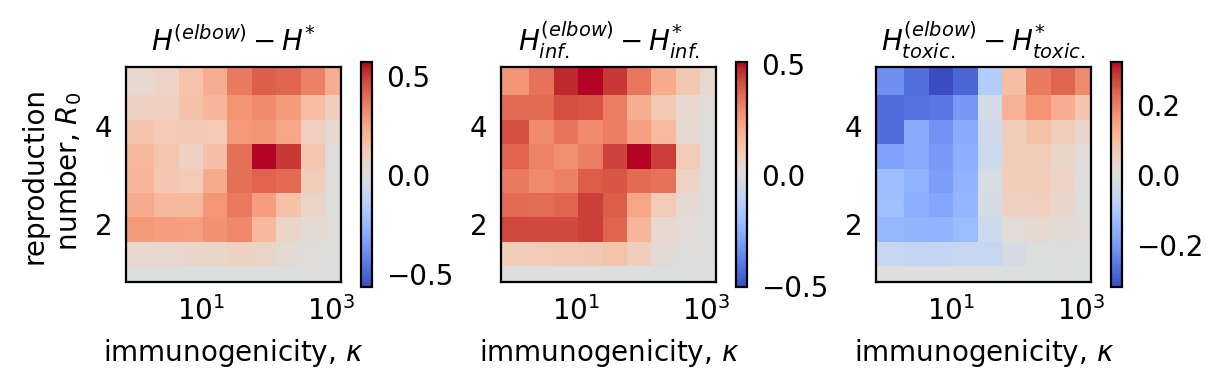

In [61]:
# Visualize optimal Harm and regulation
fig, axs = plt.subplots(1, 3, 
                          figsize=(6, 2), sharex=True, sharey=True, constrained_layout=True)

size = 750/np.cbrt(n_virs)

variables = ['del_peff_total_harm', 'del_peff_infection', 'del_peff_toxicity'] # 'harm_pI_noprotection'
data = crit_eff_dyn_design

for k, (var, ax) in enumerate(zip(variables, axs.flat)):

    z = data[var].values
    range = np.amax(np.abs(z))
    im = ax.scatter(S_max/data[plots[0]], data[plots[1]],
                 marker ='s', s = size, c = z, 
                 cmap='coolwarm', edgecolors = 'None',# alpha = 0.8, 
                 norm = mpl.colors.Normalize(vmin = -range, vmax = range))

    z_label = ([r'$H^{(elbow)}-H^{*}$',
                r'$H_{inf.}^{(elbow)}-H_{inf.}^{*}$',
                r'$H_{toxic.}^{(elbow)}-H_{toxic.}^{*}$'])[k]
    ax.set_title(z_label, fontsize = 10.0)
    ax.set_box_aspect(1)
    ax.semilogx()
    ax.minorticks_off()
    ax.locator_params(axis='y', nbins=4)
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

    ax.set_xlabel(plot_labels[0], fontsize = 10)
    if k % 3 == 0:
        ax.set_ylabel(plot_labels[1], fontsize = 10)
    cb = fig.colorbar(im, ax=ax, location='right', shrink = 0.6, pad = 0.025)
    # cb.set_label(z_label, fontsize = 10)
    cb.ax.tick_params(labelsize=10)

#fig.subplots_adjust(wspace=0.25, hspace=0.3)

plt.savefig('_figs/figSI_'+comment+'-singles-pareto-delta_harm-hmap'+'.pdf', dpi=300) #, bbox_inches="tight")

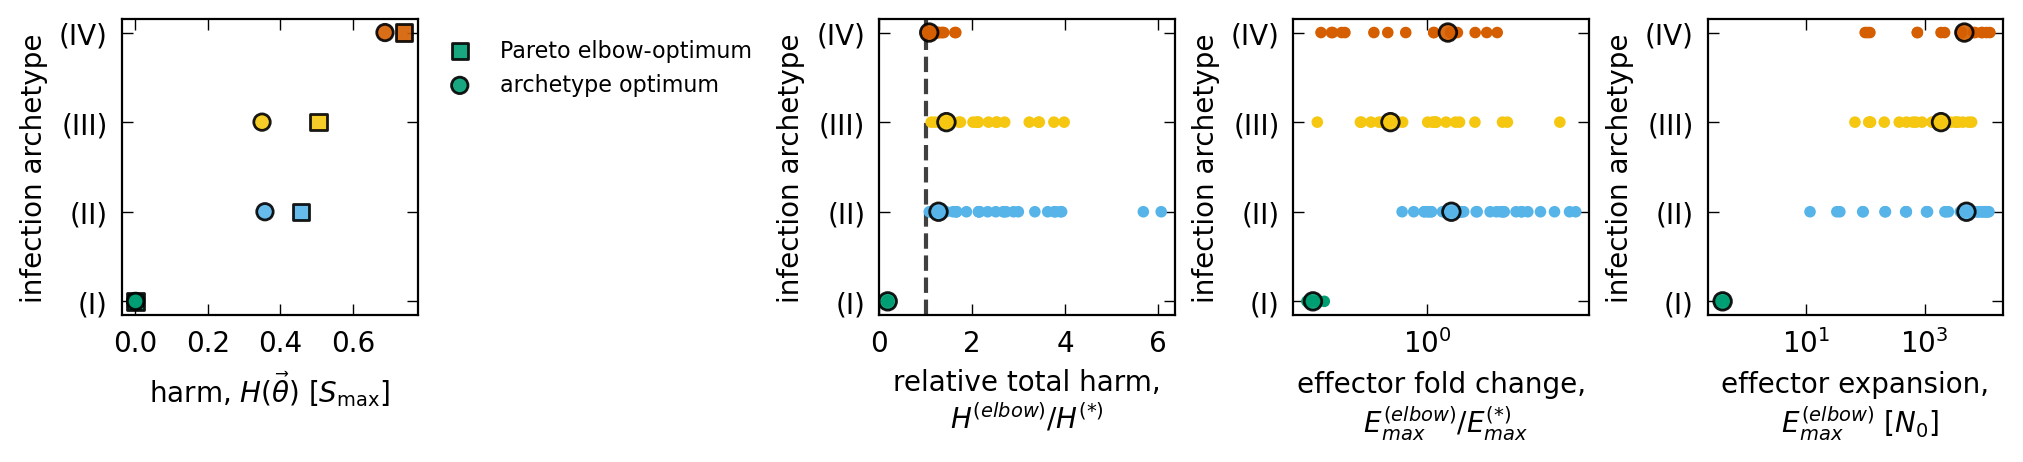

In [76]:
fig, axs = plt.subplots(1, 4, figsize=(10, 2.25), sharey = False, constrained_layout=True)
plot_data = crit_eff_dyn_design.groupby(['phase_cluster'], as_index = False).mean() # avg_cluster_data.loc[np.sum(np.abs(avg_cluster_data[opt_vars[0:3] + reg_bl].values - avg_pareto_reg), axis = 1) == 0]
std_data = std_crit_eff_dyn_design.groupby(['phase_cluster'], as_index = False).mean()

axs[0].scatter(plot_data.peff_total_harm.values,
               plot_data.phase_cluster,
               c = [cluster_colors[int(i)] for i in plot_data.phase_cluster.values],
               marker = 's',
               label = 'Pareto elbow-optimum', #r'Pareto, $\vec\theta^{(\text{elbow})}$',
               s = 35, edgecolors = 'black', zorder = 2, alpha = 0.9)

axs[0].scatter(cluster_grid_opt.loc[cluster_grid_opt.perf_index == 0].groupby(['phase_cluster'], as_index = False).mean().peff_total_harm.values,
               plot_data.phase_cluster,
               c = [cluster_colors[int(i)] for i in plot_data.phase_cluster.values],
               marker = 'o',
               label = 'archetype optimum', #r'minimizer, $\vec\theta^{(\text{min})}$',
               s = 35, edgecolors = 'black', zorder = 2, alpha = 0.9)

axs[0].set_xlabel('harm, '+r'$H(\vec\theta)$ [$S_\text{max}$]', fontsize = 10)
axs[0].legend(bbox_to_anchor=(1.0, 1.0), loc='upper left', ncol = 1, fontsize=8, framealpha=0)
axs[0].locator_params(axis='x', nbins=6)

axs[1].scatter((plot_data.peff_total_harm.values/cluster_grid_opt.loc[cluster_grid_opt.perf_index == 0].groupby(['phase_cluster'] + plots, as_index = False).mean().peff_total_harm.values), #/plot_data.harm_pI_noprotection.values,
               plot_data.phase_cluster,
               c = [cluster_colors[int(i)] for i in plot_data.phase_cluster.values],
               s = 40, edgecolors = 'black', zorder = 2, alpha = 0.9)

axs[1].scatter(crit_eff_dyn_design.peff_total_harm/cluster_input.peff_total_harm.values, crit_eff_dyn_design.phase_cluster,
              s = 10, color = [cluster_colors[int(i)] for i in crit_eff_dyn_design['phase_cluster'].values])

axs[1].set_xlabel('relative total harm,\n'+r'$H^{(elbow)}/H^{(*)}$', fontsize = 10)
axs[1].set_xlim(0.0, None)
axs[1].locator_params(axis='x', nbins=6)
axs[1].axvline(x = 1.0, color = 'black', linewidth = 1.5, alpha = 0.75, linestyle = '--', zorder = 0)

# axs[1].set_xlim(0.0, None)

axs[2].scatter((plot_data.max_pE.values/cluster_grid_opt.loc[cluster_grid_opt.perf_index == 0].groupby(['phase_cluster'] + plots, as_index = False).mean().max_pE.values),
               plot_data.phase_cluster,
               c = [cluster_colors[int(i)] for i in plot_data.phase_cluster.values],
               s = 40, edgecolors = 'black', zorder = 2, alpha = 0.9)

axs[2].scatter((crit_eff_dyn_design.max_pE.values/cluster_input.max_pE.values), 
               crit_eff_dyn_design.phase_cluster,
              s = 10, color = [cluster_colors[int(i)] for i in crit_eff_dyn_design['phase_cluster'].values])

axs[2].set_xlabel('effector fold change,\n $E_{max}^{(elbow)}/E_{max}^{(*)}$', fontsize = 10)
axs[2].semilogx()

axs[3].scatter(plot_data.max_pE.values/N_0,
               plot_data.phase_cluster,
               c = [cluster_colors[int(i)] for i in plot_data.phase_cluster.values],
               s = 40, edgecolors = 'black', zorder = 2, alpha = 0.9)

axs[3].scatter(crit_eff_dyn_design.max_pE.values/N_0, 
               crit_eff_dyn_design.phase_cluster,
              s = 10, color = [cluster_colors[int(i)] for i in crit_eff_dyn_design['phase_cluster'].values])

axs[3].set_xlabel('effector expansion,\n $E_{max}^{(elbow)}$ [$N_0$]', fontsize = 10)
axs[3].semilogx()

for j, ax in enumerate(axs.flat):
    ax.set_box_aspect(1)
    ax.minorticks_off()
    ax.set_ylabel('infection archetype', fontsize = 10)
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.set_yticks(phase_clusters, phase_cluster_labels, rotation = 0)
    ax.xaxis.set_tick_params(labeltop=False)
    #ax.locator_params(axis='x', nbins=4)

fig.savefig('_figs/fig4_'+comment+'-cluster_opt-pareto-delta_harm'+'.pdf', format="pdf", transparent=True, dpi=300)

In [ ]:
# Plot select infection responses
fig, axs = plt.subplots(1,n_clusters, dpi = 300, sharex = 'row', sharey = 'row', figsize=(2*n_clusters, 2))
repeat = 1

# Loop and do 
for k, c in enumerate(phase_clusters):

    # Select infection
    select_cluster_data = cluster_input.loc[cluster_input.phase_cluster == c]
    infection_count = len(select_cluster_data)
    #v = select_cluster_data.loc[select_cluster_data[perf_vars[0]] >= select_cluster_data[perf_vars[0]].median(), vir_vars].iloc[0].values.ravel()
    opt_dyn, pareto_dyn = 0, 0

    for v in select_cluster_data[vir_vars].values:
        # Response optimized for single infection class
        p = cluster_grid_opt.loc[(cluster_grid_opt.perf_index == 0)*(cluster_grid_opt.phase_cluster == c), opt_vars[0:3] + reg_bl].values.ravel()
        data_dict = lin_stoch_sim(N_0 = v[4],
                                  I_0 = v[6],
                                  b_I = v[2], 
                                  K_I = v[1],
                                  d_I = v[0],
                                  K_H = v[3],
                                  NE_regulation = [p[0], p[1], p[2], p[4]],
                                  EM_regulation = [-0*p[0], -0*p[1], -0*p[2], -L0_max**4],
                                  activation_regulation = [p[0], p[1], p[2], p[3]],
                                  contraction_regulation = [-p[0], -p[1], -p[2], p[5]],
                                  infection_model = 'acute',
                                  reg_model = 'mwc_like',
                                  out_data = "full",
                                  memory_death = False,
                                  duration = 1.0*sim_duration,
                                  steps = 2*sim_steps)
        
        opt_dyn += data_dict["cell_time_series"]
        ts = data_dict["time"]

        # Response optimized for moderate Immunogenicity and avoiding self
        p = avg_pareto_reg
        data_dict = lin_stoch_sim(N_0 = v[4],
                                  I_0 = v[6],
                                  b_I = v[2], 
                                  K_I = v[1],
                                  d_I = v[0],
                                  K_H = v[3],
                                  NE_regulation = [p[0], p[1], p[2], p[4]],
                                  EM_regulation = [-0*p[0], -0*p[1], -0*p[2], -L0_max**4],
                                  activation_regulation = [p[0], p[1], p[2], p[3]],
                                  contraction_regulation = [-p[0], -p[1], -p[2], p[5]],
                                  infection_model = 'acute',
                                  reg_model = 'mwc_like',
                                  out_data = "full",
                                  memory_death = False,
                                  duration = 1.0*sim_duration,
                                  steps = 2*sim_steps)
        
        pareto_dyn += data_dict["cell_time_series"]
        ts = data_dict["time"]

    opt_S, opt_I, opt_E = opt_dyn[:,0]/infection_count, opt_dyn[:,1]/infection_count, opt_dyn[:,4]/infection_count
    pareto_S, pareto_I, pareto_E = pareto_dyn[:,0]/infection_count, pareto_dyn[:,1]/infection_count, pareto_dyn[:,4]/infection_count

    # Plot cell dynamics
    axs[k].plot(ts, pareto_E/S_max, linewidth=2.0, color = 'blue', alpha = 0.8, label = "effector, $E$")
    axs[k].plot(ts, pareto_I/S_max, linewidth=2.0, color = 'red', alpha = 0.8, label = "infected, $I$")
    axs[k].plot(ts, opt_E/S_max, linewidth=2.0, color = 'blue', alpha = 0.8, linestyle = '--')
    axs[k].plot(ts, opt_I/S_max, linewidth=2.0, color = 'red', alpha = 0.8, linestyle = '--')
    
    axs[k].set_title(phase_cluster_labels[k], fontsize = 7.5)

axs[0].legend(loc = 'upper right', fontsize=6, framealpha=0, ncol = 1)

for j, ax in enumerate(axs.flat):
    ax.set_box_aspect(1)
    ax.set_ylabel('rel. cell count\n' +r'[$S_{max}$]', fontsize = 8.5)
    ax.set_xlabel(r"time [day]", fontsize = 8.5)
    ax.semilogy()
    ax.set_ylim(1/S_max, None)
    ax.minorticks_off()
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

fig.subplots_adjust(wspace=.55, hspace=0.25)

plt.savefig('_figs/figSI_'+comment+'-cluster-v-pareto-infection-dynamics'+'.pdf', format="pdf", transparent=True, dpi=300)

### (c) Relationship between parameter values and performance

In [63]:
# Compute optimal performance as a function of allowed feedback strength
cluster_feedback_grid_opt = pd.concat(Parallel(n_jobs = num_cpu, 
                          batch_size = 6)(delayed(grid_search)(g, type = 'global', top = 0.01)
                                                   for (_, g) in avg_cluster_data.groupby(['phase_cluster', 'feedback'],as_index = False)
                                                  ))

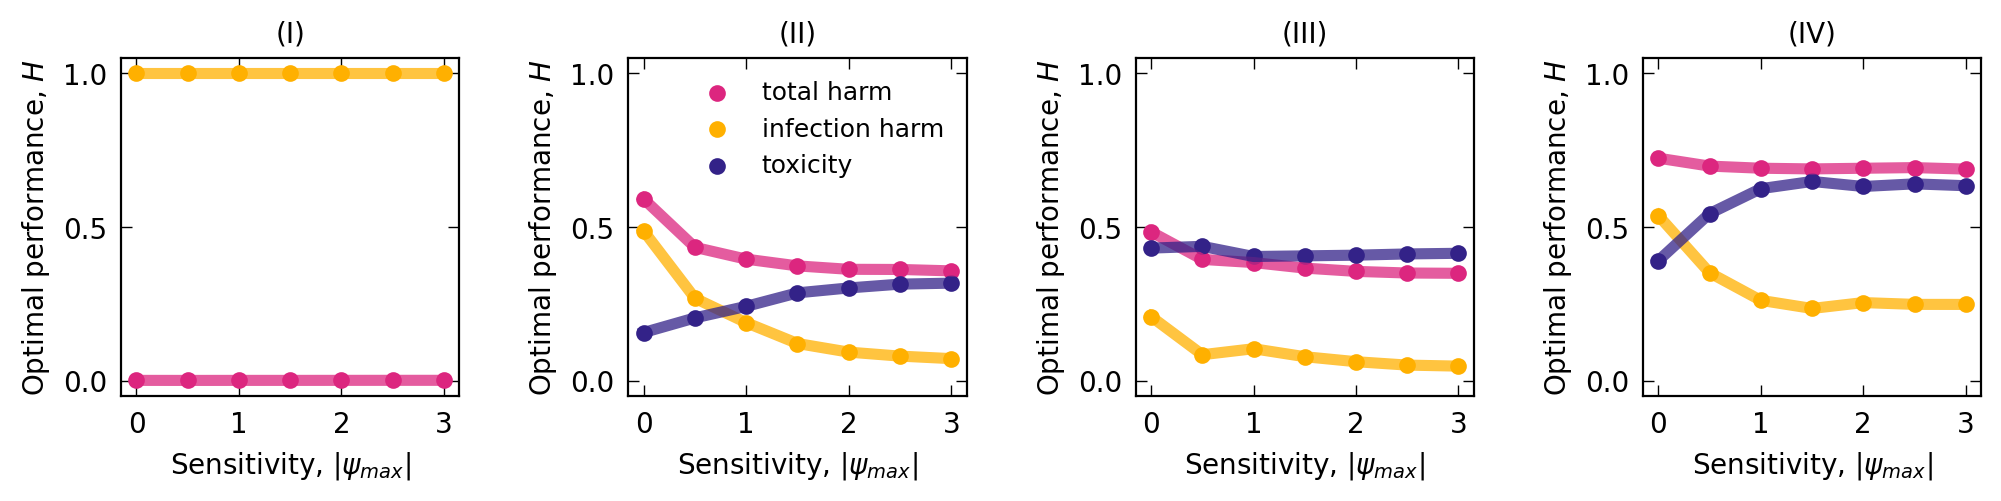

In [64]:
# Make trade-off figure
fig, axs = plt.subplots(1,n_clusters, figsize=(n_clusters*3, 3), sharex='row', sharey=False) #,layout='constrained')
perf = 0

kwargs = {'linewidth': 4.0, 'markeredgewidth': 0.25, 'markeredgecolor': 'k', 'markersize': 6, 'alpha': 0.75}
data = cluster_feedback_grid_opt.loc[(cluster_feedback_grid_opt.perf_index == perf)].groupby(['phase_cluster', 'feedback'], as_index = False).mean()

for k, (_, g) in enumerate(data.groupby(['phase_cluster'])):
    for i, perf in enumerate(perf_vars[0:3]):
        axs.flat[k].plot(g['feedback'].values,
             g[perf].values/(g['harm_pI_noprotection'].values if i > 0 else 1.0),
             color = perf_var_colors[i],
                            **kwargs)
    
        axs.flat[k].scatter(g['feedback'].values,
         g[perf].values/(g['harm_pI_noprotection'].values if i > 0 else 1.0),
         color = perf_var_colors[i], 
         label = perf_labels[i])

    axs.flat[k].set_title(phase_cluster_labels[k], fontsize = 10.0)
    
axs.flat[1].legend(fontsize=9, framealpha=0, ncol = 1)

for ax in axs.flat: 
    ax.minorticks_off()
    ax.set_box_aspect(1)
    ax.set_ylim(-0.05, 1.05)
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.locator_params(axis='y', nbins=4)
    ax.locator_params(axis='x', nbins=4)
    ax.set_ylabel(r"Optimal performance, $H$", fontsize = 10)
    ax.set_xlabel(r"Sensitivity, $|\psi_{max}|$", fontsize = 10)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

fig.subplots_adjust(wspace=.5, hspace=0.5)

plt.savefig('_figs/figSI_'+comment+'-cluster_harm-vary_sensitivity'+'.pdf', format="pdf", transparent=True, dpi=300)

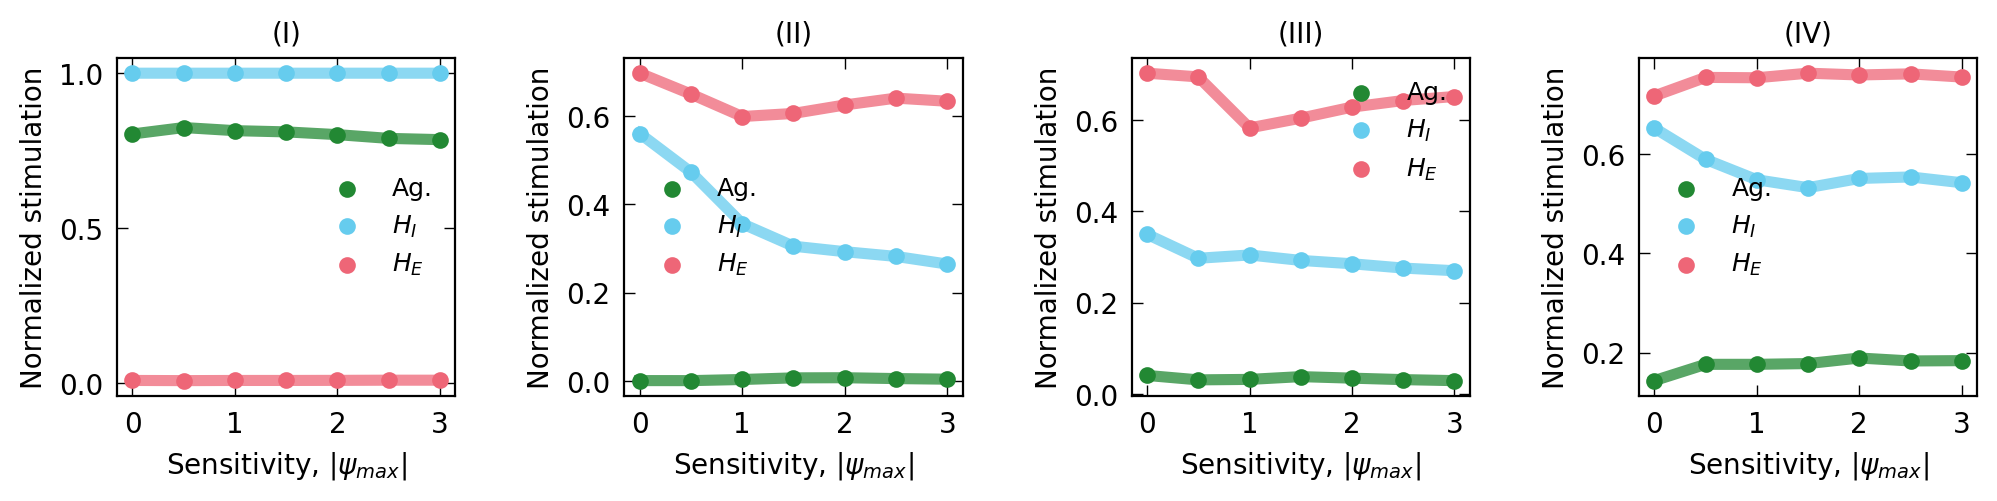

In [65]:
# Make trade-off figure
fig, axs = plt.subplots(1,n_clusters, figsize=(n_clusters*3, 3), sharex='row', sharey=False) #,layout='constrained')
perf = 0

kwargs = {'linewidth': 4.0, 'markeredgewidth': 0.25, 'markeredgecolor': 'k', 'markersize': 6, 'alpha': 0.75}
data = cluster_feedback_grid_opt.loc[(cluster_feedback_grid_opt.perf_index == perf)].groupby(['phase_cluster', 'feedback'], as_index = False).mean()

for k, (_, g) in enumerate(data.groupby(['phase_cluster'])):
    for i, stim in enumerate(stim_vars):
        normalize = np.amax(avg_cluster_data.loc[(avg_cluster_data.phase_cluster == k), stim])
        axs[k].plot(g['feedback'].values,
             g[stim].values/normalize,
             color = cmap_colors[i],
                            **kwargs)
    
        axs[k].scatter(g['feedback'].values,
         g[stim].values/normalize,
         color = cmap_colors[i], 
         label = ['Ag.', r'$H_I$', r'$H_E$'][i])

    axs[k].set_title(phase_cluster_labels[k], fontsize = 10.0)

for ax in axs.flat:
    ax.legend(fontsize=9, framealpha=0)
    ax.minorticks_off()
    ax.set_box_aspect(1)
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.locator_params(axis='y', nbins=4)
    ax.locator_params(axis='x', nbins=4)
    ax.set_ylabel("Normalized stimulation", fontsize = 10)
    ax.set_xlabel("Sensitivity, $|\psi_{max}|$", fontsize = 10)

fig.subplots_adjust(wspace=.5, hspace=0.15)

plt.savefig('_figs/'+comment+'-cluster_stim-sensitivity'+'.pdf', format="pdf", transparent=True, dpi=300)

Paradoxically, for a response to be protective, it drives down the infection feedback signals.

##### Relationship between design and performance

In [66]:
def choose_continous_color(x):
    if x == 0:
        out = plt.cm.Greys(x)
    elif x > 0:
        out = plt.cm.Blues(x)
    elif x < 0:
        out = plt.cm.Reds(np.abs(x))

    return out

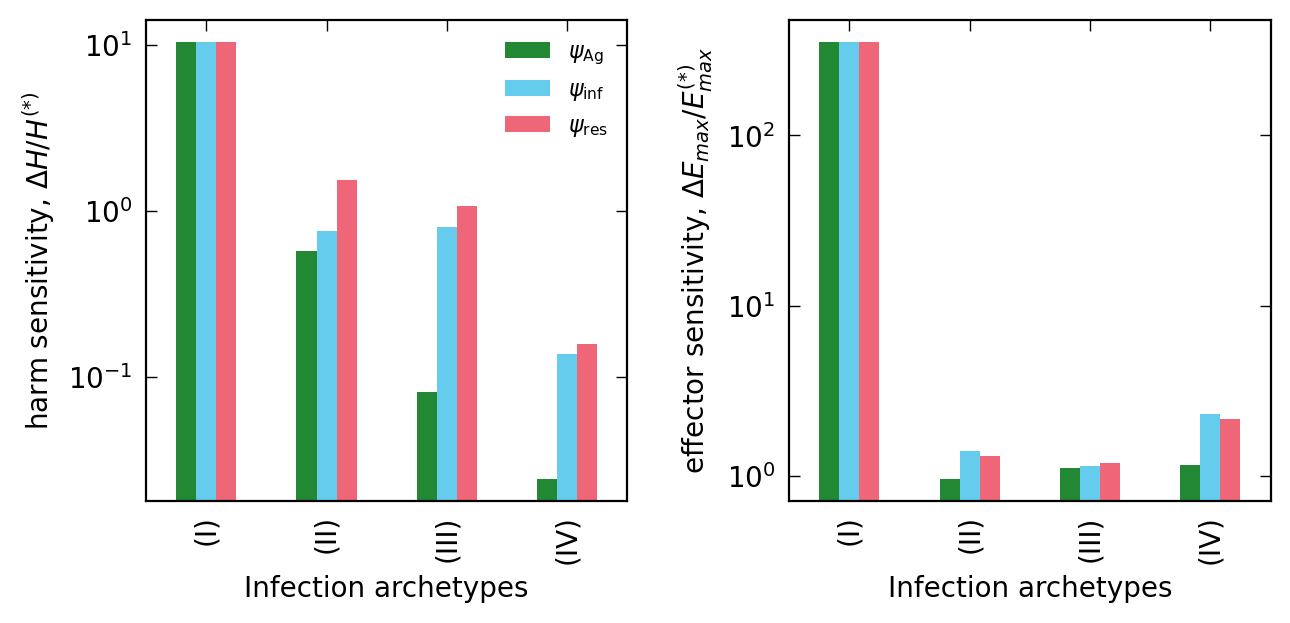

In [67]:
fig, axs = plt.subplots(1,2, figsize=(6.5, 3), sharex='row', sharey=False,layout='constrained')

# Prepare data
data = cluster_ablate_grid_opt.loc[(cluster_ablate_grid_opt.perf_index == 0)*(cluster_ablate_grid_opt.ablate_index < 3)].groupby(['phase_cluster', 'ablate_index']+opt_vars, as_index = False).mean()
opts = cluster_grid_opt.loc[cluster_grid_opt.perf_index == 0].groupby(['phase_cluster'], as_index = False).mean()

# Plot harm
range_data = data.groupby(['phase_cluster', 'ablate_index']).max() - data.groupby(['phase_cluster', 'ablate_index']).min()
groups = [(range_data.loc[i].peff_total_harm.values/opts.loc[opts.phase_cluster == i].peff_total_harm.item()).tolist() for i in phase_clusters]
group_labels = phase_cluster_labels

df = pd.DataFrame(groups, index=group_labels, columns = opt_vars_labels[0:3])

df.plot.bar(ax=axs[0], color = cmap_colors)
axs[0].set_ylabel(r"harm sensitivity, $\Delta H/H^{(*)}$", fontsize = 10)
axs[0].legend(fontsize=8)

# Plot effectors
groups = [(range_data.loc[i].max_pE.values/opts.loc[opts.phase_cluster == i].max_pE.item()).tolist() for i in phase_clusters]

df = pd.DataFrame(groups, index=group_labels, columns = opt_vars_labels[0:3])

df.plot.bar(ax=axs[1], color = cmap_colors, legend = False)
axs[1].set_ylabel(r"effector sensitivity, $\Delta E_{max}/E_{max}^{(*)}$", fontsize = 10)

for j, ax in enumerate(axs.flat):
    ax.minorticks_off()
    #ax.set_ylim(-0.05, None)
    ax.set_box_aspect(1)
    ax.semilogy()
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.minorticks_off()
    #axs.locator_params(axis='y', nbins=4)
    #ax.locator_params(axis='x', nbins=4)
    ax.set_xlabel('Infection archetypes', fontsize = 10)

# plt.savefig('_figs/figSI_'+comment+'-pareto-prot_ablate_feedback'+'.pdf', format="pdf", transparent=True, dpi=300)

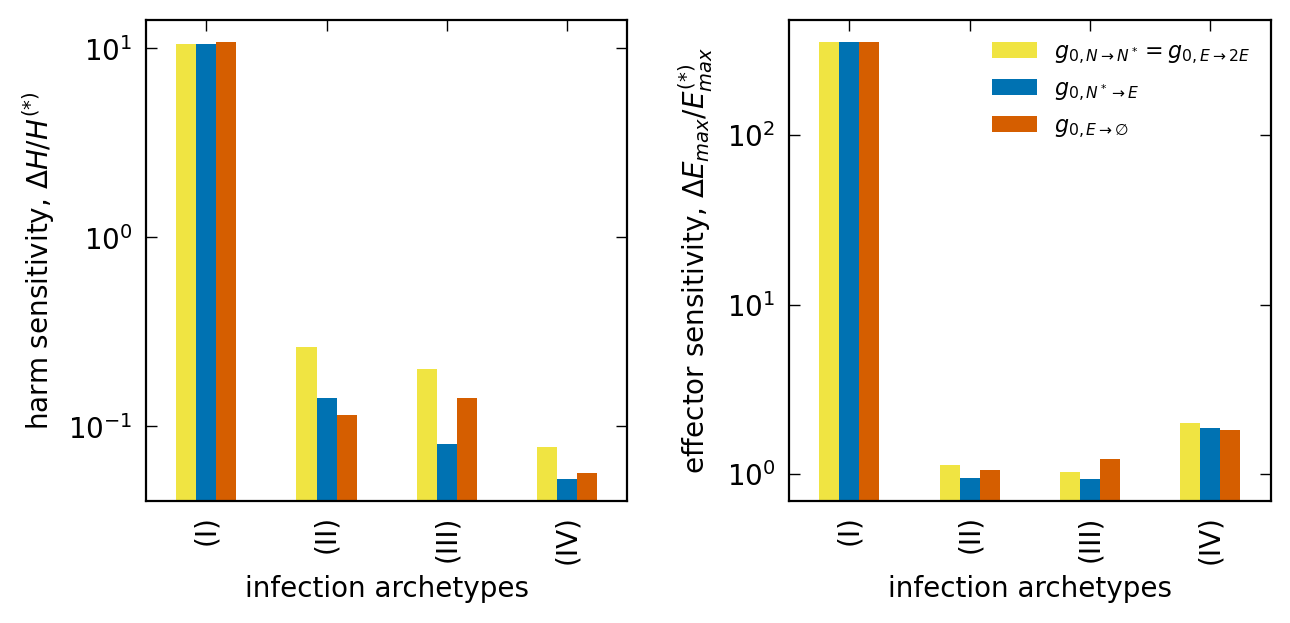

In [68]:
fig, axs = plt.subplots(1,2, figsize=(6.5, 3), sharex='row', sharey=False,layout='constrained')

# Prepare data
data = cluster_ablate_grid_opt.loc[(cluster_ablate_grid_opt.perf_index == 0)*(cluster_ablate_grid_opt.ablate_index >= 3)].groupby(['phase_cluster', 'ablate_index']+opt_vars, as_index = False).mean()
opts = cluster_grid_opt.loc[cluster_grid_opt.perf_index == 0].groupby(['phase_cluster'], as_index = False).mean()

# Plot harm
range_data = data.groupby(['phase_cluster', 'ablate_index']).max() - data.groupby(['phase_cluster', 'ablate_index']).min()
groups = [(range_data.loc[i].peff_total_harm.values/opts.loc[opts.phase_cluster == i].peff_total_harm.item()).tolist() for i in phase_clusters]
group_labels = phase_cluster_labels

df = pd.DataFrame(groups, index=group_labels, columns = opt_vars_labels[3:])

df.plot.bar(ax=axs[0], color = cmap_colors[3:], legend = False)
axs[0].set_ylabel(r"harm sensitivity, $\Delta H/H^{(*)}$", fontsize = 10)

# Plot effectors
groups = [(range_data.loc[i].max_pE.values/opts.loc[opts.phase_cluster == i].max_pE.item()).tolist() for i in phase_clusters]

df = pd.DataFrame(groups, index=group_labels, columns = opt_vars_labels[3:])

df.plot.bar(ax=axs[1], color = cmap_colors[3:])
axs[1].legend(fontsize=8)
axs[1].set_ylabel("effector sensitivity, $\Delta E_{max}/E_{max}^{(*)}$", fontsize = 10)

for j, ax in enumerate(axs.flat):
    ax.minorticks_off()
    #ax.set_ylim(-0.05, None)
    ax.set_box_aspect(1)
    ax.semilogy()
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.minorticks_off()
    #axs.locator_params(axis='y', nbins=4)
    #ax.locator_params(axis='x', nbins=4)
    ax.set_xlabel('infection archetypes', fontsize = 10)
    
# plt.savefig('_figs/figSI_'+comment+'-pareto-prot_ablate_baseline'+'.pdf', format="pdf", transparent=True, dpi=300)

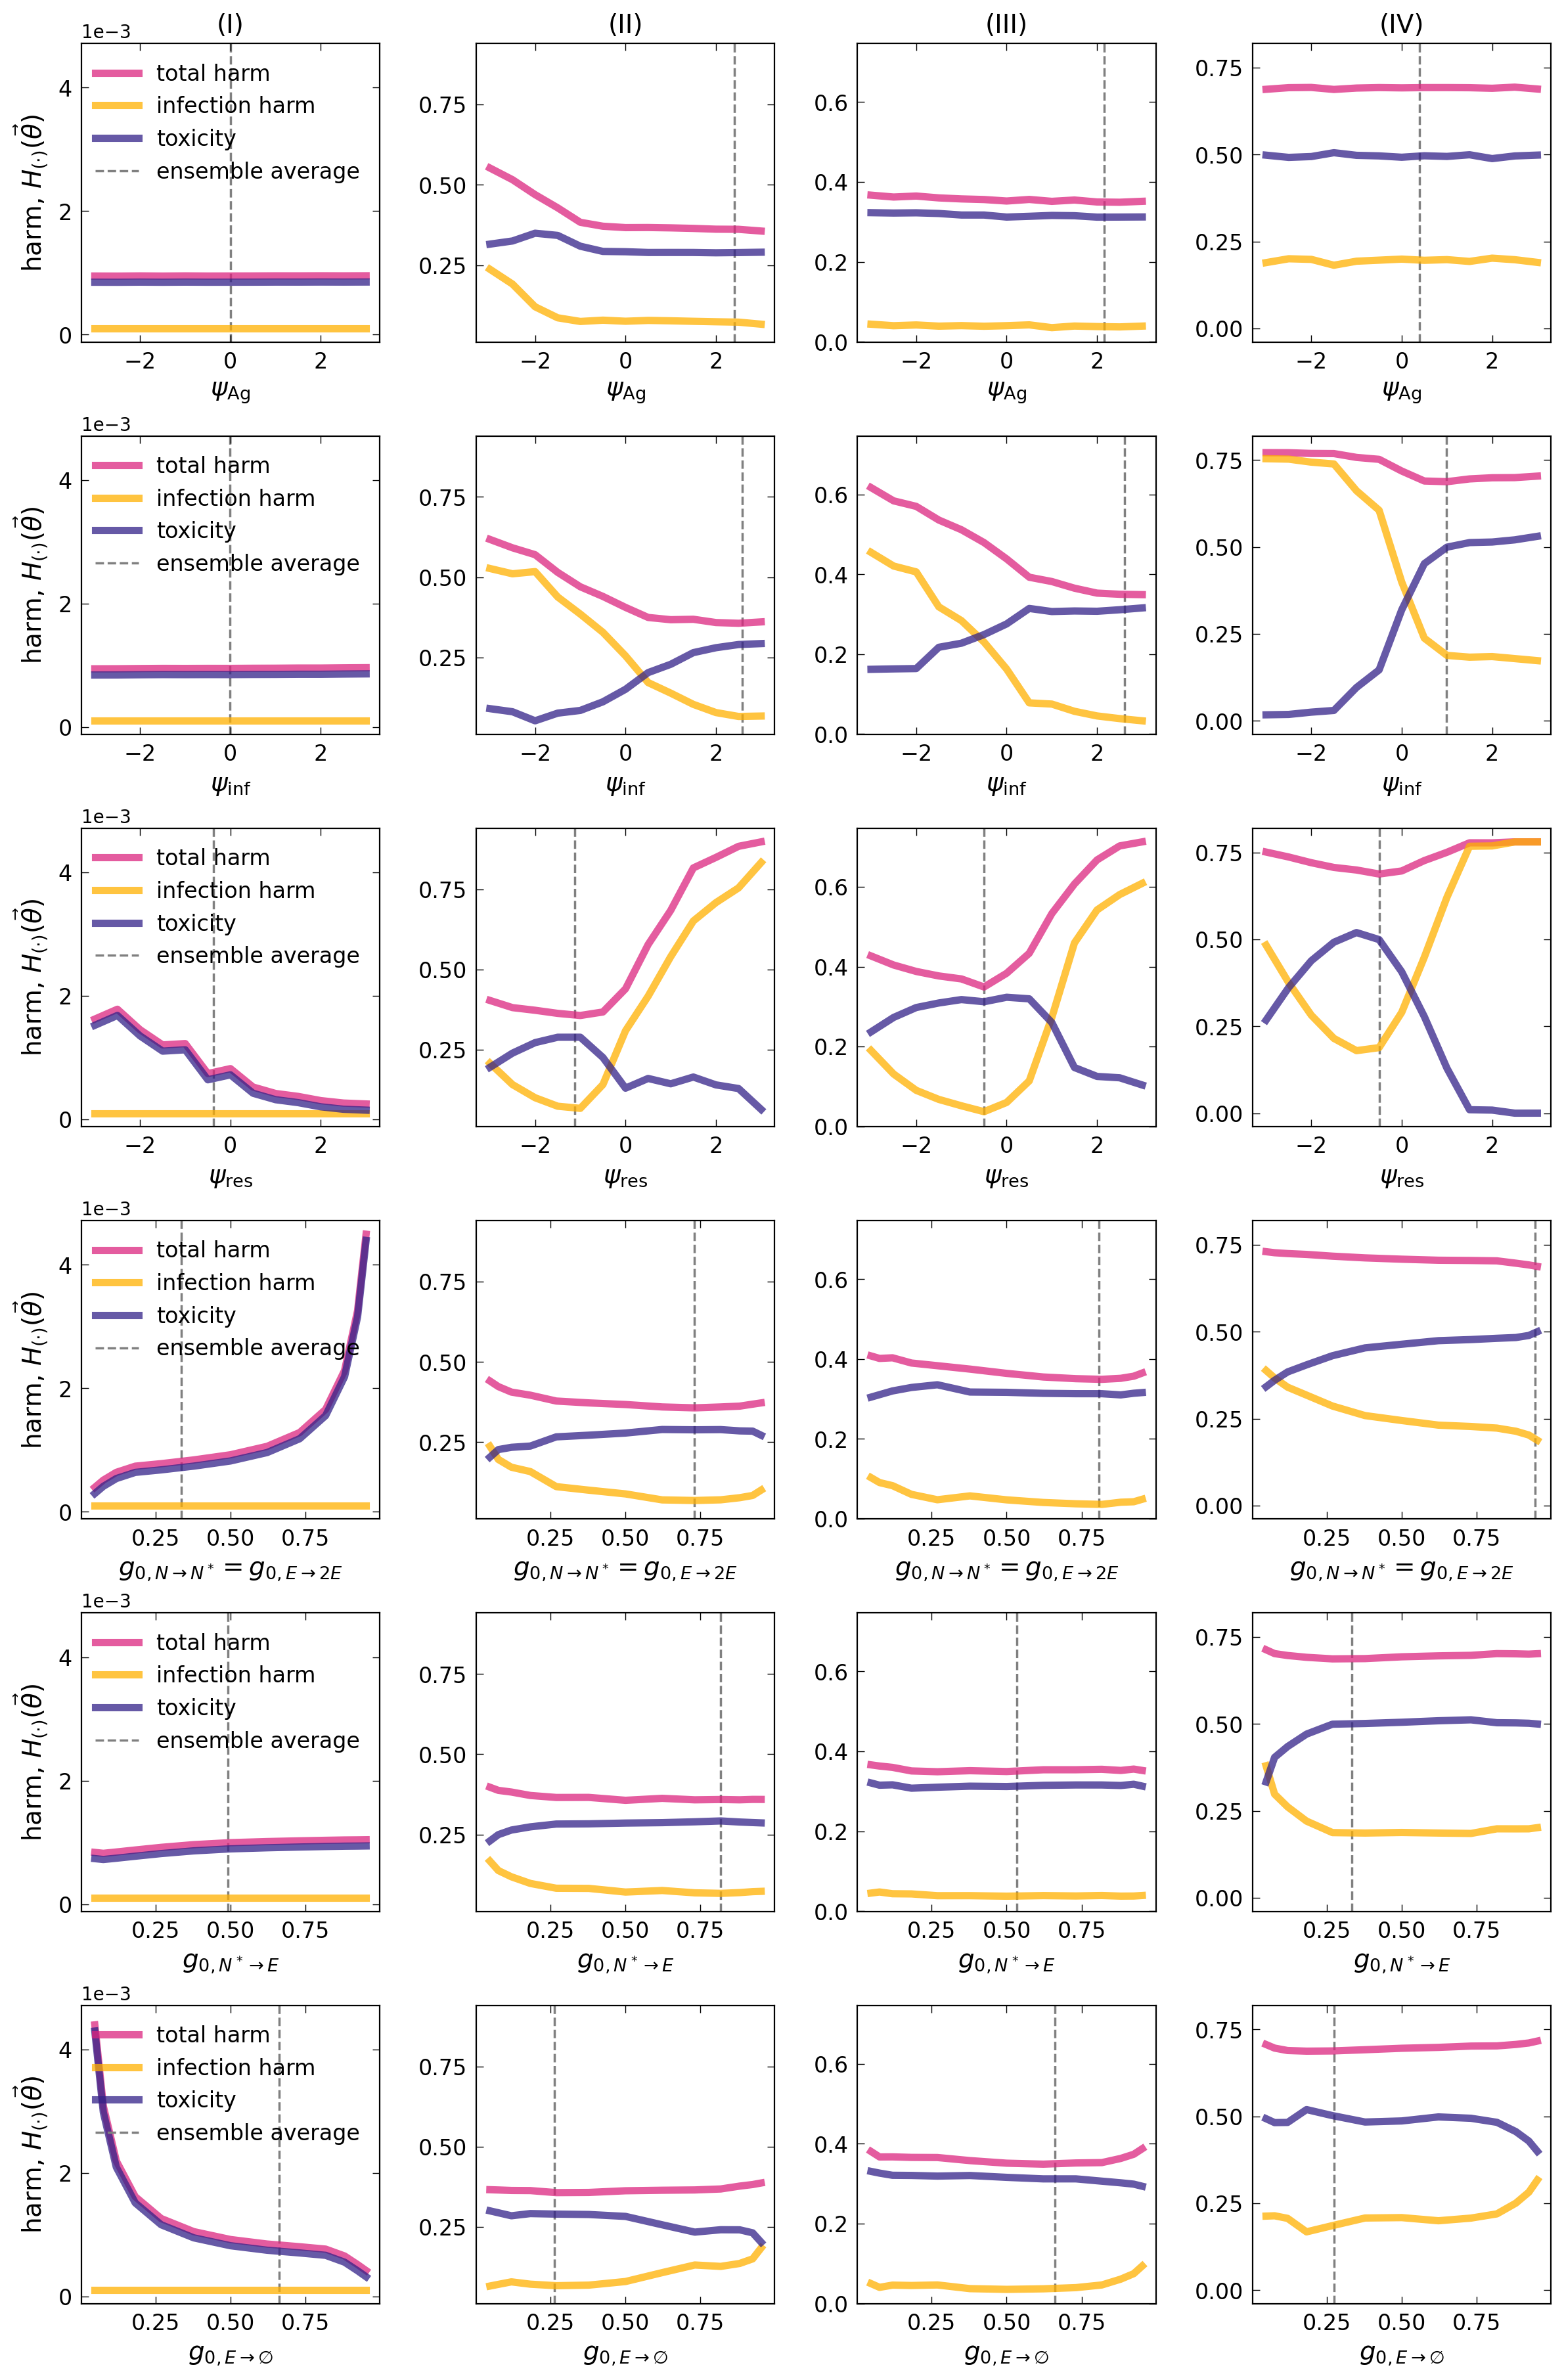

In [69]:
# Make trade-off figure
fig, axs = plt.subplots(len(opt_vars),n_clusters, figsize=(n_clusters*3, len(opt_vars)*3), sharex='row', sharey='col',layout='constrained')
perf = 0

kwargs = {'linewidth': 4.0, 'markeredgewidth': 0.25, 'markeredgecolor': 'k', 'markersize': 6, 'alpha': 0.75}
data = cluster_ablate_grid_opt.loc[(cluster_ablate_grid_opt.perf_index == perf)]
opt_reg_data = cluster_grid_opt.loc[cluster_grid_opt.perf_index == 0].groupby(['phase_cluster'], as_index = False).mean()

for k, (_, g) in enumerate(data.groupby(['phase_cluster'])):

    # (a) Effect of single parameter ablation on Infection
    for i, var in enumerate(opt_vars):
        use_data = g.groupby([var, 'ablate_index'], as_index = False).mean()
        for x, u in enumerate(perf_vars[0:3]):
            axs[i,k].plot(use_data.loc[(use_data.ablate_index == i),  [var]].values,
                 use_data.loc[(use_data.ablate_index == i), [u]].values,
                 color = perf_var_colors[x], 
                             label = perf_labels[x],
                                **kwargs)

        axs[i,k].axvline(x = opt_reg_data.loc[opt_reg_data.phase_cluster == k][var].values[0], 
                         color = 'grey', linewidth = 1.25, alpha = 1.0, linestyle = '--', zorder = 0,
                        label = 'ensemble average')
        axs[i,k].set_xlabel(opt_vars_labels[i], fontsize = 14)
        if k == 0:
            axs[i,0].legend(fontsize=12, framealpha=0, ncol = 1)

    #axs.flat[k].axvline(x = 0, color = 'black', linestyle = '--', zorder = 0)
    axs[0,k].set_title(phase_cluster_labels[k], fontsize = 14.0)

            
axs[0,0].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    
for j, ax in enumerate(axs.flat):
    ax.minorticks_off()
    ax.set_box_aspect(1)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.locator_params(axis='y', nbins=4)
    ax.locator_params(axis='x', nbins=4)
    # if k // 3 == 2:
    #     ax.set_xlabel(plot_labels[0], fontsize = 10)
    if j % n_clusters == 0:
        ax.set_ylabel(r"harm, $H_{(\cdot)}(\vec\theta)$", fontsize = 14)

#fig.subplots_adjust(wspace=.5, hspace=0.5)

plt.savefig('_figs/figSI_'+comment+'-cluster_harm-ablate_design'+'.pdf', format="pdf", transparent=True, dpi=300)

#### Effect of baseline parameters on effector trajectory

In [71]:
from optimize_nets import *

d="/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/raw"

n_steps = 9
p_default = np.array([0*psi_max, 0*psi_max, 0*psi_max, 
                      L0_max, L0_max,-L0_max, 0.0])
vary_ps = np.tile(p_default,  (n_steps*(len(p_default) - 1), 1))

for i in np.arange(len(p_default) - 1):
    vary_ps[i*n_steps:(i+1)*n_steps, i] = np.linspace(-psi_max, psi_max, n_steps) if i < 3 else np.linspace(-L0_max, L0_max, n_steps)
    vary_ps[i*n_steps:(i+1)*n_steps, -1] = i

input_regs = np.array([vary_ps[:,0], vary_ps[:,1], vary_ps[:,2], vary_ps[:,3], # Na
                       vary_ps[:,0], vary_ps[:,1], vary_ps[:,2], vary_ps[:,4], # NE
                       vary_ps[:,0], vary_ps[:,1], vary_ps[:,2], -L0_max**4 -0*vary_ps[:,4], # EM
                       vary_ps[:,0], vary_ps[:,1], vary_ps[:,2], vary_ps[:,5]]).T  # Edie

v = np.array([2.00000000e-07, 1.0e+05, d_I, 1.00000000e+04, 1.00000000e+02, 1.00000000e+03, S_max, d_IE, d_H, max_Na, max_expand])

run(batch = [-1], outdir=d, inf_sample = np.array([v]), 
    comment="sim_vary_l0s"+'-'+model, runs = 10, infection_model = 'acute_ag', default_reg = input_regs, 
    num_cpu = num_cpu, run_time = 10)

d_file = d + '/sim_batch_-1-10-acute_ag-sim_vary_l0s'+'-'+model+'.pkl'
with open(d_file, 'rb') as f:   
    data_dict = pickle.load(f)

parameters = data_dict["parameters"]
sim_summary = data_dict["summary_stats"]
# cell_series = data_dict["cell_time_series"]

var_names = np.concatenate((param_names_for_df, stat_names_for_df))
vary_l0s_data = pd.DataFrame(np.hstack((parameters, sim_summary)),
                              columns = [i for i in var_names]).merge(cluster_input[['K_I', 'b_I', 'K_H', 'N_0','I_0'] + ['phase_cluster']], how = 'left', on = ['K_I', 'b_I', 'K_H', 'N_0','I_0'])

vary_l0s_data.loc[:, 'R_0'] = S_max*vary_l0s_data['b_I']/vary_l0s_data['d_I']
vary_l0s_data.loc[:,'exp_rate'] = np.log(np.maximum(vary_l0s_data['max_pE'], max_Na)/max_Na)/np.maximum(t_cycle, vary_l0s_data['T_pE_max'] - vary_l0s_data['T_pE_start'])
vary_l0s_data.loc[:,'end_rate'] = -np.log(np.maximum(vary_l0s_data['N_0'], vary_l0s_data['E_end'])/np.maximum(vary_l0s_data['N_0'], vary_l0s_data['max_pE']))/np.maximum(t_cycle, vary_l0s_data['T_pE_end'] - vary_l0s_data['T_pE_max'])
vary_l0s_data.loc[:,'max_expE'] = vary_l0s_data['max_pE']/vary_l0s_data['N_0']
vary_l0s_data.loc[:,opt_vars[0:3]] = np.round(vary_l0s_data[['psi_NE_I', 'psi_NE_HI', 'psi_NE_HE']].values, 3)
vary_l0s_data.loc[:,opt_vars[3:]] = np.round(1/(1 + np.exp(-vary_l0s_data[reg_bl].values)), 3)
vary_l0s_data.loc[:,"harm_pI_noprotection"] = vary_l0s_data.apply(lambda row: np.mean(cluster_input.harm_pI_noprotection.values[np.argmin(np.abs(cluster_input[plots[0]] - row[plots[0]]) + np.abs(cluster_input[plots[1]] - row[plots[1]]))]), axis=1)

vary_l0s_data.loc[:,"peff_infection"] = vary_l0s_data['harm_pI']/S_max
vary_l0s_data.loc[:,"peff_toxicity"] = vary_l0s_data['harm_pS']/S_max
vary_l0s_data.loc[:,"peff_scaled_total_harm"] = (vary_l0s_data['peff_infection'] + vary_l0s_data['peff_toxicity'])/vary_l0s_data['harm_pI_noprotection']

vary_eff_dyn_design = vary_l0s_data.groupby(opt_vars, as_index = False, sort = False).mean()

# with pd.option_context('display.max_columns', None):
#     display(prot_eff_dyn_design)

Running 540 simulations in batch #-1
Saved sim_batch_-1-10-acute_ag-sim_vary_l0s-limit-E.pkl
0.007513806753688388 hrs


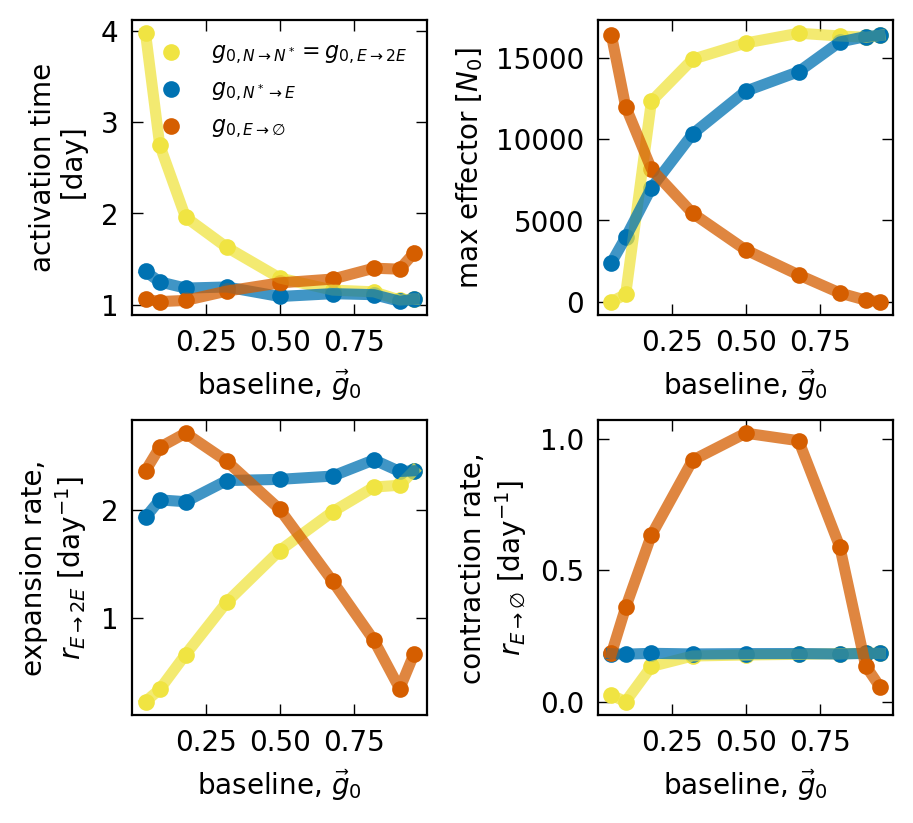

In [72]:
# Plot dependency of effector dynamics on design
eff_dyn_vars = ['T_pE_start', 'max_expE', 'exp_rate', 'end_rate']#, 'E_end', 'peff_infection'] #'exp_rate', , 'sel_ratio'
eff_dyn_labels = ['activation time\n [day]', 'max effector '+ r'[$N_0$]', 'expansion rate,\n'+r'$r_{E \to 2E}$ [$\text{day}^{-1}$]', 
                  'contraction rate,\n'+r'$r_{E \to \emptyset}$ [$\text{day}^{-1}$]'] #,'Final effector'+ r'[$N_0$]', perf_labels[1]+r' [$S_{max}$]'] # 'Expansion rate\n'+r'[$N_0\cdot \text{day}^{-1}$]', , 'Response avidity'

# Make trade-off figure
fig, axs = plt.subplots(2, 2,figsize=(4.5, 4), sharex='row', sharey=False, layout='constrained')

kwargs = {'linewidth': 4.0, 'markeredgewidth': 0.25, 'markeredgecolor': 'k', 'markersize': 6, 'alpha': 0.75}

for k, (eff_var, ax) in enumerate(zip(eff_dyn_vars, axs.flat)):

    # (a) Effect of single parameter ablation on Harm
    for i, var in enumerate(opt_vars[3:]):
        plot_data = vary_eff_dyn_design.loc[np.round(np.sum(np.abs(vary_eff_dyn_design[opt_vars[0:3] + reg_bl].values - p_default[:-1]), axis = 1),5) == np.round(np.abs(vary_eff_dyn_design[(opt_vars[0:3] + reg_bl)[3+i]].values - p_default[3+i]),5)].groupby([var], as_index = False).mean()
        
        ax.plot(np.abs(plot_data[var].values),
                plot_data[eff_var].values/(1 if k != 4 else plot_data['N_0'].values),
                color = cmap_colors[3 + i], 
                            **kwargs)

        ax.scatter(np.abs(plot_data[var].values),
                   plot_data[eff_var].values/(1 if k != 4 else plot_data['N_0'].values),
                   label = opt_vars_labels[3 + i], # (r"$-$" if i == 2 else '')+
                   color = cmap_colors[3 + i])
        
    if k == 0:
        ax.legend(fontsize=8, framealpha=0, ncol = 1) # bbox_to_anchor=(1.0, 1), 
    
    ax.set_box_aspect(1)
    ax.tick_params(axis='both', which='major', labelsize=10)
    
    ax.locator_params(axis='x', nbins=4)
    if 'Max' not in eff_dyn_labels[k]:
        ax.locator_params(axis='y', nbins=4)
    else:
        ax.semilogy()

    ax.minorticks_off()
    #ax.set_ylim(0, None)
    ax.set_ylabel(eff_dyn_labels[k], fontsize = 10)
    ax.set_xlabel(r"baseline, $\vec g_0$", fontsize = 10)
    
#fig.subplots_adjust(wspace=.5, hspace=0.5)

plt.savefig('_figs/figSI_'+comment+'-vary-design-eff-dynamics'+'.pdf', format="pdf", transparent=True, dpi=300)

### (d) Compare with experimental data

In [80]:
repeat = 1
sample = np.array(np.meshgrid(np.unique(grid_opt.b_I), # vary b_I
                                   np.unique(grid_opt.K_I), # vary K_I
                                   np.unique(grid_opt.d_I), # vary d_I
                                   np.unique(grid_opt.K_H), # vary K_H
                                   N_0*np.logspace(-2.0, 2.0, 5), # vary N_0
                                   np.unique(grid_opt.I_0), # vary I_0
                                   np.array([S_max]), # vary K_S
                                        np.array([d_IE]), # vary d_IE
                                        np.array([d_H]), # vary d_H
                                        np.array([max_Na]), # vary max_Na
                                        np.array([max_expand]) # vary max_expand
                                           )).T.reshape(-1,11)

infection_count = len(select_cluster_data)
n_steps = 3
ensemble_size = len(ensemble_pareto_reg)
#ps = np.tile(np.array(avg_pareto_reg.tolist() + [0.0]),  (n_steps*(len(avg_pareto_reg)), 1))
ps = np.tile(ensemble_pareto_reg,  
        (n_steps*(len(avg_pareto_reg)), 1))
scale_factors = np.array([0.0, 0.1, 1.0]) # np.logspace(-2.0, 0.0, n_steps)

for i in np.arange(len(avg_pareto_reg)):
    ps[i*n_steps*ensemble_size:(i+1)*n_steps*ensemble_size, i] = ps[i*n_steps*ensemble_size:(i+1)*n_steps*ensemble_size, i]*np.repeat(scale_factors,ensemble_size)

psis = np.array([ps[:,0], ps[:,1], ps[:,2], ps[:,3], # Na
                 ps[:,0], ps[:,1], ps[:,2], ps[:,4], # NE
                 -0*ps[:,0], -0*ps[:,1], -0*ps[:,2], -L0_max**4 -0*ps[:,4], # EM
                 -ps[:,0], -ps[:,1], -ps[:,2], ps[:,5]]).T  # Edie

# run simulations for extreme scenarios
run(batch = [-1], outdir=d, inf_sample = sample, 
    comment="pareto-ablation"+'-'+model, runs = repeat, infection_model = 'acute', 
    default_reg = psis,
    num_cpu = num_cpu)

d_file = d + '/sim_batch_-1-1-acute-pareto-ablation'+'-'+model+'.pkl'
with open(d_file, 'rb') as f:   
    data_dict = pickle.load(f)

parameters = data_dict["parameters"]
sim_summary = data_dict["summary_stats"]
# cell_series = data_dict["cell_time_series"]

var_names = np.concatenate((param_names_for_df, stat_names_for_df))
perturbation_data = pd.DataFrame(np.hstack((parameters, sim_summary)), columns = [i for i in var_names])
perturbation_data.loc[:, 'R_0'] = S_max*perturbation_data['b_I']/perturbation_data['d_I']
perturbation_data.loc[:, 'N_0'] = perturbation_data['N_0']
perturbation_data.loc[:, 'kappa'] = S_max/perturbation_data['K_I']
perturbation_data.loc[:, opt_vars[0:3]] = perturbation_data[['psi_NE_I', 'psi_NE_HI', 'psi_NE_HE']].values
perturbation_data.loc[:, opt_vars[3:]] = 1/(1 + np.exp(-perturbation_data[reg_bl].values))
perturbation_data.loc[:,"peff_total_harm"] = (perturbation_data['harm_pI'] + perturbation_data['harm_pS'])/S_max
perturbation_data.loc[:,"peff_expE"] = perturbation_data[perf_vars[3]]/perturbation_data['N_0']
perturbation_data.loc[:,"ensemble_index"] = np.array(perturbation_data.index.tolist()) % ensemble_size
perturbation_data.loc[:,"ablate_index"] = (np.array(perturbation_data.index.tolist()) // ensemble_size)% n_steps
perturbation_data.loc[:,"opt_var_index"] = (np.array(perturbation_data.index.tolist()) // (ensemble_size*n_steps)) % len(opt_vars)

Running 65610 simulations in batch #-1
Saved sim_batch_-1-1-acute-pareto-ablation-limit-E.pkl
0.8120743068059285 hrs


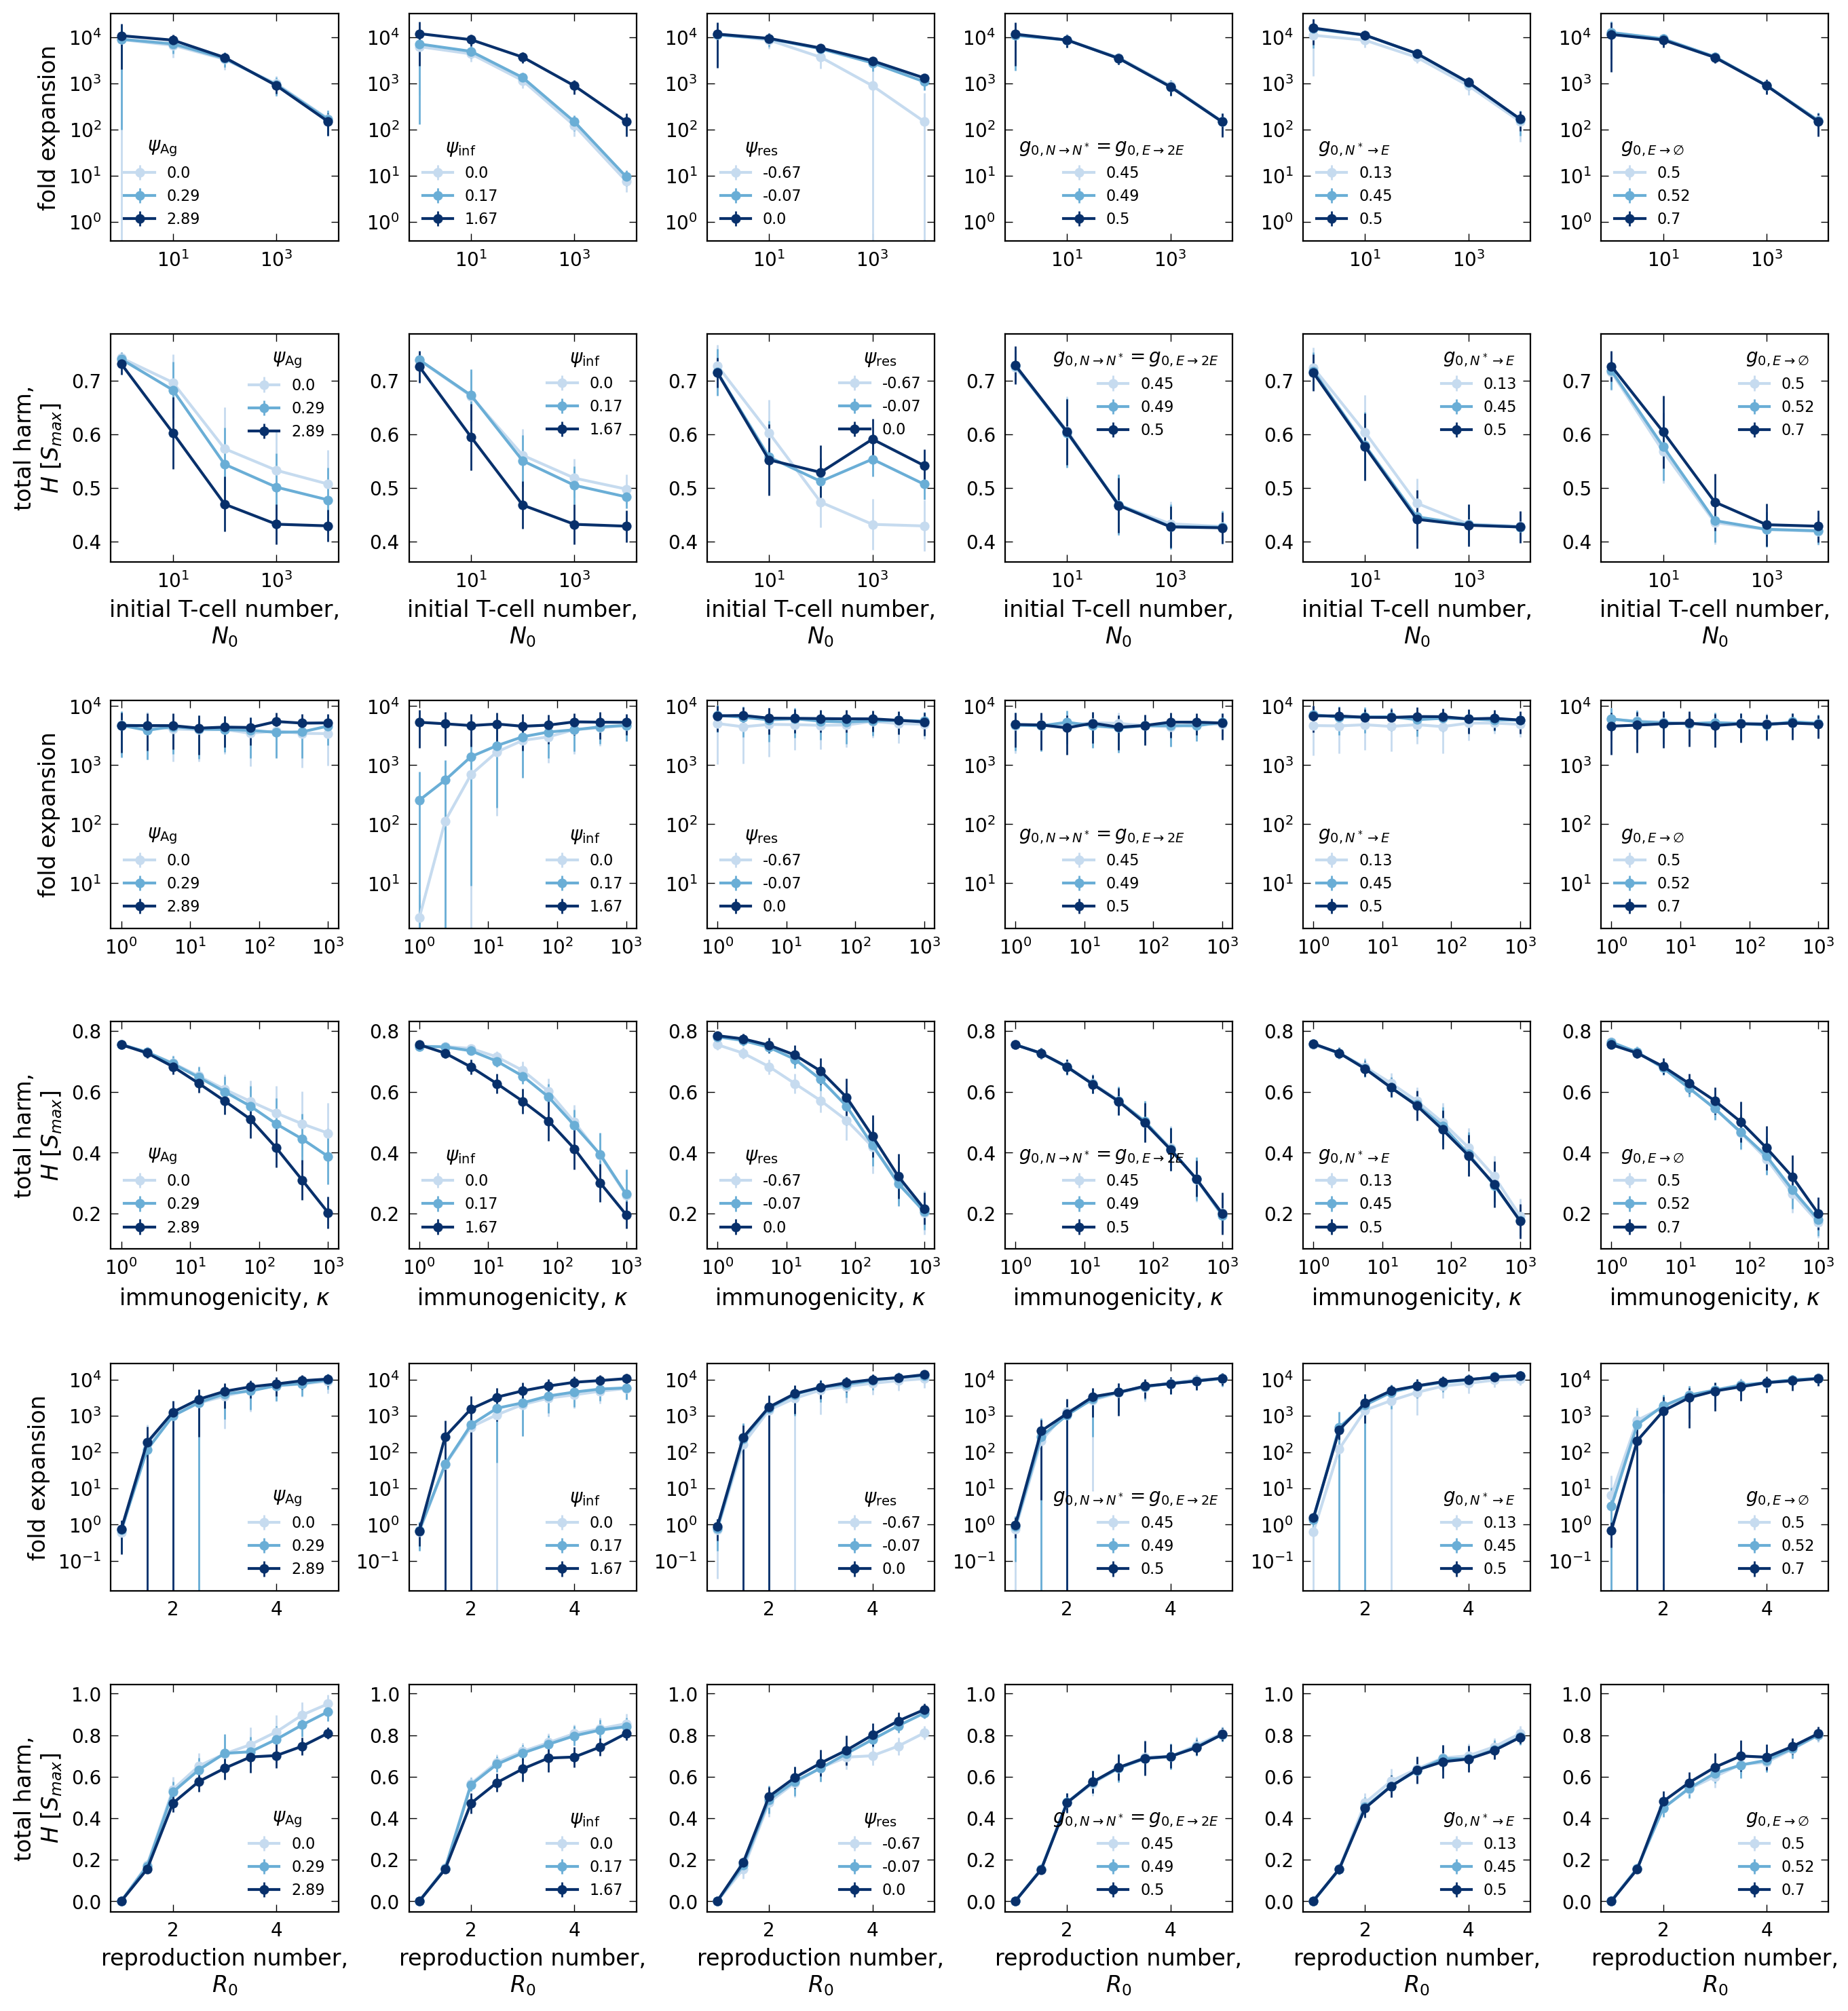

In [81]:
# Make trade-off figure
chosen_perf = ['peff_expE', 'peff_total_harm']
chosen_plots = ['N_0','kappa','R_0']
fig, axs = plt.subplots(len(chosen_plots)*len(chosen_perf),len(opt_vars), 
                        figsize=(len(chosen_plots)*len(chosen_perf)*2.25, len(opt_vars)*2.5), 
                        sharex='row', sharey='row',layout='constrained')
perf = 0

kwargs = {'linewidth': 4.0, 'markeredgewidth': 0.25, 'markeredgecolor': 'k', 'markersize': 6, 'alpha': 0.75}

for k, theta in enumerate(opt_vars):
    # data = perturbation_data.loc[np.sum(np.abs(perturbation_data[opt_vars[0:3] + reg_bl].values - avg_pareto_reg), axis = 1) == np.abs(perturbation_data[(opt_vars[0:3] + reg_bl)[k]].values - avg_pareto_reg[k])].groupby(chosen_plots + [theta], as_index = False).mean()
    data = perturbation_data.loc[perturbation_data.opt_var_index == k].groupby(chosen_plots + ['ablate_index'], as_index = False).mean()
    std_data = perturbation_data.loc[perturbation_data.opt_var_index == k].groupby(chosen_plots + ['ablate_index'], as_index = False).std()
    sm = cm.ScalarMappable(norm = mcolors.Normalize(vmin=0.0, vmax=1.0), 
                           cmap=mpl.colormaps.get_cmap('Blues'))
    # (a) Effect of single parameter ablation on Infection
    for i, v in enumerate(chosen_plots):
        use_data = data.groupby([v, theta], as_index = False).mean()
        use_std_data = std_data.groupby([v, 'ablate_index'], as_index = False).mean()
        color_arr = [choose_continous_color(x) for x in use_data[theta].values]
        for l, perf in enumerate(chosen_perf):

            for x, a in enumerate(np.unique(use_data[theta].values)):
                color = sm.to_rgba([1/4, 1/2, 1.0][x])
                
                axs[i*len(chosen_perf) + l, k].errorbar(use_data.loc[use_data[theta] == a][v], 
                                                        use_data.loc[use_data[theta] == a][perf], 
                                                        yerr = use_std_data.loc[use_data[theta] == a][perf].values,
                                                        elinewidth = 1.0,
                                                        linewidth = 1.5,
                                                        label = str(np.round(a,2)),
                                                        fmt = '-o',
                                                        color = color,
                                                        ecolor = color)
            
            if l == 0:
                axs[i*len(chosen_perf) + l, k].semilogy()

            if i in [0, 1]:
                axs[i*len(chosen_perf) + l, k].semilogx()

            axs[i*len(chosen_perf) + l, k].legend(fontsize = 8, title = opt_vars_labels[k])

            if (i*len(chosen_perf) + l) % 2 == 1:
                axs[i*len(chosen_perf) + l, k].set_xlabel(['initial T-cell number,\n'+r'$N_0$', r'immunogenicity, $\kappa$', 'reproduction number,\n'+ r'$R_0$'][i], fontsize = 12)
            if k == 0:
                axs[i*len(chosen_perf) + l, k].set_ylabel(['fold expansion','total harm,\n'+r'$H$ [$S_{max}$]'][l], fontsize = 12)
    
for j, ax in enumerate(axs.flat):
    ax.minorticks_off()
    ax.set_box_aspect(1)
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

plt.savefig('_figs/figSI_'+comment+'-perf_perturb_design'+'.pdf', format="pdf", transparent=True, dpi=300)

/tmp/ipykernel_91663/998810077.py:20: RuntimeWarning: invalid value encountered in divide
  badovinac_data['OT-1 CD8+ T cells (per spleen)'].values/badovinac_data['Input number of OT-1'].values,


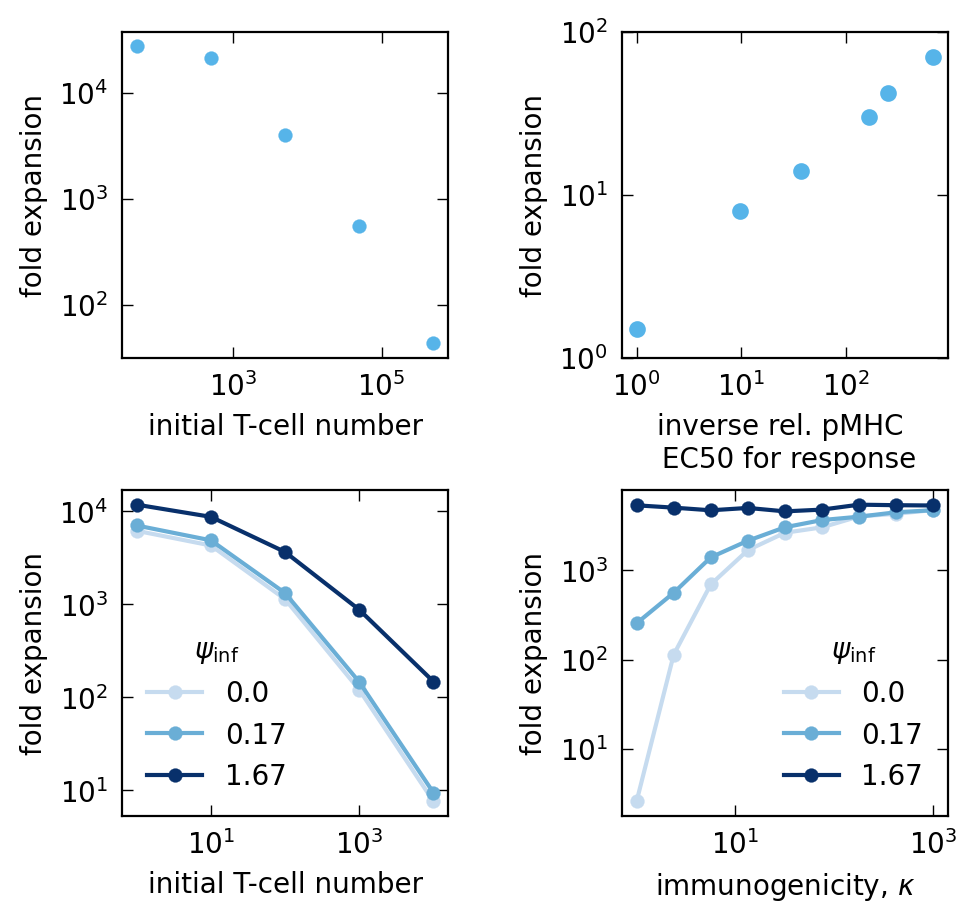

In [82]:
# Import experimental data sets on T cell expansion
badovinac_data = pd.read_csv('./external_data/badovinac.csv')
zehn_timecourse_data = pd.read_csv('./external_data/zehn-timecourse.csv')
day6_zehn_data = pd.read_csv('./external_data/zehn.csv')

# Build zehn dataset
day4_zehn_data = zehn_timecourse_data.loc[zehn_timecourse_data.day == 4].merge(day6_zehn_data[['strain','ec50','percentage']],
                                                                               how = 'left', left_on = 'peptide', right_on = 'strain',suffixes = (None, 'day_6'))
full_zehn_data = zehn_timecourse_data.loc[zehn_timecourse_data.groupby('peptide')['percentage'].idxmax()].merge(day4_zehn_data[['peptide','percentage', 'ec50']],
                                                                                        how = 'left', on = 'peptide', suffixes = ('_day7', '_day4'))
full_zehn_data.loc[:,'expansion'] = full_zehn_data.percentage_day7/full_zehn_data.percentage_day4

# Plot figures
chosen_perf = ['peff_expE']
chosen_plots = ['N_0','kappa']

fig, axs = plt.subplots(2, 2, figsize=(5.0, 4.5), sharex = False, constrained_layout=True)

axs[0,0].errorbar(badovinac_data['Input number of OT-1'].values,
                badovinac_data['OT-1 CD8+ T cells (per spleen)'].values/badovinac_data['Input number of OT-1'].values,
                fmt='o', elinewidth = 1,
                ecolor='black', capsize=3,zorder = 0)

axs[0,0].set_ylabel('fold expansion', fontsize = 10)
axs[0,0].set_xlabel('initial T-cell number', fontsize = 10)

axs[0,1].scatter(np.max(full_zehn_data.ec50)/full_zehn_data.ec50,
               full_zehn_data.expansion,
               marker = 'o')

axs[0,1].set_ylim(1, 100)
axs[0,1].set_ylabel('fold expansion', fontsize = 10)
axs[0,1].set_xlabel('inverse rel. pMHC \n EC50 for response', fontsize = 10)

kwargs = {'linewidth': 4.0, 'markeredgewidth': 0.25, 'markeredgecolor': 'k', 'markersize': 6, 'alpha': 0.75}

theta = opt_vars[1]
data = perturbation_data.loc[perturbation_data.opt_var_index == 1].groupby(chosen_plots + ['ablate_index'], as_index = False).mean()
std_data = perturbation_data.loc[perturbation_data.opt_var_index == 1].groupby(chosen_plots + ['ablate_index'], as_index = False).std()
sm = cm.ScalarMappable(norm = mcolors.Normalize(vmin=0.0, vmax=1.0), 
                       cmap=mpl.colormaps.get_cmap('Blues' if np.amax(data[theta]) > 0 else 'Reds_r'))
# (a) Effect of single parameter ablation on Infection
for i, v in enumerate(chosen_plots):
    use_data = data.groupby([v, theta], as_index = False).mean()
    use_std_data = std_data.groupby([v, 'ablate_index'], as_index = False).mean()
    color_arr = [choose_continous_color(x) for x in use_data[theta].values]
    for l, perf in enumerate(chosen_perf):

        for x, a in enumerate(np.unique(use_data[theta].values)):
            color = sm.to_rgba([1/4, 1/2, 1.0][x])

            axs[1, i].errorbar(use_data.loc[use_data[theta] == a][v], 
                                                    use_data.loc[use_data[theta] == a][perf], 
                                                    #yerr = use_std_data.loc[use_data[theta] == a][perf].values,
                                                    elinewidth = 1.0,
                                                    linewidth = 1.5,
                                                    fmt = '-o',
                               label = str(np.round(a,2)),
                                                    color = color,
                                                    ecolor = color)
            

        # cb = fig.colorbar(sm, ax=axs[1, i], location='right', shrink = 0.7, pad = 0.025)
        # cb.set_label(opt_vars_labels[1], fontsize = 9)
        # cb.ax.tick_params(labelsize=6)

        axs[1, i].legend(fontsize = 10, title = opt_vars_labels[1])
        axs[1, i].set_xlabel(['initial T-cell number', r'immunogenicity, $\kappa$'][i], fontsize = 10)
        axs[1, i].set_ylabel('fold expansion', fontsize = 10)

for j, ax in enumerate(axs.flat):
    ax.semilogx()
    ax.semilogy()
    ax.set_box_aspect(1)
    ax.minorticks_off()
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.xaxis.set_tick_params(labeltop=False)

plt.savefig('_figs/fig5_'+comment+'-perf_perturb_design'+'.pdf', format="pdf", transparent=True, dpi=300)

#### Tune design for consistency with experimental data

In [83]:
modified_ensemble_elbow_reg = ensemble_pareto_reg.copy()
modified_ensemble_elbow_reg[:,1] = scale_factors[1]*modified_ensemble_elbow_reg[:,1]
print(np.mean(modified_ensemble_elbow_reg, axis = 0))

[ 2.88888889  0.16666667 -0.66666667 -0.22222222 -1.94444444  0.94444444]


In [84]:
modified_ensemble_elbow_reg

array([[ 3.  ,  0.2 , -1.  , -0.5 , -3.  ,  0.  ],
       [ 3.  ,  0.1 , -0.5 , -1.  , -2.  ,  0.  ],
       [ 3.  ,  0.15, -0.5 ,  0.  , -1.5 ,  1.5 ],
       [ 3.  ,  0.15, -0.5 ,  0.5 , -1.5 ,  2.5 ],
       [ 3.  ,  0.1 , -0.5 , -0.5 , -2.  ,  0.5 ],
       [ 2.5 ,  0.1 , -0.5 ,  0.  , -2.  ,  1.  ],
       [ 3.  ,  0.3 , -1.  , -0.5 , -1.5 ,  1.  ],
       [ 2.5 ,  0.3 , -1.  ,  0.  , -2.  ,  1.  ],
       [ 3.  ,  0.1 , -0.5 ,  0.  , -2.  ,  1.  ]])

#### Parameter sensitivity analysis

In [85]:
from optimize_nets import *
num_pnts = 4
runs = 1

# build sample
default_sample =  sample = np.array(np.meshgrid(np.unique(grid_opt.b_I), # vary b_I
                                   np.unique(grid_opt.K_I), # vary K_I
                                   np.unique(grid_opt.d_I), # vary d_I
                                   np.unique(grid_opt.K_H), # vary K_H
                                   np.unique(grid_opt.N_0), # vary N_0
                                   np.unique(grid_opt.I_0), # vary I_0
                                   np.array([S_max]), # vary K_S
                                        np.array([d_IE]), # vary d_IE
                                        np.array([d_H]), # vary d_H
                                        np.array([max_Na]), # vary max_Na
                                        np.array([max_expand]) # vary max_expand
                                           )).T.reshape(-1,11) #np.unique(crit_reg_data[full_vars].values, axis = 0)
scale_parameters = np.logspace(-1.0, 1.0, num_pnts)

sample_list = []
for j, var in enumerate(full_vars[2:]):
    for s in scale_parameters:
        scale_by = np.ones(default_sample.shape)
        scale_by[:, 2+ j] = scale_by[:, 2+ j]*s

        out = default_sample*scale_by
        sample_list.append(out)

full_sample = np.vstack(sample_list)

d="/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/raw"

ps = np.array([modified_ensemble_elbow_reg[:,0], modified_ensemble_elbow_reg[:,1], modified_ensemble_elbow_reg[:,2], modified_ensemble_elbow_reg[:,3], # Na
          modified_ensemble_elbow_reg[:,0], modified_ensemble_elbow_reg[:,1], modified_ensemble_elbow_reg[:,2], modified_ensemble_elbow_reg[:,4], # NE
          -0*modified_ensemble_elbow_reg[:,0], -0*modified_ensemble_elbow_reg[:,1], -0*modified_ensemble_elbow_reg[:,2], -L0_max**4 -0*modified_ensemble_elbow_reg[:,4], # EM
          -modified_ensemble_elbow_reg[:,0], -modified_ensemble_elbow_reg[:,1], -modified_ensemble_elbow_reg[:,2], modified_ensemble_elbow_reg[:,5]]).T  # Edie

# run simulations for extreme scenarios
run(batch = [-1], outdir=d, inf_sample = full_sample, 
    comment="parameter_sens_sim"+'-'+model, runs = runs, infection_model = 'acute', 
    default_reg = ps,
    num_cpu = num_cpu)

Running 26244 simulations in batch #-1
Saved sim_batch_-1-1-acute-parameter_sens_sim-limit-E.pkl
0.11020443697770436 hrs


In [49]:
d_file = d + '/sim_batch_-1-1-acute-parameter_sens_sim'+'-'+model+'.pkl'
with open(d_file, 'rb') as f:   
    data_dict = pickle.load(f)

parameters = data_dict["parameters"]
sim_summary = data_dict["summary_stats"]
var_names = np.concatenate((param_names_for_df, stat_names_for_df))
parameter_sens_df = pd.DataFrame(np.hstack((parameters, sim_summary)), columns = [i for i in var_names]).groupby(full_vars, as_index=False).mean()

# compute infection harm without T cell response
parameter_sens_df.loc[:,opt_vars[0:3]] = parameter_sens_df[['psi_NE_I', 'psi_NE_HI', 'psi_NE_HE']].values
parameter_sens_df.loc[:,'R_0'] = S_max*parameter_sens_df['b_I']/parameter_sens_df['d_I']
parameter_sens_df.loc[:,'kappa'] = S_max/parameter_sens_df['K_I']
parameter_sens_df.loc[:,"peff_infection"] = parameter_sens_df['harm_pI'].to_numpy()/S_max
parameter_sens_df.loc[:,"peff_toxicity"] = parameter_sens_df['harm_pS'].to_numpy()/S_max
parameter_sens_df.loc[:,"peff_total_harm"] = parameter_sens_df['peff_infection'] + parameter_sens_df['peff_toxicity']
parameter_sens_df.loc[:,'max_expE'] = parameter_sens_df['max_pE']/parameter_sens_df['N_0']

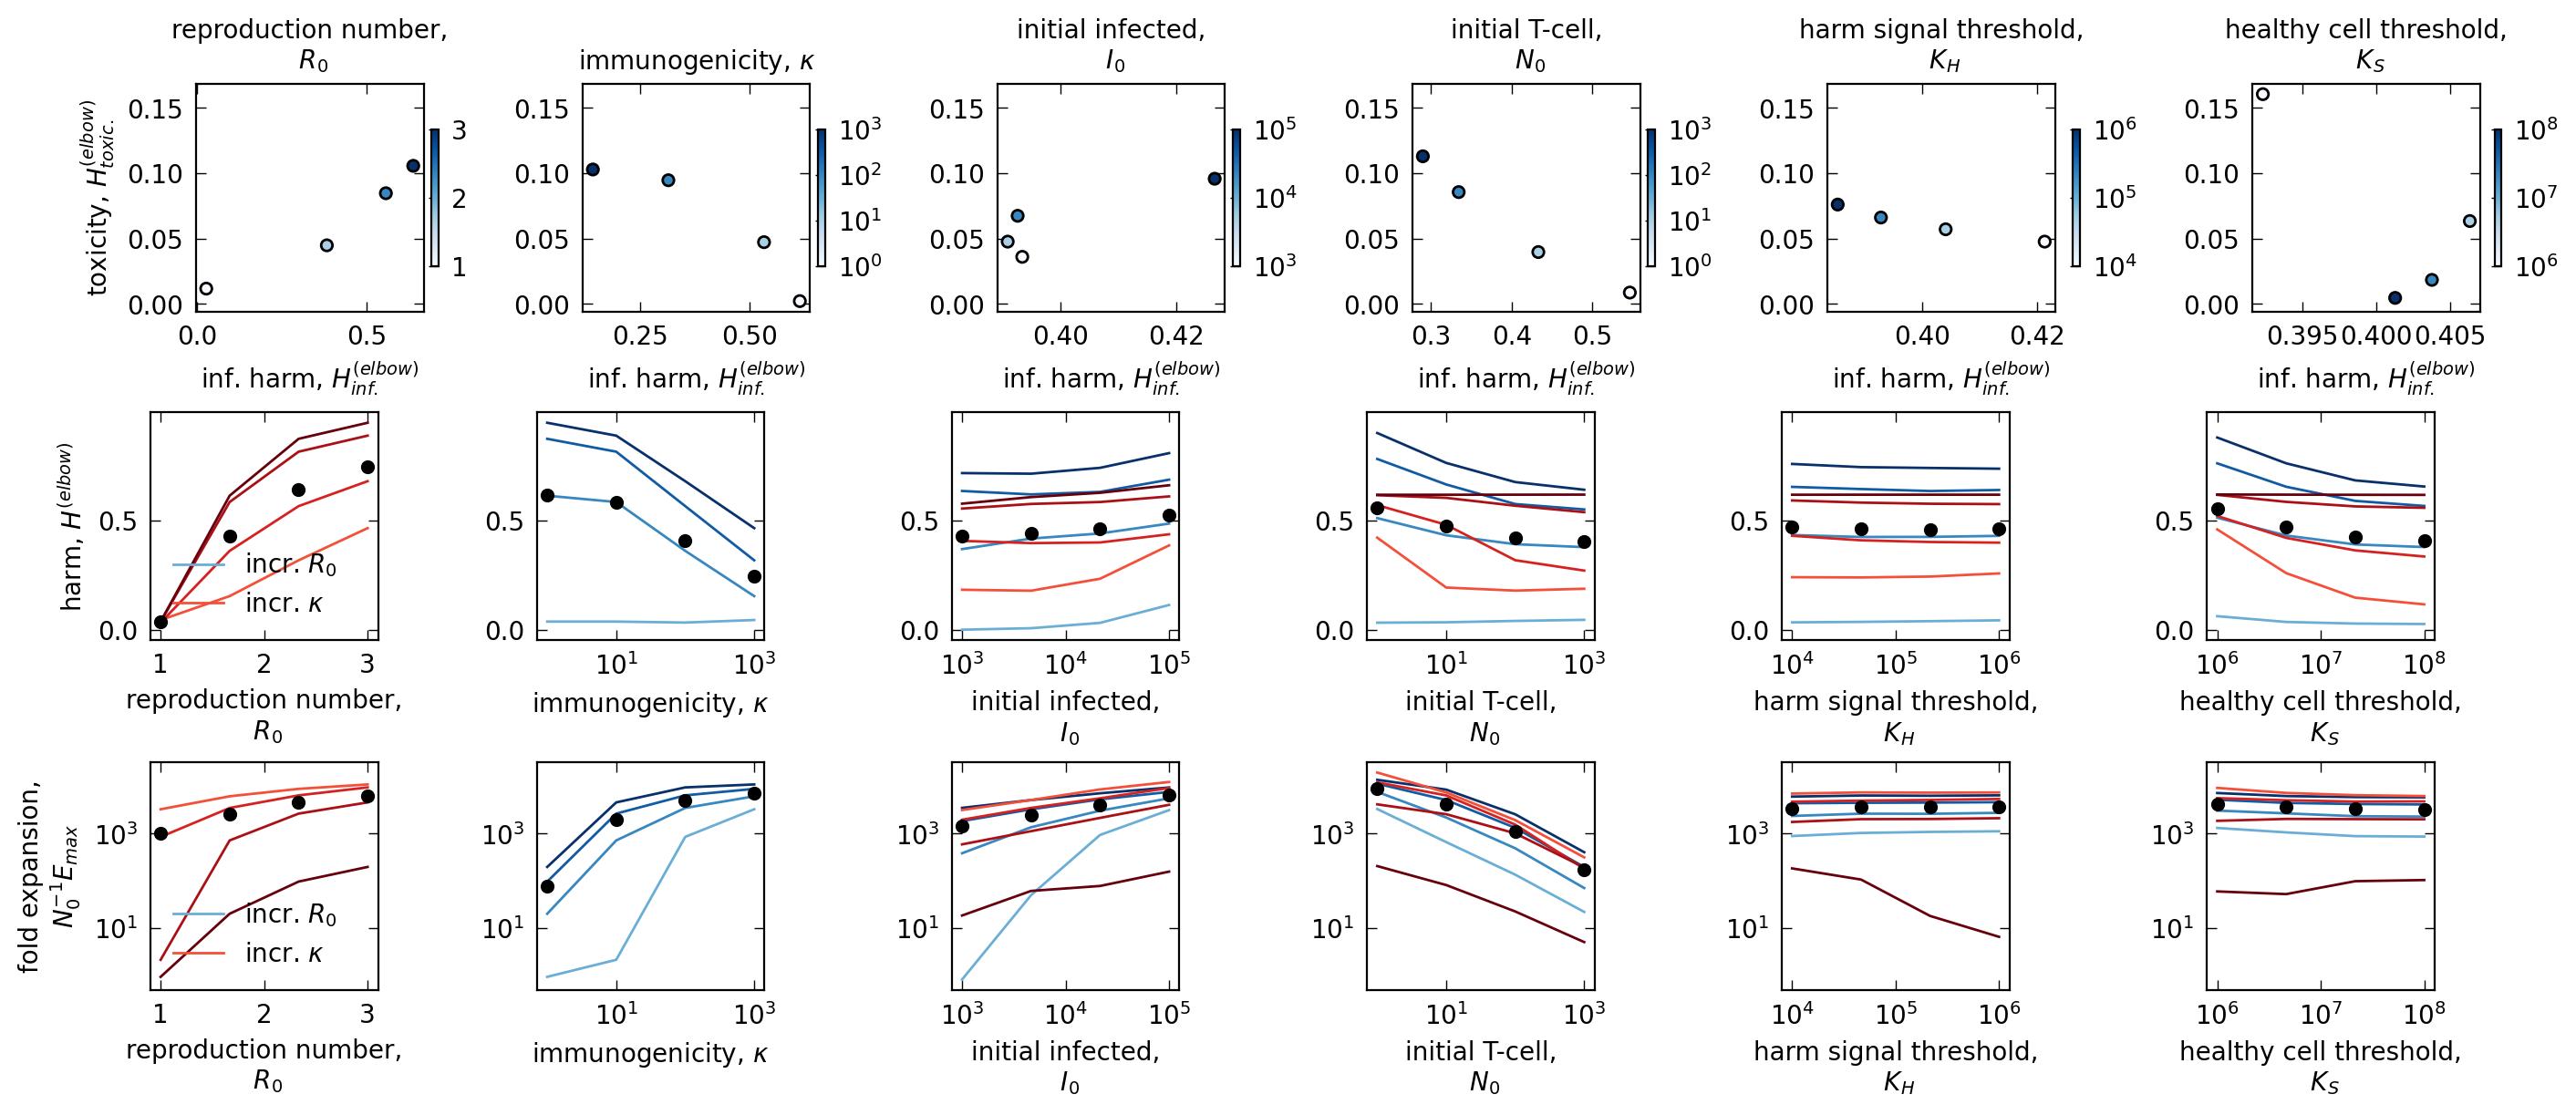

In [50]:
# Visualize optimal Harm and regulation
parameters = ['R_0', 'kappa', 'I_0', 'N_0', 'K_H', 'K_S']
parameter_labels = ['reproduction number,\n $R_0$', r'immunogenicity, $\kappa$', 'initial infected,\n $I_0$', 'initial T-cell,\n $N_0$', 'harm signal threshold,\n $K_H$', 'healthy cell threshold,\n $K_S$']

fig, axs = plt.subplots(3, len(parameters), 
                          figsize=(2*len(parameters) + 2, 6), sharex=False, sharey='row', constrained_layout=True)


for k, var in enumerate(parameters):

    data = parameter_sens_df.groupby([var],as_index = False).mean()
    R_0_data = parameter_sens_df.groupby([var] + (['R_0'] if var != 'R_0' else []),as_index = False).mean()
    K_I_data = parameter_sens_df.groupby([var] + (['kappa'] if var != 'kappa' else []),as_index = False).mean()

    z = data[var].values
    range = np.amax(np.abs(z))
    im = axs[0,k].scatter(data.peff_infection, data.peff_toxicity,
                 marker ='o', s = 20, c = z, 
                 cmap='Blues', edgecolors = 'black',# alpha = 0.8, 
                 norm = mpl.colors.LogNorm(vmax = range) if var not in ['d_I','R_0'] else mpl.colors.Normalize())

    axs[1,k].scatter(data[var], data.peff_total_harm,
                 marker ='o', s = 20, color = 'black', zorder = 3)
    # axs[1,k].plot(max_data[var], max_data.peff_total_harm,
    #              color = 'grey')
    # axs[1,k].plot(min_data[var], min_data.peff_total_harm,
    #              color = 'grey')

    axs[2,k].scatter(data[var], data.max_expE,
                 marker ='o', s = 20, color = 'black', zorder = 3)
    for l,a in enumerate(np.unique(R_0_data.R_0)):
        color = plt.cm.Blues(0.25 + 0.75*a/np.amax(R_0_data.R_0))
        axs[2,k].plot(R_0_data.loc[R_0_data.R_0 == a][var], R_0_data.loc[R_0_data.R_0 == a].max_expE,
                     color = color, label = 'incr. $R_0$' if l == 0 else '')

        axs[1,k].plot(R_0_data.loc[R_0_data.R_0 == a][var], R_0_data.loc[R_0_data.R_0 == a].peff_total_harm,
                     color = color, label = 'incr. $R_0$' if l == 0 else '')

    for l,a in enumerate(np.unique(K_I_data.K_I)):
        color = plt.cm.Reds(np.log(a)/np.log(np.amax(K_I_data.K_I)))
        axs[2,k].plot(K_I_data.loc[K_I_data.K_I == a][var], K_I_data.loc[K_I_data.K_I == a].max_expE,
                     color = color, label = 'incr. $\kappa$' if l == 0 else '')

        axs[1,k].plot(K_I_data.loc[K_I_data.K_I == a][var], K_I_data.loc[K_I_data.K_I == a].peff_total_harm,
                     color = color, label = 'incr. $\kappa$' if l == 0 else '')
    # axs[2,k].plot(min_data[var], min_data.max_expE,
    #              color = 'grey')

    z_label = parameter_labels[k]
    axs[0,k].set_title(z_label, fontsize = 10.0)
    axs[0,k].set_xlabel(r'inf. harm, $H_{inf.}^{(elbow)}$', fontsize = 10)
    if k == 0:
        axs[0,k].set_ylabel(r'toxicity, $H_{toxic.}^{(elbow)}$', fontsize = 10)
    cb = fig.colorbar(im, ax=axs[0,k], location='right', shrink = 0.6, pad = 0.025)
    cb.ax.tick_params(labelsize=10)
    #axs[0,k].locator_params(axis='y', nbins=4)

    if var not in ['d_I','R_0']:
        axs[1,k].semilogx()
    axs[1,k].set_xlabel(z_label, fontsize = 10)
    if k == 0:
        axs[1,k].set_ylabel(r'harm, $H^{(elbow)}$', fontsize = 10)
    axs[1,k].locator_params(axis='y', nbins=4)
    axs[1,0].legend()

    if var not in ['d_I','R_0']:
        axs[2,k].semilogx()
    axs[2,k].semilogy()
    axs[2,k].set_xlabel(z_label, fontsize = 10)
    if k == 0:
        axs[2,k].set_ylabel('fold expansion,\n'+ r'$N_0^{-1}E_{max}$', fontsize = 10)
    axs[2,0].legend()


for ax in axs.flat:
    ax.set_box_aspect(1)
    ax.minorticks_off()
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

#fig.subplots_adjust(wspace=0.25, hspace=0.3)

plt.savefig('_figs/figSI_'+comment+'-reg-elbow-parameter-sensitivity'+'.pdf', format="pdf", transparent=True, dpi=300)

### (e) Application to a model of a fast-growing tumor

In [51]:
# Define variables and dataframes
cancer_plots = [vir_vars[1], vir_vars[0], vir_vars[4]]
cancer_plot_labels = [r"immunogenicity, $\kappa$", r"T-cell dosage, $N_0$ [$S_\text{max}$]"]

There a sort of goldilocks effect where the designs for cancer Harm are suboptimal for acute response but the worst designs those of intermediate Immunogenicity.

#### Compute tumour Harm of Ag. dominant pareto Harm

In [52]:
from optimize_nets import *
num_pnts = 13
runs = 1
sample = np.array(np.meshgrid(d_S*np.array([1.0]), # vary d_I
                                   S_max*np.logspace(-3.0, 0.0, num_pnts), # vary K_I
                                   b_C*np.array([1.0]), # vary b_I
                                   K_H*np.array([1.0]), # vary K_H
                                   N_0*np.logspace(-2.0, 3, num_pnts), # vary N_0
                                   S_max*np.array([0.1]), # vary I_0
                                   np.array([S_max]), # vary K_S
                                        np.array([d_IE]), # vary d_IE
                                        np.array([d_H]), # vary d_H
                                        np.array([max_Na]), # vary max_Na
                                        np.array([max_expand]) # vary max_expand
                                           )).T.reshape(-1,11)

d="/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/raw"

h = 1e-1
arr = np.array([np.arange(0, len(opt_vars)) for l in np.arange(0, ensemble_size)])
ps = np.vstack([np.vstack([modified_ensemble_elbow_reg - h*(arr == j), modified_ensemble_elbow_reg, modified_ensemble_elbow_reg + h*(arr == j)]) for j in np.arange(0, len(opt_vars))])
cancer_psis = np.array([ps[:,0], ps[:,1], ps[:,2], ps[:,3], # Na
          ps[:,0], ps[:,1], ps[:,2], ps[:,4], # NE
          -0*ps[:,0], -0*ps[:,1], -0*ps[:,2], -L0_max**3 -0*ps[:,4], # EM
          -ps[:,0], -ps[:,1], -ps[:,2], ps[:,5]]).T  # Edie

# run simulations for extreme scenarios
# run(batch = [-1], outdir=d, inf_sample = sample, 
#     comment="ag_dosage_sim"+'-'+model, runs = runs, infection_model = 'cancer', 
#     default_reg = cancer_psis,
#     num_cpu = num_cpu)

In [62]:
d_file = d + '/sim_batch_-1-1-cancer-ag_dosage_sim'+'-'+model+'.pkl'
with open(d_file, 'rb') as f:
    data_dict = pickle.load(f)

parameters = data_dict["parameters"]
sim_summary = data_dict["summary_stats"]
var_names = np.concatenate((param_names_for_df, stat_names_for_df))
cancer_acute_comp_df = pd.DataFrame(np.hstack((parameters, sim_summary)), columns = [i for i in var_names]) #.groupby(cancer_plots + reg, as_index=False, sort = False).mean().reset_index()

# compute infection harm without T cell response
no_eff_data = lin_stoch_sim(N_0 = 0, I_0 = sample[0][5], K_I = K_I, d_I = sample[0][0], b_I = sample[0][2],
                               infection_model = "cancer")
no_eff_stats = no_eff_data["summary_stats"]

cancer_acute_comp_df.loc[:,opt_vars[0:3]] = cancer_acute_comp_df[['psi_NE_I', 'psi_NE_HI', 'psi_NE_HE']].values
cancer_acute_comp_df.loc[:, opt_vars[3:]] = 1/(1 + np.exp(-cancer_acute_comp_df[reg_bl].values))
cancer_acute_comp_df.loc[:,"harm_pI_noprotection"] = no_eff_stats[3]/S_max
cancer_acute_comp_df.loc[:,"kappa"] = S_max/cancer_acute_comp_df['K_I'].to_numpy()
cancer_acute_comp_df.loc[:,"peff_infection"] = cancer_acute_comp_df['harm_pI'].to_numpy()/S_max
cancer_acute_comp_df.loc[:,"peff_toxicity"] = cancer_acute_comp_df['harm_pS'].to_numpy()/S_max
cancer_acute_comp_df.loc[:,"peff_total_harm"] = (cancer_acute_comp_df['peff_infection'] + cancer_acute_comp_df['peff_toxicity'])
cancer_acute_comp_df.loc[:,"peff_scaled_total_harm"] = cancer_acute_comp_df['peff_total_harm']/cancer_acute_comp_df['harm_pI_noprotection']
cancer_acute_comp_df.loc[:,"ensemble_index"] = np.array(cancer_acute_comp_df.index.tolist()) % ensemble_size
cancer_acute_comp_df.loc[:,"h_index"] = (np.array(cancer_acute_comp_df.index.tolist()) // ensemble_size) % 3
cancer_acute_comp_df.loc[:,"opt_var_index"] = (np.array(cancer_acute_comp_df.index.tolist()) // (ensemble_size*3)) % len(opt_vars)

In [63]:
# Find optimal dosage for each Immunogenicity
data = cancer_acute_comp_df.loc[cancer_acute_comp_df.h_index == 1].groupby(cancer_plots + ["ensemble_index"], as_index = False, sort = False).mean()
opt_N0 = data.loc[data.groupby(['K_I',"ensemble_index"])['peff_total_harm'].idxmin()].copy()
data.loc[:,'N_0_match'] = np.abs(data['N_0'].values - np.amax(data['N_0'].values))

# Compute effect of perturbation in the design
gradients = []
for k, (_, input) in enumerate(cancer_acute_comp_df.groupby(cancer_plots + ['ensemble_index'], sort = False)):
    input.loc[:,'dummy'] = np.sum(np.abs(input[opt_vars[0:3] + reg_bl].values - np.mean(input[opt_vars[0:3] + reg_bl].values, axis = 0)), axis = 1)
    out = np.zeros(len(opt_vars))
    for i, var in enumerate(opt_vars):
        f = input.copy().loc[input.groupby(var)['dummy'].idxmin()].peff_total_harm.values
        delta = input.copy().loc[input.groupby(var)['dummy'].idxmin()][var].values
        grad = np.gradient(f, delta)
        input.loc[:,'d_'+var] = grad[1]
        
    out = input.loc[input.h_index == 1].iloc[0]

    gradients.append(out.values)

gradients_data = pd.DataFrame(np.vstack(gradients), columns = input.columns.tolist()) 
#pd.concat(gradients) # np.vstack(gradients)

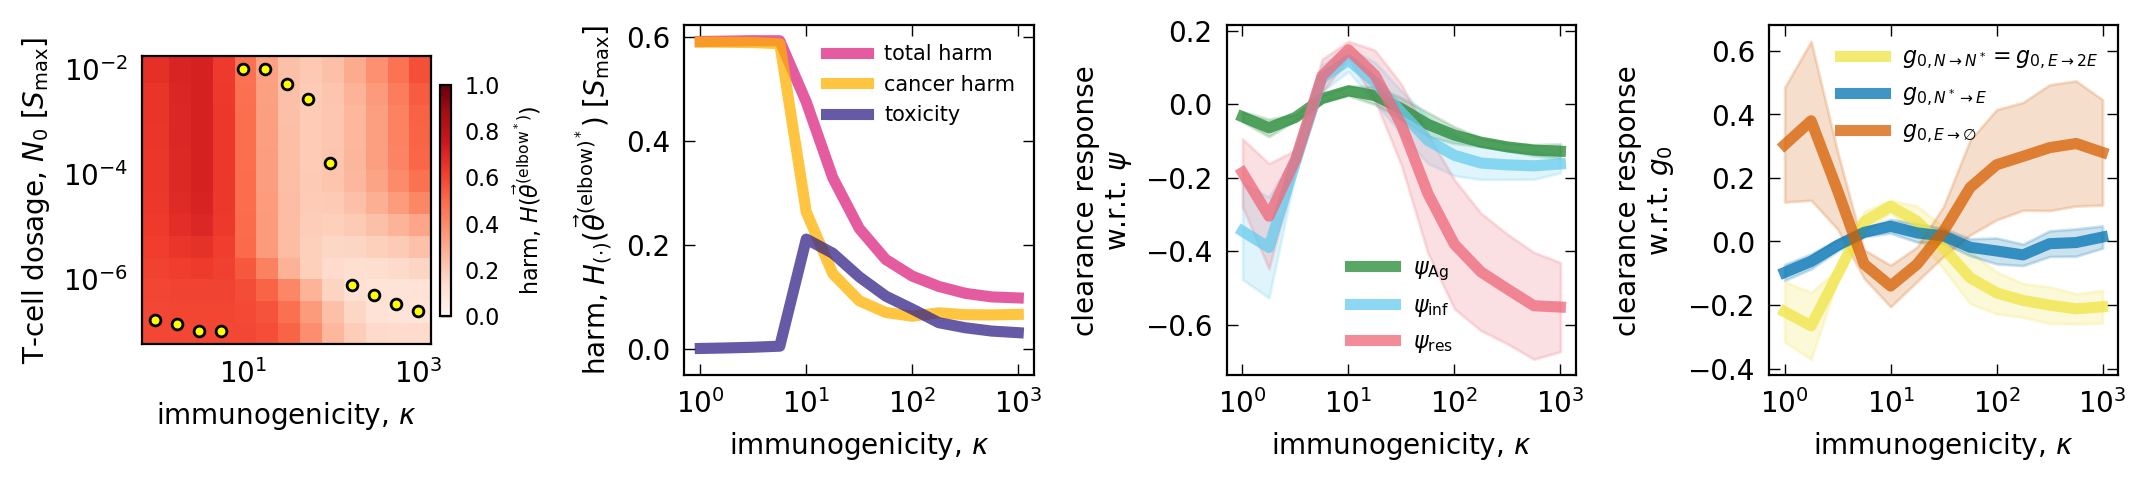

In [64]:
fig, axs = plt.subplots(1, 4, figsize=(12.75, 3), sharex=False, sharey=False) #, layout='constrained')

size = 1250/num_pnts
data = cancer_acute_comp_df.loc[cancer_acute_comp_df.h_index == 1].groupby(cancer_plots, as_index = False, sort = False).mean()
im = axs[0].scatter(data['kappa'].values,
                 data['N_0'].values/S_max,
                 marker = 's', s = size,
                 c = data['peff_total_harm'].values, 
                 cmap='Reds', edgecolors = 'None',# alpha = 0.8, 
                 norm = mpl.colors.Normalize(vmin = 0, vmax = 1.0))

axs[0].semilogy()
axs[0].set_ylabel(cancer_plot_labels[1], fontsize = 10)

use_data = opt_N0.groupby(['kappa'], as_index = False).mean()
min_use_data = opt_N0.groupby(['kappa'], as_index = False).min()
max_use_data = opt_N0.groupby(['kappa'], as_index = False).max()
std_use_data = opt_N0.groupby(['kappa'], as_index = False).std()

axs[0].scatter(use_data['kappa'].values,
         use_data['N_0'].values/S_max,
         color = 'yellow', s = 15, marker = 'o', edgecolors = 'black', zorder = 7)

for j,perf in enumerate(['peff_total_harm'] + perf_vars[1:3]):
    axs[1].plot(use_data['kappa'].values,
             use_data[perf].values, #/(1 if j == 0 else opt_N0['harm_pI_noprotection'].values),
             color = perf_var_colors[j],
                label = ["total harm", "cancer harm", perf_labels[2]][j],
               **kwargs)
    # axs[1].fill_between(use_data['kappa'],
    #                     use_data[perf].values - std_use_data[perf].values,
    #                     use_data[perf].values + std_use_data[perf].values,
    #         # min_use_data[perf].values, 
    #         # max_use_data[perf].values, 
    #         alpha=0.2,
    #         color = perf_var_colors[j])

axs[1].set_ylabel(r"harm, $H_{(\cdot)}(\vec\theta^{(\text{elbow})^*})$ [$S_\text{max}$]", fontsize = 10)
axs[1].set_ylim(-0.05, None)

axs[1].locator_params(axis='y', nbins=4)
axs[1].legend(loc = 'upper right',fontsize = 7.5)

for i, var in enumerate(opt_vars):
    input_data = gradients_data.loc[(gradients_data.N_0 == heapq.nlargest(13,np.unique(gradients_data.N_0.values))[0])]
    # input_data = gradients_data.groupby([cancer_plots[0], 'ensemble_index'], as_index = False).mean()
    use_data = input_data.groupby(cancer_plots[0], as_index = False).mean() 
    #input_data.groupby(cancer_plots[0],as_index = False).mean() # loc[(gradients_data.N_0 == heapq.nlargest(13,np.unique(gradients_data.N_0.values))[1])]
    min_use_data = input_data.groupby(cancer_plots[0], as_index = False).min()
    max_use_data = input_data.groupby(cancer_plots[0], as_index = False).max()
    std_use_data = input_data.groupby(cancer_plots[0], as_index = False).std()
    if i <=2:
        axs[2].plot(S_max/use_data['K_I'].values,
                    -use_data['d_'+var],
                    color = cmap_colors[i], 
                    #linestyle = linestyles[i],
                    label = opt_vars_labels[i], #+((r'$~> 0$' if modified_avg_pareto_reg[i] > 0 else r'$~< 0$') if i < 3 else ''),
                    **kwargs)
        axs[2].fill_between(S_max/use_data['K_I'].values, 
                            -(use_data['d_'+var].values - std_use_data['d_'+var].values),
                            -(use_data['d_'+var].values + std_use_data['d_'+var].values),
                    # -min_use_data['d_'+var], 
                    # -max_use_data['d_'+var], 
                    alpha=0.2,
                    color = cmap_colors[i])
        
    else:
        axs[3].plot(S_max/use_data['K_I'].values,
                    -use_data['d_'+var],
                    color = cmap_colors[i], 
                    #linestyle = linestyles[i],
                    label = opt_vars_labels[i], #+((r'$~> 0$' if modified_avg_pareto_reg[i] > 0 else r'$~< 0$') if i < 3 else ''),
                    **kwargs)
        axs[3].fill_between(S_max/use_data['K_I'].values,
                            -(use_data['d_'+var].values - std_use_data['d_'+var].values),
                            -(use_data['d_'+var].values + std_use_data['d_'+var].values),
            # -min_use_data['d_'+var], 
            # -max_use_data['d_'+var], 
            alpha=0.2,
            color = cmap_colors[i])

# axs[2].set_ylabel(r"$-\partial_{\theta_i}$"+r" $H(\vec\theta^{*})$" +" [$S_{max}$]", fontsize = 10)
axs[2].set_ylabel('clearance response\n'+r'w.r.t. $\psi$', fontsize = 10)
axs[2].legend(ncol = 1, fontsize=8)
# axs[3].set_ylabel(r"$-\partial_{\theta_i}$"+r" $H(\vec\theta^{*})$" +" [$S_{max}$]", fontsize = 10)
axs[3].set_ylabel('clearance response\n'+r'w.r.t. $g_0$', fontsize = 10)
axs[3].legend(ncol = 1, fontsize=8)

for ax in axs.flat:
    ax.semilogx()
    ax.set_box_aspect(1)
    ax.minorticks_off()
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.set_xlabel(cancer_plot_labels[0], fontsize = 10)

z_label = r"harm, $H(\vec\theta^{(\text{elbow}^*)})$"
cb = fig.colorbar(im, ax=axs[0], location='right', shrink = 0.5, pad = 0.025)
cb.set_label(z_label, fontsize = 8)
cb.ax.tick_params(labelsize=8)

fig.subplots_adjust(wspace=.55, hspace=0.0)

plt.savefig('_figs/fig6_'+comment+'-reg-_compare_elbow_w_cancer'+'.pdf', format="pdf", transparent=True, dpi=300)

##### Compute tumour Harm of Ag. dominant pareto Harm with $K_S = 10\times K_I$

In [56]:
# run simulations with K_S ~ K_I
from optimize_nets import *
num_pnts = 13
runs = 1
K_S_sample = sample
K_S_sample[:,-1] = 10*K_S_sample[:,1]

# run(batch = [-1], outdir=d, inf_sample = K_S_sample, 
#     comment="ag_dosage_scale_K_S_sim"+'-'+model, runs = runs, infection_model = 'cancer', 
#     default_reg = cancer_psis,
#     num_cpu = num_cpu)

In [65]:
d_file = d + '/sim_batch_-1-1-cancer-ag_dosage_scale_K_S_sim'+'-'+model+'.pkl'
with open(d_file, 'rb') as f:
    data_dict = pickle.load(f)

parameters = data_dict["parameters"]
sim_summary = data_dict["summary_stats"]
var_names = np.concatenate((param_names_for_df, stat_names_for_df))
cancer_acute_comp_df = pd.DataFrame(np.hstack((parameters, sim_summary)), columns = [i for i in var_names]) #.groupby(cancer_plots + reg, as_index=False, sort = False).mean().reset_index()

# compute infection harm without T cell response
no_eff_data = lin_stoch_sim(N_0 = 0, I_0 = K_S_sample[0][5], K_I = K_I, d_I = K_S_sample[0][0], b_I = K_S_sample[0][2],
                               infection_model = "cancer")
no_eff_stats = no_eff_data["summary_stats"]

cancer_acute_comp_df.loc[:,opt_vars[0:3]] = cancer_acute_comp_df[['psi_NE_I', 'psi_NE_HI', 'psi_NE_HE']].values
cancer_acute_comp_df.loc[:, opt_vars[3:]] = 1/(1 + np.exp(-cancer_acute_comp_df[reg_bl].values))
cancer_acute_comp_df.loc[:,"harm_pI_noprotection"] = no_eff_stats[3]/S_max
cancer_acute_comp_df.loc[:,"kappa"] = S_max/cancer_acute_comp_df['K_I'].to_numpy()
cancer_acute_comp_df.loc[:,"peff_infection"] = cancer_acute_comp_df['harm_pI'].to_numpy()/S_max
cancer_acute_comp_df.loc[:,"peff_toxicity"] = cancer_acute_comp_df['harm_pS'].to_numpy()/S_max
cancer_acute_comp_df.loc[:,"peff_total_harm"] = (cancer_acute_comp_df['peff_infection'] + cancer_acute_comp_df['peff_toxicity'])
cancer_acute_comp_df.loc[:,"peff_scaled_total_harm"] = cancer_acute_comp_df['peff_total_harm']/cancer_acute_comp_df['harm_pI_noprotection']
cancer_acute_comp_df.loc[:,"ensemble_index"] = np.array(cancer_acute_comp_df.index.tolist()) % ensemble_size
cancer_acute_comp_df.loc[:,"h_index"] = (np.array(cancer_acute_comp_df.index.tolist()) // ensemble_size) % 3
cancer_acute_comp_df.loc[:,"opt_var_index"] = (np.array(cancer_acute_comp_df.index.tolist()) // (ensemble_size*3)) % len(opt_vars)

In [66]:
# Find optimal dosage for each Immunogenicity
data = cancer_acute_comp_df.loc[cancer_acute_comp_df.h_index == 1].groupby(cancer_plots + ["ensemble_index"], as_index = False, sort = False).mean()
opt_N0 = data.loc[data.groupby(['K_I',"ensemble_index"])['peff_total_harm'].idxmin()].copy()
data.loc[:,'N_0_match'] = np.abs(data['N_0'].values - np.amax(data['N_0'].values))

# Compute effect of perturbation in the design
gradients = []
for k, (_, input) in enumerate(cancer_acute_comp_df.groupby(cancer_plots + ['ensemble_index'], sort = False)):
    input.loc[:,'dummy'] = np.sum(np.abs(input[opt_vars[0:3] + reg_bl].values - np.mean(input[opt_vars[0:3] + reg_bl].values, axis = 0)), axis = 1)
    out = np.zeros(len(opt_vars))
    for i, var in enumerate(opt_vars):
        f = input.copy().loc[input.groupby(var)['dummy'].idxmin()].peff_total_harm.values
        delta = input.copy().loc[input.groupby(var)['dummy'].idxmin()][var].values
        grad = np.gradient(f, delta)
        input.loc[:,'d_'+var] = grad[1]
        
    out = input.loc[input.h_index == 1].iloc[0]

    gradients.append(out.values)

gradients_data = pd.DataFrame(np.vstack(gradients), columns = input.columns.tolist()) 
#pd.concat(gradients) # np.vstack(gradients)

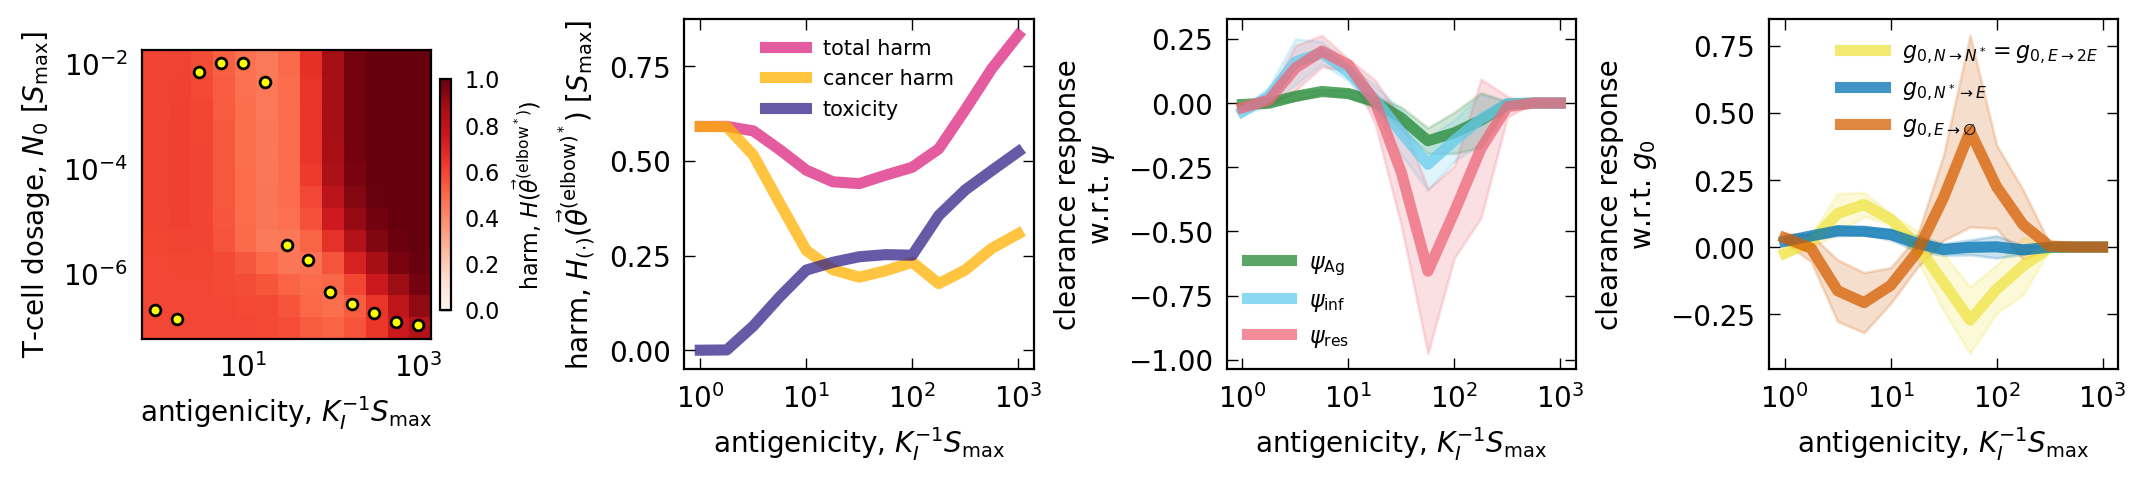

In [67]:
fig, axs = plt.subplots(1, 4, figsize=(12.75, 3), sharex=False, sharey=False) #, layout='constrained')

size = 1250/num_pnts
data = cancer_acute_comp_df.loc[cancer_acute_comp_df.h_index == 1].groupby(cancer_plots, as_index = False, sort = False).mean()
im = axs[0].scatter(S_max/data[plots[0]].values,
                 data['N_0'].values/S_max,
                 marker = 's', s = size,
                 c = data['peff_total_harm'].values, 
                 cmap='Reds', edgecolors = 'None',# alpha = 0.8, 
                 norm = mpl.colors.Normalize(vmin = 0, vmax = 1.0))

axs[0].semilogy()
axs[0].set_ylabel(cancer_plot_labels[1], fontsize = 10)

use_data = opt_N0.groupby([plots[0]], as_index = False).mean()
min_use_data = opt_N0.groupby([plots[0]], as_index = False).min()
max_use_data = opt_N0.groupby([plots[0]], as_index = False).max()
std_use_data = opt_N0.groupby([plots[0]], as_index = False).std()

axs[0].scatter(S_max/use_data[plots[0]].values,
         use_data['N_0'].values/S_max,
         color = 'yellow', s = 15, marker = 'o', edgecolors = 'black', zorder = 7)

for j,perf in enumerate(['peff_total_harm'] + perf_vars[1:3]):
    axs[1].plot(S_max/use_data[plots[0]].values,
             use_data[perf].values, #/(1 if j == 0 else opt_N0['harm_pI_noprotection'].values),
             color = perf_var_colors[j],
                label = ["total harm", "cancer harm", perf_labels[2]][j],
               **kwargs)
    # axs[1].fill_between(S_max/use_data[plots[0]],
    #                     use_data[perf].values - std_use_data[perf].values,
    #                     use_data[perf].values + std_use_data[perf].values,
    #         # min_use_data[perf].values, 
    #         # max_use_data[perf].values, 
    #         alpha=0.2,
    #         color = perf_var_colors[j])

axs[1].set_ylabel(r"harm, $H_{(\cdot)}(\vec\theta^{(\text{elbow})^*})$ [$S_\text{max}$]", fontsize = 10)
axs[1].set_ylim(-0.05, None)

axs[1].locator_params(axis='y', nbins=4)
axs[1].legend(fontsize = 7.5)

for i, var in enumerate(opt_vars):
    use_data = gradients_data.loc[(gradients_data.N_0 == np.max(gradients_data.N_0))].groupby(cancer_plots, as_index = False).mean()
    min_use_data = gradients_data.loc[(gradients_data.N_0 == np.amax(gradients_data.N_0))].groupby(cancer_plots, as_index = False).min()
    max_use_data = gradients_data.loc[(gradients_data.N_0 == np.amax(gradients_data.N_0))].groupby(cancer_plots, as_index = False).max()
    std_use_data = gradients_data.loc[(gradients_data.N_0 == np.amax(gradients_data.N_0))].groupby(cancer_plots, as_index = False).std()
    if i <=2:
        axs[2].plot(S_max/use_data['K_I'].values,
                    -use_data['d_'+var],
                    color = cmap_colors[i], 
                    #linestyle = linestyles[i],
                    label = opt_vars_labels[i], #+((r'$~> 0$' if modified_avg_pareto_reg[i] > 0 else r'$~< 0$') if i < 3 else ''),
                    **kwargs)
        axs[2].fill_between(S_max/use_data['K_I'].values, 
                            -(use_data['d_'+var].values - std_use_data['d_'+var].values),
                            -(use_data['d_'+var].values + std_use_data['d_'+var].values),
                    # -min_use_data['d_'+var], 
                    # -max_use_data['d_'+var], 
                    alpha=0.2,
                    color = cmap_colors[i])
        
    else:
        axs[3].plot(S_max/use_data['K_I'].values,
                    -use_data['d_'+var],
                    color = cmap_colors[i], 
                    #linestyle = linestyles[i],
                    label = opt_vars_labels[i], #+((r'$~> 0$' if modified_avg_pareto_reg[i] > 0 else r'$~< 0$') if i < 3 else ''),
                    **kwargs)
        axs[3].fill_between(S_max/use_data['K_I'].values,
                            -(use_data['d_'+var].values - std_use_data['d_'+var].values),
                            -(use_data['d_'+var].values + std_use_data['d_'+var].values),
            # -min_use_data['d_'+var], 
            # -max_use_data['d_'+var], 
            alpha=0.2,
            color = cmap_colors[i])

axs[2].set_ylabel('clearance response\n'+r'w.r.t. $\psi$', fontsize = 10)
axs[2].legend(ncol = 1, fontsize=8)
# axs[3].set_ylabel(r"$-\partial_{\theta_i}$"+r" $H(\vec\theta^{*})$" +" [$S_{max}$]", fontsize = 10)
axs[3].set_ylabel('clearance response\n'+r'w.r.t. $g_0$', fontsize = 10)
axs[3].legend(ncol = 1, fontsize=8)

for ax in axs.flat:
    ax.semilogx()
    ax.set_box_aspect(1)
    ax.minorticks_off()
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.set_xlabel(r'antigenicity, $K_I^{-1}S_\text{max}$', fontsize = 10)

z_label = r"harm, $H(\vec\theta^{(\text{elbow}^*)})$"
cb = fig.colorbar(im, ax=axs[0], location='right', shrink = 0.5, pad = 0.025)
cb.set_label(z_label, fontsize = 8)
cb.ax.tick_params(labelsize=8)

fig.subplots_adjust(wspace=.55, hspace=0.0)

plt.savefig('_figs/figSI_'+comment+'-reg-_compare_elbow_w_cancer_scale_K_S'+'.pdf', format="pdf", transparent=True, dpi=300)

In [60]:
# # run simulations with K_S ~ K_I
# from optimize_nets import *
# num_pnts = 13
# runs = 1
# K_S_sample = sample
# K_S_sample[:,-1] = K_S_sample[:,1]

# # run(batch = [-1], outdir=d, inf_sample = K_S_sample, 
# #     comment="ag_dosage_scale_K_S_sim"+'-'+model, runs = runs, infection_model = 'cancer', 
# #     default_reg = cancer_psis,
# #     num_cpu = num_cpu)

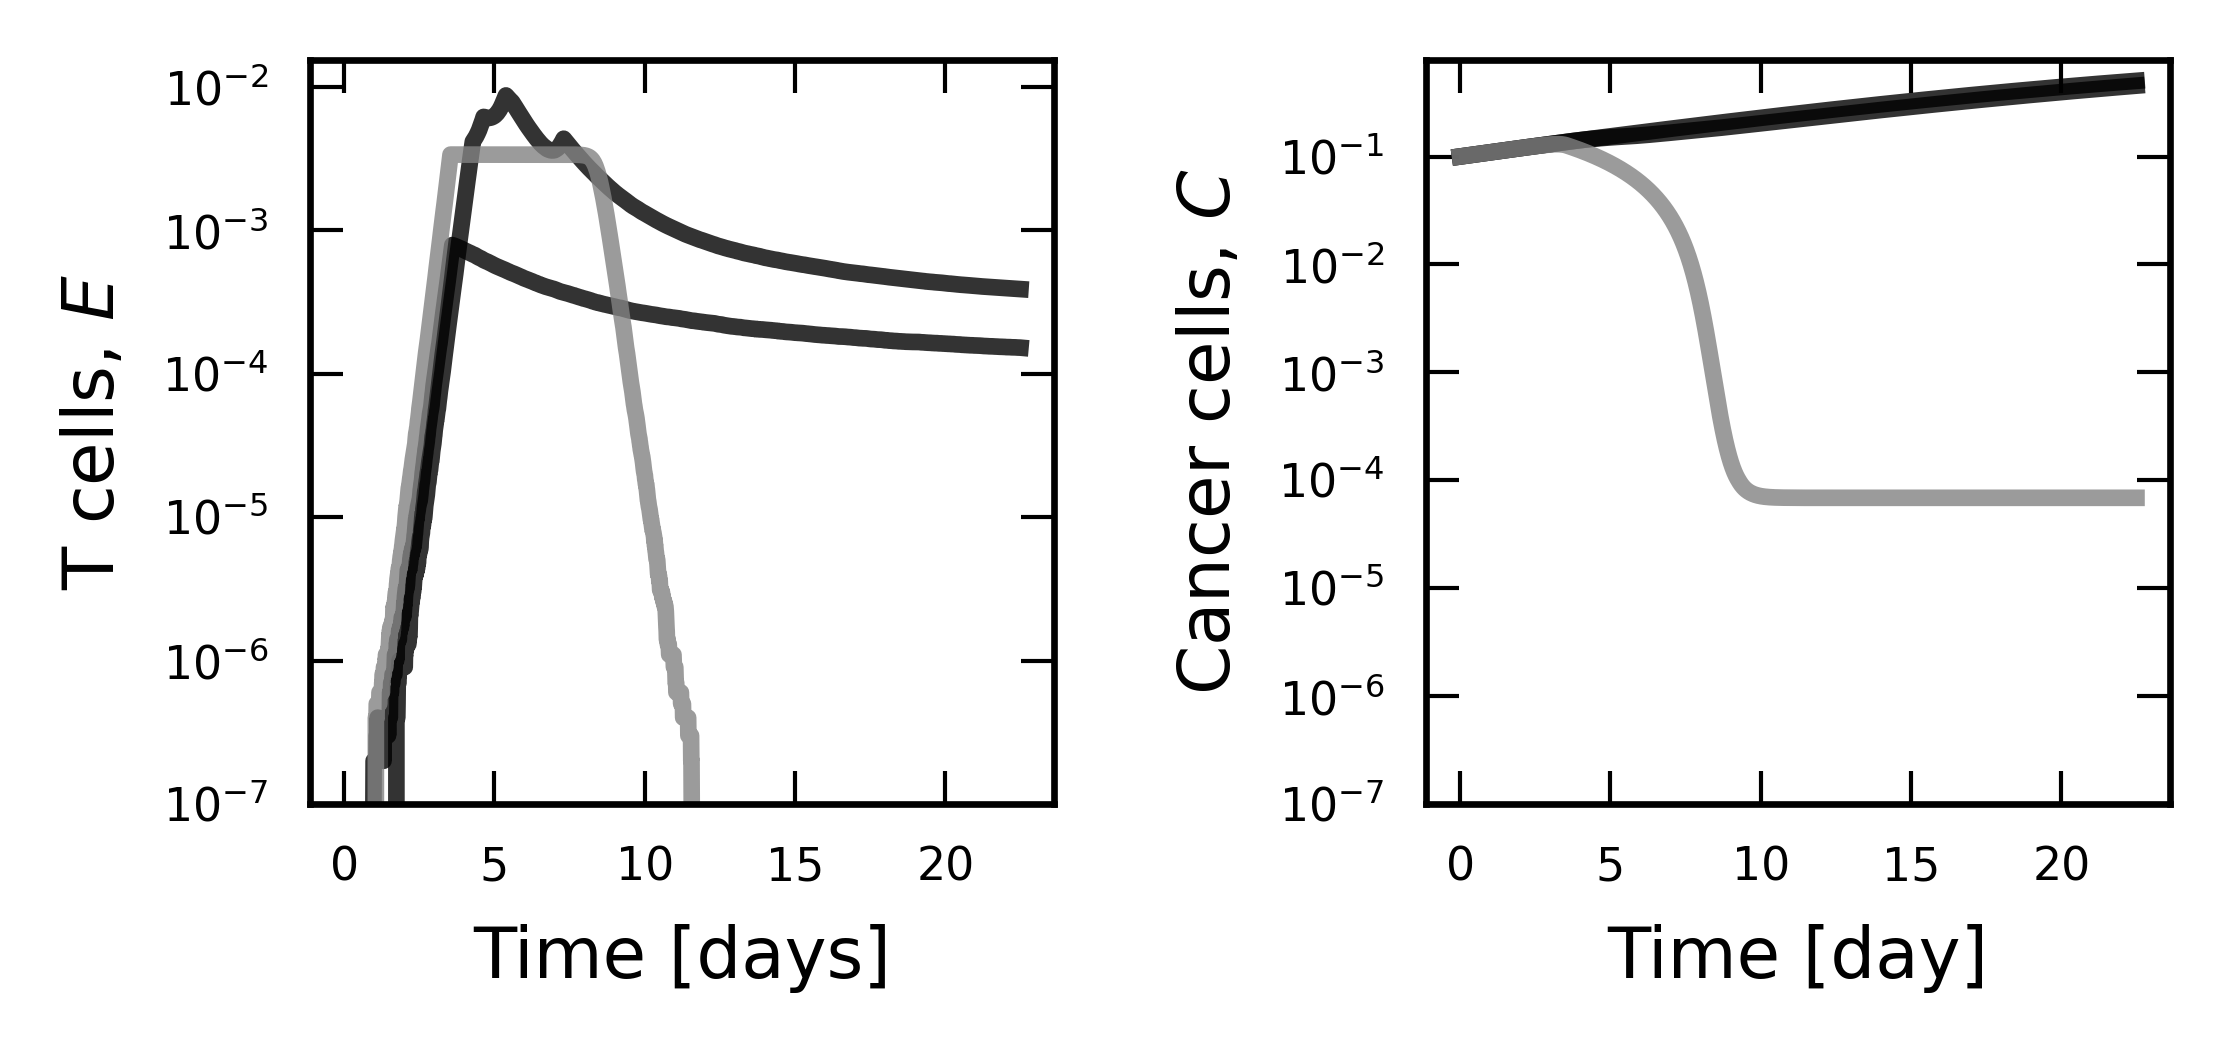

In [61]:
# Plot select infection responses
fig, axs = plt.subplots(1,2, dpi = 300, sharex = False, sharey = False, figsize=(4, 2))

sample = opt_N0[vir_vars].sort_values(by=cancer_plots[0], 
                                      ascending = [False]).values[[0, num_pnts // 2, -1],:]

store_runs = []
# Loop and do 
for k, v in enumerate(sample):

    feedback = p[-1]
    data_dict = lin_stoch_sim(N_0 = v[4],
                              I_0 = v[6],
                              b_I = v[2], 
                              K_I = v[1],
                              d_I = v[0],
                              K_H = v[3],
                              K_S = v[5],
                              NE_regulation = [avg_pareto_reg[0], avg_pareto_reg[1], avg_pareto_reg[2], avg_pareto_reg[4]],
                              activation_regulation = [avg_pareto_reg[0], avg_pareto_reg[1], avg_pareto_reg[2], avg_pareto_reg[3]],
                              contraction_regulation = [-avg_pareto_reg[0], -avg_pareto_reg[1], -avg_pareto_reg[2], avg_pareto_reg[5]],
                              infection_model = 'cancer',
                              reg_model = 'mwc_like',
                              out_data = "full",
                              memory_death = False,
                              duration = 0.75*sim_duration,
                              steps = 1.0*sim_steps)
    
    dyn = data_dict["cell_time_series"]
    ts = data_dict["time"]
    sim_summary = data_dict["summary_stats"]
    
    S, I, N, Na, E, M, HI, I_d_I, I_d_S, HE = dyn[:,0], dyn[:,1], dyn[:,2], dyn[:, 3], dyn[:,4], dyn[:,5], dyn[:,6], dyn[:,7], dyn[:,8], dyn[:,9]

    # Plot cell dynamics
    axs[0].plot(ts, E/S_max, linewidth=2.0, color = plt.cm.Greys(np.log(v[1])/np.log((S_max))), alpha = 0.8)
    axs[1].plot(ts, I/S_max, linewidth=2.0, color = plt.cm.Greys(np.log(v[1])/np.log((S_max))), alpha = 0.8)

for j, ax in enumerate(axs.flat):
    ax.set_box_aspect(1)
    if j == 0:
        ax.set_ylabel(r'T cells, $E$', fontsize = 8.5)
        ax.set_xlabel(r"Time [days]", fontsize = 8.5)
        ax.semilogy()
        #ax.semilogx()
        ax.set_ylim(1/S_max,)
    elif j == 1:
        ax.set_ylabel(r'Cancer cells, $C$', fontsize = 8.5)
        ax.set_xlabel(r"Time [day]", fontsize = 8.5)
        ax.semilogy()
        #ax.semilogx()
        ax.set_ylim(1/S_max,)
    else:
        ax.set_xlabel("Immunogenicity", fontsize = 8.5)
        #ax.locator_params(axis='x', nbins=4)
        ax.set_ylabel("Effector observable", fontsize = 8.5)
        #ax.set_yscale('symlog')
        # ax.semilogy()
        ax.semilogx()

    ax.minorticks_off()
    ax.tick_params(axis='both', which='major', labelsize=5.5)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

fig.subplots_adjust(wspace=.5, hspace=0.15)

plt.savefig('_figs/figSI_'+comment+'-pareto-design-cancer_prot-eff-dynamics'+'.pdf', format="pdf", transparent=True, dpi=300)

Focusing on anti-inflammatory feedback, the optimal designs for acute response perform best with a treatment of high Immunogenicity and low dosage. What does this look like dynamically?

Fixing a pareto optimal network (with acute design) and varying one of the parameters we find that the biggest impact on performance in the biologically plausible range of inflammatory feedback comes from increasing/decreasing the inflammatory signal and/or the Naive to effector transition baseline. This suggests that if cancer can hide it's inflamatory signals it will be harder to clear.